# Étude de cas 1 : Lecture automatique des chèques
## Jalon 1 : Lire le montant par positions (MLP)

**M2 SDIA - Advanced Artificial Intelligence, 2026-2027**
**Auteurs : Hanane Ait Lhaj - Hafssa Miftah Idrissi - Fatimazahra Lasfar**

**Objectif.** Mesurer ce qu'un perceptron multicouche sait faire de la lecture d'un montant, comprendre pourquoi il échoue, et décider quand faire confiance à sa lecture.

**Plan du notebook**

| # | Section |
|---|---|
| 1 | Imports et graine aléatoire |
| 2 | Chargement et exploration des données |
| 3 | Fonctions utilitaires |
| 4 | MLP de référence (architecture) |
| 5 | Entraînement de la référence et métriques |
| 6 | Sur-apprentissage et sur-confiance : causes et remèdes |
| 7 | Correction du modèle : balayage d'hyperparamètres et choix |
| 8 | Augmentation par décalages et vérifications théoriques |
| 9 | Modèle final et évaluation sur le test |
| 10 | Pourquoi le MLP reste limité |
| 11 | Perspective : test d'un réseau convolutif (CNN) |

**Protocole.** Tous les réglages se font sur la **validation**. L'ensemble de test n'est utilisé qu'**une seule fois**, à la section 9, pour le modèle retenu. Graine fixée (`SEED = 0`), versions affichées ci-dessous, toutes les expériences sont écrites dans le journal. Le CNN de la section 11 a sa propre évaluation unique sur le test.

**Pour tout exécuter d'un coup :** menu *Exécution → Redémarrer la session et tout exécuter* (les gardes « test déjà évalué » empêchent de relancer les cellules de test dans la même session ; durée totale : plusieurs dizaines de minutes sur GPU).

In [ ]:
import random, platform, json, time, os
import numpy as np, tensorflow as tf, sklearn
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

# Graine : fixe tous les tirages aléatoires (poids initiaux, dropout, mélange, décalages)
SEED = 0
random.seed(SEED); np.random.seed(SEED); keras.utils.set_random_seed(SEED)

# Constantes de l'étude de cas
L_MAX = 5                 # 5 positions : unités, dizaines, centaines, milliers, dizaines de milliers
N_CLASSES = 11            # chiffres 0-9 + classe 10
EMPTY = 10                # classe 10 = "position vide"
IMG_H, IMG_W = 32, 128
NOMS_POS = ["unités", "dizaines", "centaines", "milliers", "dizaines de milliers"]

print("Python", platform.python_version(), "| TensorFlow", tf.__version__,
      "| scikit-learn", sklearn.__version__, "| NumPy", np.__version__)
print("GPU :", tf.config.list_physical_devices("GPU"))

Python 3.13.15 | TensorFlow 2.20.0 | scikit-learn 1.6.1 | NumPy 2.1.3
GPU : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
if os.path.exists("journal.jsonl"):
    os.remove("journal.jsonl")      # journal propre : une seule exécution complète

## 2. Chargement et exploration des données

Les images viennent de la banque fictive **Banque Atlas**. Les chiffres proviennent du jeu public MNIST ; les montants, la mise en page, les altérations et les défauts du scanner sont **simulés**. Le fichier `uc1_domaineA.npz` (scanner de référence) contient 12 tableaux :

| Clé | Contenu | Taille (train / val / test) |
|---|---|---|
| `X_train`, `X_val`, `X_test` | images en niveaux de gris, 32 × 128 pixels, valeurs 0-255 (encre claire sur fond sombre) | 15 000 / 3 000 / 5 000 |
| `montant_*` | **vérité terrain** : le montant écrit, chaîne de 1 à 5 chiffres (ex. `'17089'`) | une par image |
| `altere_*` | indicateur d'altération : 0 = chèque normal, 1 = chèque altéré (fraude) | une par image |
| `type_alteration_*` | code entier du type d'altération (sa signification n'est pas donnée par l'énoncé : on l'observe sur les images) | une par image |

On divise les pixels par 255 pour travailler dans [0, 1]. Les trois ensembles sont **imposés** et n'ont aucune image de chiffre en commun. Le scanner B (images pâles, floues, 600 images étiquetées) n'est **pas utilisé dans ce jalon**.

In [ ]:
# Téléversement depuis l'ordinateur
if not os.path.exists("uc1_domaineA.npz"):
    from google.colab import files
    files.upload()

d = np.load("uc1_domaineA.npz", allow_pickle=True)
SPLITS = ["train", "val", "test"]

XA = {s: d[f"X_{s}"].astype("float32") / 255.0 for s in SPLITS}      # images dans [0, 1]
A = {}
for s in SPLITS:
    A[f"montant_{s}"] = d[f"montant_{s}"].astype(str)                # montants (chaînes)
    A[f"altere_{s}"] = d[f"altere_{s}"]                              # 0 / 1
    A[f"type_{s}"] = d[f"type_alteration_{s}"]                       # code du type d'altération

for s in SPLITS:
    print(f"{s:5s} images {XA[s].shape} | montants {A[f'montant_{s}'].shape} | "
          f"pixels min/max = {XA[s].min():.2f}/{XA[s].max():.2f}")
print("exemples de montants :", A["montant_val"][:5])

Saving uc1_domaineA.npz to uc1_domaineA.npz
train images (15000, 32, 128) | montants (15000,) | pixels min/max = 0.00/1.00
val   images (3000, 32, 128) | montants (3000,) | pixels min/max = 0.00/1.00
test  images (5000, 32, 128) | montants (5000,) | pixels min/max = 0.00/1.00
exemples de montants : ['17089' '74366' '771' '81' '83687']


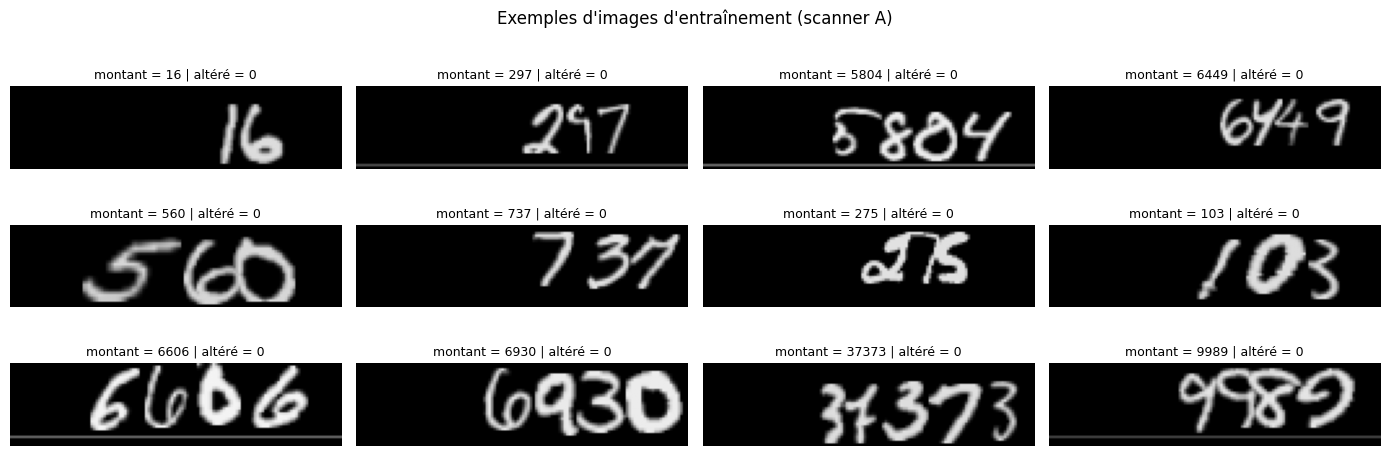

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(14, 5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(XA["train"][i], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"montant = {A['montant_train'][i]} | altéré = {A['altere_train'][i]}", fontsize=9)
    ax.axis("off")
plt.suptitle("Exemples d'images d'entraînement (scanner A)")
plt.tight_layout(); plt.show()

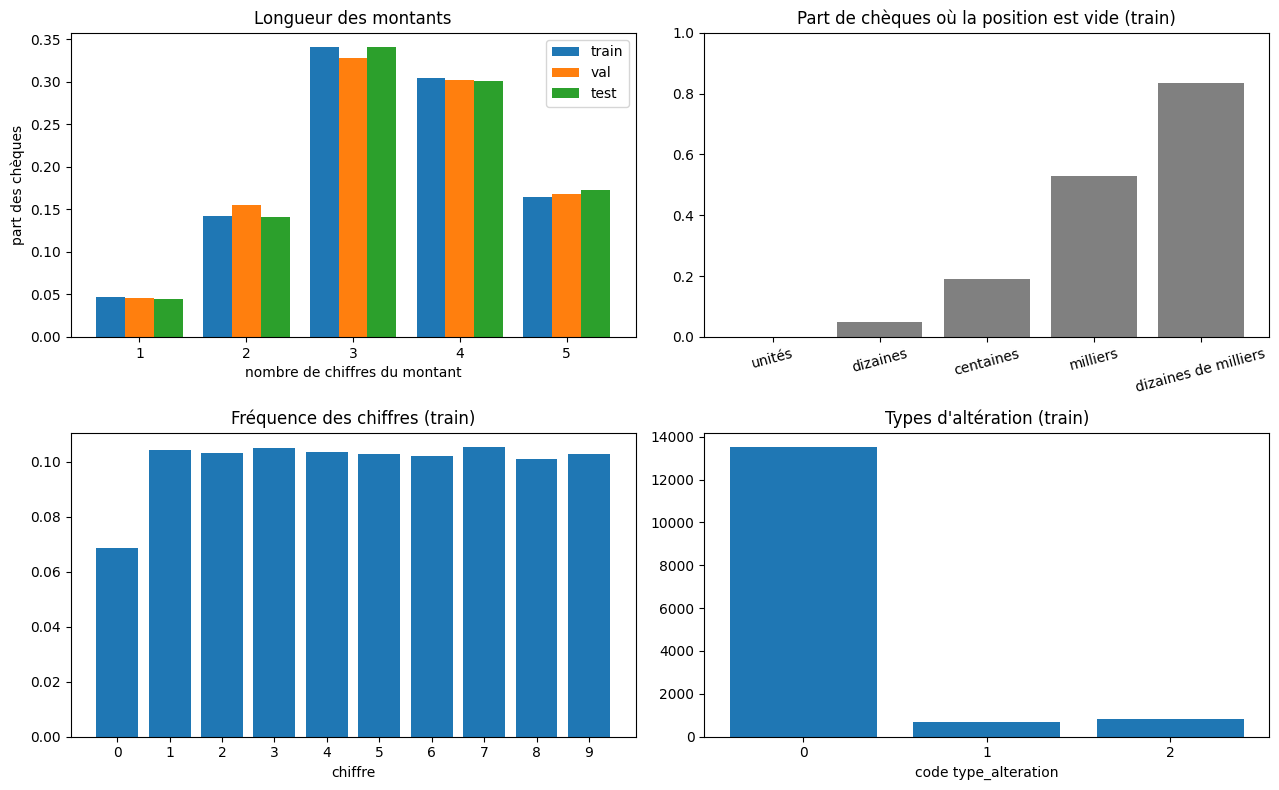

train part de chèques altérés : 0.099
val   part de chèques altérés : 0.095
test  part de chèques altérés : 0.099
types (train) : {0: 13520, 1: 660, 2: 820}


In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(13, 8))

# (a) Longueur des montants, pour chaque ensemble
larg = 0.27
for j, s in enumerate(SPLITS):
    L = np.char.str_len(A[f"montant_{s}"])
    part = np.bincount(L, minlength=L_MAX + 1)[1:] / len(L)
    ax[0, 0].bar(np.arange(1, L_MAX + 1) + (j - 1) * larg, part, larg, label=s)
ax[0, 0].set_xlabel("nombre de chiffres du montant"); ax[0, 0].set_ylabel("part des chèques")
ax[0, 0].set_title("Longueur des montants"); ax[0, 0].legend()

# (b) Part de chèques où chaque position est vide (train)
L = np.char.str_len(A["montant_train"])
vide = [(L <= k).mean() for k in range(L_MAX)]
ax[0, 1].bar(range(L_MAX), vide, color="gray")
ax[0, 1].set_xticks(range(L_MAX)); ax[0, 1].set_xticklabels(NOMS_POS, rotation=15)
ax[0, 1].set_title("Part de chèques où la position est vide (train)"); ax[0, 1].set_ylim(0, 1)

# (c) Fréquence de chaque chiffre dans les montants (train)
chiffres = np.array(list("".join(A["montant_train"])), dtype=int)
ax[1, 0].bar(range(10), np.bincount(chiffres, minlength=10) / len(chiffres))
ax[1, 0].set_xticks(range(10)); ax[1, 0].set_xlabel("chiffre")
ax[1, 0].set_title("Fréquence des chiffres (train)")

# (d) Types d'altération (train)
types, nb = np.unique(A["type_train"], return_counts=True)
ax[1, 1].bar([str(t) for t in types], nb)
ax[1, 1].set_xlabel("code type_alteration"); ax[1, 1].set_title("Types d'altération (train)")
plt.tight_layout(); plt.show()

for s in SPLITS:
    print(f"{s:5s} part de chèques altérés : {A[f'altere_{s}'].mean():.3f}")
print("types (train) :", dict(zip(types.tolist(), nb.tolist())))

*Où se trouve l'encre*

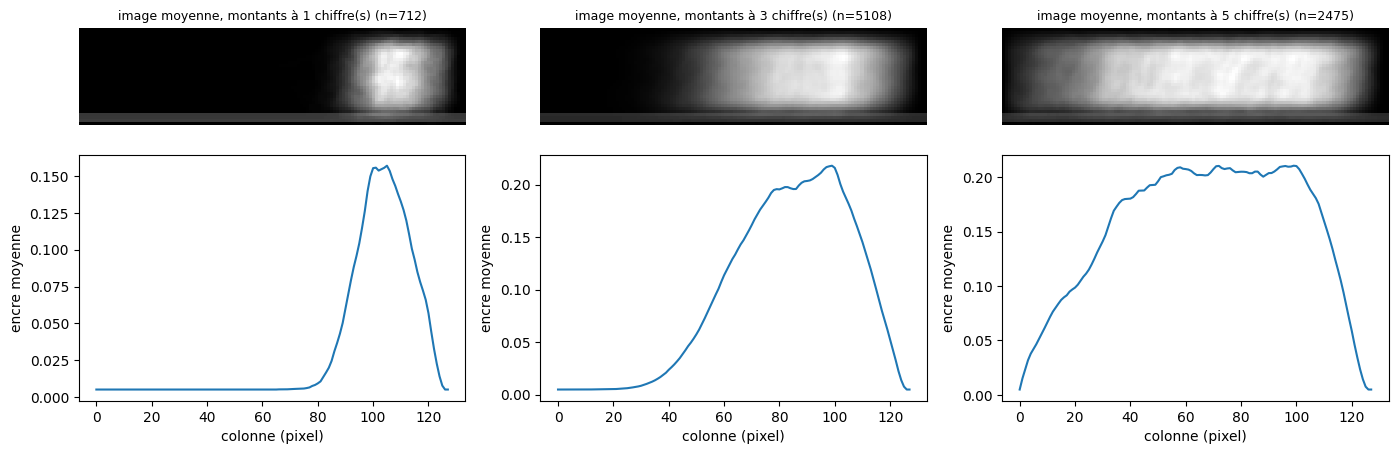

In [ ]:
fig, ax = plt.subplots(2, 3, figsize=(14, 5), gridspec_kw={"height_ratios": [1, 1.2]})
Ltr = np.char.str_len(A["montant_train"])
for j, n in enumerate([1, 3, 5]):
    sel = Ltr == n
    moy = XA["train"][sel].mean(0)
    ax[0, j].imshow(moy, cmap="gray"); ax[0, j].axis("off")
    ax[0, j].set_title(f"image moyenne, montants à {n} chiffre(s) (n={sel.sum()})", fontsize=9)
    ax[1, j].plot(moy.mean(0))
    ax[1, j].set_xlabel("colonne (pixel)"); ax[1, j].set_ylabel("encre moyenne")
plt.tight_layout(); plt.show()

*Exemples* par type d'altération

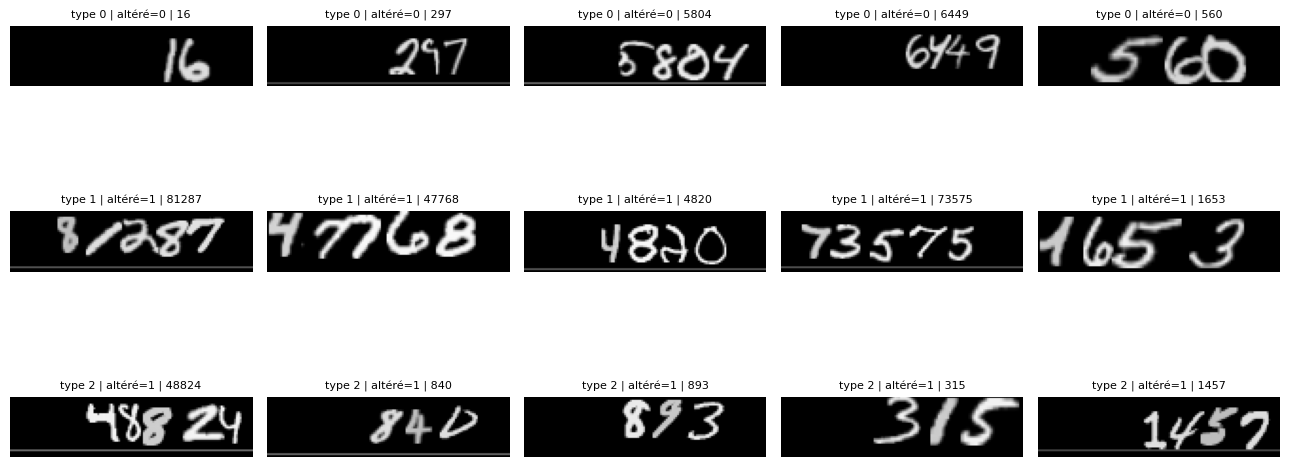

In [ ]:
types = np.unique(A["type_train"])
fig, axes = plt.subplots(len(types), 5, figsize=(13, 2.2 * len(types)))
axes = np.atleast_2d(axes)
for r, t in enumerate(types):
    idx = np.where(A["type_train"] == t)[0][:5]
    for c in range(5):
        axes[r, c].axis("off")
        if c < len(idx):
            axes[r, c].imshow(XA["train"][idx[c]], cmap="gray", vmin=0, vmax=1)
            axes[r, c].set_title(f"type {t} | altéré={A['altere_train'][idx[c]]} | {A['montant_train'][idx[c]]}", fontsize=8)
plt.tight_layout(); plt.show()

### Lecture des données


- **Les montants sont plutôt longs.** Environ 17 % des montants ont 5 chiffres et la position « dizaines de milliers » est vide dans environ 83 % des cas. Les unités ne sont **jamais vides**.
- **Les positions ne sont pas équilibrées.** Une tête qui répondrait toujours « vide » aurait déjà environ 83 % de réussite à la position 4 : un score élevé à cette position ne prouve donc pas que le modèle a appris quelque chose. Il faudra toujours comparer à cette réponse constante.
- **La mise en page varie.** Les images moyennes montrent que le champ est cadré à droite : un même chiffre n'occupe pas les mêmes pixels selon la longueur du montant. C'est la difficulté centrale pour un MLP.
- **Les chiffres sont à peu près équilibrés** (MNIST), donc pas de classe dominante parmi 0-9.
- **Les altérations** : `altere` vaut 0 ou 1, `type_alteration` donne le type. Les altérations ne sont pas utilisées dans ce jalon, mais on pourra mesurer l'exactitude sur chèques normaux et altérés à la fin.

## 3. Fonctions utilitaires

| Fonction | Rôle |
|---|---|
| `vers_positions(montants)` | Transforme `'42'` en 5 cibles `[2, 4, 10, 10, 10]` (unités d'abord, 10 = vide). Ce sont les étiquettes apprises par les 5 têtes. |
| `predire_probs(model, X)` | Fait tourner le modèle et renvoie les probabilités des 5 têtes, tableau `(N, 5, 11)`. |
| `lire_probs(probs, T)` | Probabilités → montants lus (argmax de chaque tête) et **confiance** (produit des 5 probabilités maximales). `T` est une température, utilisée plus tard pour la calibration (`T=1` : inchangé). |
| `lire_positions(model, X)` | Raccourci : `predire_probs` puis `lire_probs`. |
| `structure_valide(probs)` | Indique si les 5 têtes forment un montant possible (chiffres, puis seulement des vides). |
| `exactitude_par_position`, `exactitude_par_longueur` | Exactitude de chaque tête ; exactitude du montant entier selon le nombre de chiffres. |
| `courbe_automatisation`, `taux_automatisation` | Courbe « part traitée vs précision » et taux d'automatisation à 99 % (avec le seuil de confiance correspondant). |
| `table_calibration`, `ece`, `tracer_calibration` | Compare la confiance annoncée à l'exactitude réelle, par groupes de chèques. `ece` résume l'écart en un nombre. |
| `erreur_standard`, `choisir_epoque` | Bruit d'échantillonnage d'une proportion ; règle **automatique** de choix de l'époque (section 7). |
| `journaliser` | Écrit une expérience par ligne dans `journal.jsonl`. |
| `decaler` | Augmentation : décalage horizontal aléatoire de -max_px à +max_px pixels, remplissage noir. |

**Limite connue du décodage (laissée de côté pour l'instant).** Chaque tête décide seule. Si les têtes donnent `[3 | 10 | 2 | 10 | 10]` (unités = 3, dizaines = vide, centaines = 2), c'est un montant **impossible** : il y a un trou. Notre décodage supprime les vides et lit « **23** » (le décodage de l'autre version s'arrêterait au premier vide et lirait « 3 »). Dans les deux cas, on fabrique une lecture qu'aucune tête n'a prédite et le code ne signale rien. On se contente de **mesurer** la fréquence de ces cas (`structure_valide`) ; une correction possible (décodage contraint, ou confiance mise à zéro) sera discutée plus tard.

In [ ]:
def vers_positions(montants):
    """'42' -> [2, 4, 10, 10, 10]  (unités d'abord, 10 = position vide)."""
    Y = np.full((len(montants), L_MAX), EMPTY, dtype=int)
    for i, m in enumerate(montants):
        for k, ch in enumerate(str(m)[::-1]):
            Y[i, k] = int(ch)
    return Y

def predire_probs(model, X):
    """Probabilités des 5 têtes : tableau (N, 5, 11)."""
    P = model.predict(X, batch_size=512, verbose=0)
    return np.stack([P[f"pos{k}"] for k in range(L_MAX)], axis=1)

def lire_probs(probs, T=1.0):
    """Probabilités -> (montants lus, confiance). T : température (T=1, inchangé)."""
    if T != 1.0:
        z = np.log(np.clip(probs, 1e-12, 1.0)) / T
        z = z - z.max(axis=2, keepdims=True)
        probs = np.exp(z)
        probs = probs / probs.sum(axis=2, keepdims=True)
    cls = probs.argmax(2)                                   # classe gagnante de chaque tête
    conf = probs.max(2).prod(1)                             # confiance = produit des 5 maxima
    lus = np.array(["".join(str(c) for c in ligne[::-1] if c != EMPTY) for ligne in cls])
    return lus, conf

def lire_positions(model, X, T=1.0):
    return lire_probs(predire_probs(model, X), T)

def structure_valide(probs):
    """Vrai si les 5 têtes forment un montant possible : chiffres d'abord, puis seulement des vides."""
    ok = []
    for ligne in probs.argmax(2):
        n = int((ligne != EMPTY).sum())
        ok.append(n >= 1 and bool((ligne[:n] != EMPTY).all()))
    return np.array(ok)

In [ ]:
def erreur_standard(p, n):
    """Bruit d'échantillonnage d'une proportion p mesurée sur n chèques."""
    return float(np.sqrt(p * (1 - p) / n))

def exactitude_par_position(probs, Y):
    return [float(np.mean(probs[:, k].argmax(1) == Y[:, k])) for k in range(L_MAX)]

def exactitude_par_longueur(lus, montants):
    lg = np.char.str_len(montants)
    out = {}
    for n in range(1, L_MAX + 1):
        sel = lg == n
        if sel.any():
            out[n] = (float(np.mean(lus[sel] == montants[sel])), int(sel.sum()))
    return out

def courbe_automatisation(correct, conf):
    """Chèques triés par confiance décroissante : (part traitée, précision cumulée)."""
    c = np.asarray(correct, float)[np.argsort(-np.asarray(conf))]
    rang = np.arange(1, len(c) + 1)
    return rang / len(c), np.cumsum(c) / rang

def taux_automatisation(correct, conf, cible=0.99):
    """Plus grande part traitée avec précision cumulée >= cible.
    Renvoie (taux, seuil de confiance, précision à ce point)."""
    o = np.argsort(-np.asarray(conf))
    c = np.asarray(correct, float)[o]
    prec = np.cumsum(c) / np.arange(1, len(c) + 1)
    ok = np.where(prec >= cible)[0]
    if len(ok) == 0:
        return 0.0, None, None
    k = ok.max()
    return (k + 1) / len(c), float(np.asarray(conf)[o][k]), float(prec[k])

def table_calibration(conf, correct, n_bins=10, mode="quantile"):
    """Groupes de chèques : 'quantile' (même effectif) ou 'largeur' (intervalles égaux de confiance)."""
    conf = np.asarray(conf); correct = np.asarray(correct, float)
    bords = np.quantile(conf, np.linspace(0, 1, n_bins + 1)) if mode == "quantile" \
        else np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.searchsorted(bords, conf, side="right") - 1, 0, n_bins - 1)
    lignes = []
    for b in range(n_bins):
        s = idx == b
        if s.any():
            lignes.append(dict(groupe=b, n=int(s.sum()),
                               conf_moy=float(conf[s].mean()), exact=float(correct[s].mean())))
    return lignes

def ece(conf, correct, n_bins=10):
    """Erreur de calibration moyenne : écart |confiance - exactitude| pondéré par l'effectif."""
    lignes = table_calibration(conf, correct, n_bins, "quantile")
    return float(sum(l["n"] / len(conf) * abs(l["conf_moy"] - l["exact"]) for l in lignes))

def tracer_calibration(conf, correct, ax, titre="Calibration", n_bins=10, mode="quantile"):
    lignes = table_calibration(conf, correct, n_bins, mode)
    x = [l["conf_moy"] for l in lignes]; y = [l["exact"] for l in lignes]
    mx = max(max(x), max(y)) * 1.1
    ax.plot([0, mx], [0, mx], "k--", label="calibration parfaite")
    ax.plot(x, y, "o-", label="modèle")
    ax.set_xlabel("confiance moyenne annoncée"); ax.set_ylabel("exactitude réelle")
    ax.set_title(titre + "\n(sous la diagonale : sur-confiant ; au-dessus : sous-confiant)", fontsize=9)
    ax.legend()

def choisir_epoque(exact, loss, n):
    """Règle automatique : parmi les époques dont l'exactitude est dans le bruit du meilleur score,
    prendre celle de perte de validation minimale."""
    ex = np.asarray(exact); lo = np.asarray(loss)
    cand = np.where(ex >= ex.max() - erreur_standard(ex.max(), n))[0]
    return int(cand[np.argmin(lo[cand])])

In [ ]:
def journaliser(jalon, nom, **infos):
    """Ajoute une expérience (une ligne JSON) dans journal.jsonl, échecs compris."""
    with open("journal.jsonl", "a") as f:
        f.write(json.dumps({"jalon": jalon, "nom": nom, "t": time.strftime("%F %T"), **infos},
                           default=float) + "\n")

def decaler(X, max_px, rng):
    """Décalage horizontal aléatoire de -max_px à +max_px pixels, remplissage par du noir."""
    out = np.zeros_like(X)
    for i, d_ in enumerate(rng.integers(-max_px, max_px + 1, len(X))):
        if d_ >= 0:
            out[i, :, d_:] = X[i, :, :X.shape[2] - d_]
        else:
            out[i, :, :d_] = X[i, :, -d_:]
    return out

## 4. MLP de référence

Architecture : l'image est aplatie, passe par deux couches cachées (**256** puis **128** neurones, ReLU), puis **5 têtes** indépendantes `Dense(11, softmax)`, une par position. Aucun dropout dans la référence.

| Couche | Taille de sortie | Calcul des paramètres | Paramètres |
|---|---|---|---|
| Entrée | 32 × 128 | | 0 |
| Aplatir | 4 096 | | 0 |
| Dense 1 (ReLU) | 256 | 4096 × 256 + 256 | 1 048 832 |
| Dense 2 (ReLU) | 128 | 256 × 128 + 128 | 32 896 |
| 5 têtes softmax | 5 × 11 | 5 × (128 × 11 + 11) | 7 095 |
| **Total** | | | **1 088 823** |

- Chaque tête sort 11 probabilités (chiffres 0-9 et « vide »), dont la somme vaut 1.
- La perte est l'**entropie croisée** de chaque tête, **sommée** sur les 5 têtes : c'est pourquoi les pertes affichées sont grandes (environ 7 au mieux).
- La première couche contient environ 96 % des paramètres : un poids distinct pour chaque pixel et chaque neurone.
- Optimiseur Adam, taux d'apprentissage 1e-3.

Model: "mlp_reference"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 32, 128)   │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ aplatir (Flatten)   │ (None, 4096)      │          0 │ image[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │  1,048,832 │ aplatir[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,896 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos0 (Dense)        │ (None, 11)        │      1,419 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos1 (Dense)        │ (None, 11)        │      1,419 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos2 (Dense)        │ (None, 11)        │      1,419 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos3 (Dense)        │ (None, 11)        │      1,419 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos4 (Dense)        │ (None, 11)        │      1,419 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,088,823 (4.15 MB)

 Trainable params: 1,088,823 (4.15 MB)

 Non-trainable params: 0 (0.00 B)

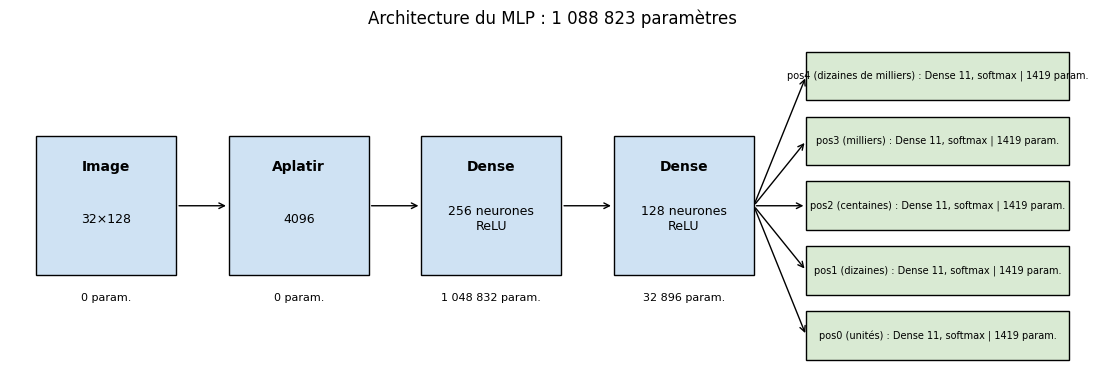

In [ ]:
def build(widths=(256, 128), drop=0.0, lr=1e-3, ls=0.0, nom="mlp"):
    """MLP à 5 têtes. widths : tailles des couches cachées ; drop : dropout ; lr : taux d'apprentissage ;
    ls : label smoothing (0 = cibles dures)."""
    inp = keras.Input(shape=(IMG_H, IMG_W), name="image")
    x = layers.Flatten(name="aplatir")(inp)
    for i, w in enumerate(widths):
        x = layers.Dense(w, activation="relu", name=f"dense_{i+1}")(x)
        if drop:
            x = layers.Dropout(drop, name=f"dropout_{i+1}")(x)
    sorties = {f"pos{k}": layers.Dense(N_CLASSES, activation="softmax", name=f"pos{k}")(x)
               for k in range(L_MAX)}
    m = keras.Model(inp, sorties, name=nom)
    m.compile(optimizer=keras.optimizers.Adam(lr),
              loss={f"pos{k}": keras.losses.CategoricalCrossentropy(label_smoothing=ls)
                    for k in range(L_MAX)})
    return m

# Cibles : (N, 5) entiers, puis one-hot par tête pour Keras
Y_train = vers_positions(A["montant_train"])
Y_val = vers_positions(A["montant_val"])
Y_test = vers_positions(A["montant_test"])

def labels_onehot(Y):
    return {f"pos{k}": keras.utils.to_categorical(Y[:, k], N_CLASSES) for k in range(L_MAX)}

T_train, T_val = labels_onehot(Y_train), labels_onehot(Y_val)

def dessiner_architecture(m):
    blocs = [("Image", f"{IMG_H}×{IMG_W}", 0)]
    tetes = []
    for l in m.layers[1:]:
        if l.name.startswith("pos"):
            tetes.append(l)
        elif isinstance(l, layers.Flatten):
            blocs.append(("Aplatir", f"{IMG_H * IMG_W}", 0))
        elif isinstance(l, layers.Dense):
            blocs.append(("Dense", f"{l.units} neurones\nReLU", l.count_params()))
        elif isinstance(l, layers.Dropout):
            blocs.append(("Dropout", f"taux {l.rate}", 0))
    fig, ax = plt.subplots(figsize=(14, 4.5)); ax.axis("off")
    x = 0.0
    for i, (nom, txt, p) in enumerate(blocs):
        ax.add_patch(plt.Rectangle((x, 1.2), 1.6, 1.6, fc="#cfe2f3", ec="k"))
        ax.text(x + 0.8, 2.45, nom, ha="center", va="center", fontweight="bold")
        ax.text(x + 0.8, 1.85, txt, ha="center", va="center", fontsize=9)
        ax.text(x + 0.8, 0.9, f"{p:,} param.".replace(",", " "), ha="center", fontsize=8)
        if i > 0:
            ax.annotate("", xy=(x, 2.0), xytext=(x - 0.6, 2.0), arrowprops=dict(arrowstyle="->"))
        x += 2.2
    x_t = x
    ys = np.linspace(0.5, 3.5, L_MAX)
    for k, (l, yc) in enumerate(zip(tetes, ys)):
        ax.add_patch(plt.Rectangle((x_t, yc - 0.28), 3.0, 0.56, fc="#d9ead3", ec="k"))
        ax.text(x_t + 1.5, yc, f"pos{k} ({NOMS_POS[k]}) : Dense 11, softmax | {l.count_params()} param.",
                ha="center", va="center", fontsize=7)
        ax.annotate("", xy=(x_t, yc), xytext=(x - 0.6, 2.0), arrowprops=dict(arrowstyle="->"))
    ax.set_xlim(-0.3, x_t + 3.3); ax.set_ylim(0, 4.0)
    ax.set_title(f"Architecture du MLP : {m.count_params():,} paramètres".replace(",", " "))
    plt.show()

ref = build(nom="mlp_reference")
ref.summary()
dessiner_architecture(ref)

## 5. Entraînement du MLP de référence et métriques

On entraîne la référence **30 époques**, sans régularisation, et on garde le modèle de la **dernière époque** (pas de choix d'époque : on veut voir ce qui se passe). Les comparaisons se font entre **entraînement et validation** ; le test n'est pas touché.

À chaque époque, la fonction `entrainer` mesure : la perte (train et validation), l'**exactitude du montant entier** (sur un sous-ensemble fixe de 3 000 images d'entraînement et sur la validation), l'exactitude par position et le taux d'automatisation sur la validation.

Remarque : la perte d'entraînement est une moyenne calculée pendant l'époque (dropout actif, s'il y en a), alors que la perte de validation est mesurée à la fin ; elles ne sont donc pas strictement comparables à petite échelle.

In [ ]:
IDX_TR = np.arange(3000)     # sous-ensemble fixe du train pour mesurer l'exactitude à chaque époque

def entrainer(nom, widths=(256, 128), drop=0.0, lr=1e-3, ls=0.0, epochs=30, aug=0,
              selection="derniere", jalon=1, batch=128, verbose=True):
    """Entraîne un MLP époque par époque.
    selection = 'derniere' : on garde le modèle de la dernière époque ;
    selection = 'regle'    : on revient à l'époque choisie par choisir_epoque (section 7)."""
    keras.utils.set_random_seed(SEED)
    rng = np.random.default_rng(SEED)
    m = build(widths, drop, lr, ls, nom)
    H = {k: [] for k in ["loss_tr", "loss_va", "exact_tr", "exact_va", "auto_va", "acc_pos_va"]}
    poids = []
    for e in range(epochs):
        Xe = decaler(XA["train"], aug, rng) if aug else XA["train"]     # nouveau tirage à chaque époque
        h = m.fit(Xe, T_train, validation_data=(XA["val"], T_val),
                  epochs=1, batch_size=batch, verbose=0)
        H["loss_tr"].append(h.history["loss"][0]); H["loss_va"].append(h.history["val_loss"][0])
        pv = predire_probs(m, XA["val"])
        lus_v, conf_v = lire_probs(pv)
        ok_v = lus_v == A["montant_val"]
        H["exact_va"].append(float(ok_v.mean()))
        H["auto_va"].append(taux_automatisation(ok_v, conf_v)[0])
        H["acc_pos_va"].append(exactitude_par_position(pv, Y_val))
        lus_t, _ = lire_positions(m, XA["train"][IDX_TR])
        H["exact_tr"].append(float(np.mean(lus_t == A["montant_train"][IDX_TR])))
        if selection == "regle":
            poids.append(m.get_weights())
        if verbose and (e + 1) % 5 == 0:
            print(f"  époque {e+1:3d} | perte val {H['loss_va'][-1]:.3f} | "
                  f"exact train {H['exact_tr'][-1]:.3f} | exact val {H['exact_va'][-1]:.3f}")
    if selection == "regle":
        ep = choisir_epoque(H["exact_va"], H["loss_va"], len(A["montant_val"]))
        m.set_weights(poids[ep])
    else:
        ep = epochs - 1
    pv = predire_probs(m, XA["val"]); lus_v, conf_v = lire_probs(pv)
    ok_v = lus_v == A["montant_val"]
    taux, seuil, _ = taux_automatisation(ok_v, conf_v)
    res = dict(widths=list(widths), drop=drop, lr=lr, ls=ls, aug=aug, epochs=epochs,
               epoque_retenue=ep + 1, exact_val=float(ok_v.mean()), auto_val=float(taux),
               seuil_val=seuil, ece_val=ece(conf_v, ok_v), exact_train=H["exact_tr"][ep],
               loss_train=H["loss_tr"][ep], loss_val=H["loss_va"][ep])
    journaliser(jalon, nom, **res)
    print(nom, {k: (round(v, 4) if isinstance(v, float) else v) for k, v in res.items()})
    return m, H, res

In [ ]:
mlp_ref, H_ref, res_ref = entrainer("reference_30ep", epochs=30, selection="derniere")

  époque   5 | perte val 6.959 | exact train 0.121 | exact val 0.059
  époque  10 | perte val 7.788 | exact train 0.204 | exact val 0.072
  époque  15 | perte val 8.749 | exact train 0.300 | exact val 0.074
  époque  20 | perte val 9.872 | exact train 0.354 | exact val 0.074
  époque  25 | perte val 11.215 | exact train 0.381 | exact val 0.073
  époque  30 | perte val 13.955 | exact train 0.354 | exact val 0.068
reference_30ep {'widths': [256, 128], 'drop': 0.0, 'lr': 0.001, 'ls': 0.0, 'aug': 0, 'epochs': 30, 'epoque_retenue': 30, 'exact_val': 0.0677, 'auto_val': 0.0023, 'seuil_val': 0.9996, 'ece_val': 0.3658, 'exact_train': 0.3543, 'loss_train': 1.7163, 'loss_val': 13.955}


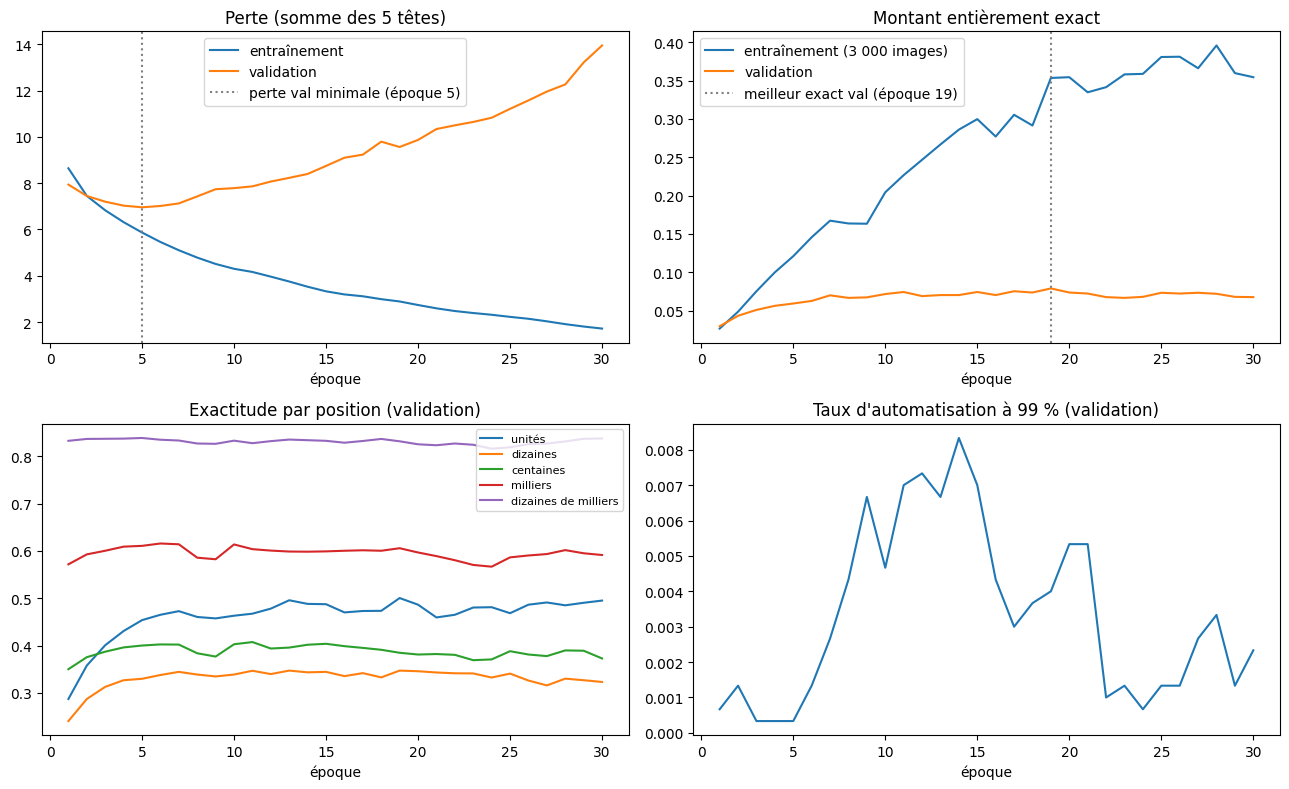

Dernière époque : exact train = 0.354 | exact val = 0.068
Époque de perte val minimale : 5 | époque de meilleur exact val : 19


In [ ]:
ep_ax = np.arange(1, len(H_ref["loss_tr"]) + 1)
e_loss = int(np.argmin(H_ref["loss_va"])) + 1
e_exact = int(np.argmax(H_ref["exact_va"])) + 1

fig, ax = plt.subplots(2, 2, figsize=(13, 8))
ax[0, 0].plot(ep_ax, H_ref["loss_tr"], label="entraînement")
ax[0, 0].plot(ep_ax, H_ref["loss_va"], label="validation")
ax[0, 0].axvline(e_loss, color="gray", ls=":", label=f"perte val minimale (époque {e_loss})")
ax[0, 0].set_title("Perte (somme des 5 têtes)"); ax[0, 0].legend(); ax[0, 0].set_xlabel("époque")

ax[0, 1].plot(ep_ax, H_ref["exact_tr"], label="entraînement (3 000 images)")
ax[0, 1].plot(ep_ax, H_ref["exact_va"], label="validation")
ax[0, 1].axvline(e_exact, color="gray", ls=":", label=f"meilleur exact val (époque {e_exact})")
ax[0, 1].set_title("Montant entièrement exact"); ax[0, 1].legend(); ax[0, 1].set_xlabel("époque")

acc_pos_va = np.array(H_ref["acc_pos_va"])
for k in range(L_MAX):
    ax[1, 0].plot(ep_ax, acc_pos_va[:, k], label=NOMS_POS[k])
ax[1, 0].set_title("Exactitude par position (validation)"); ax[1, 0].legend(fontsize=8)
ax[1, 0].set_xlabel("époque")

ax[1, 1].plot(ep_ax, H_ref["auto_va"])
ax[1, 1].set_title("Taux d'automatisation à 99 % (validation)"); ax[1, 1].set_xlabel("époque")
plt.tight_layout(); plt.show()

print(f"Dernière époque : exact train = {H_ref['exact_tr'][-1]:.3f} | exact val = {H_ref['exact_va'][-1]:.3f}")
print(f"Époque de perte val minimale : {e_loss} | époque de meilleur exact val : {e_exact}")

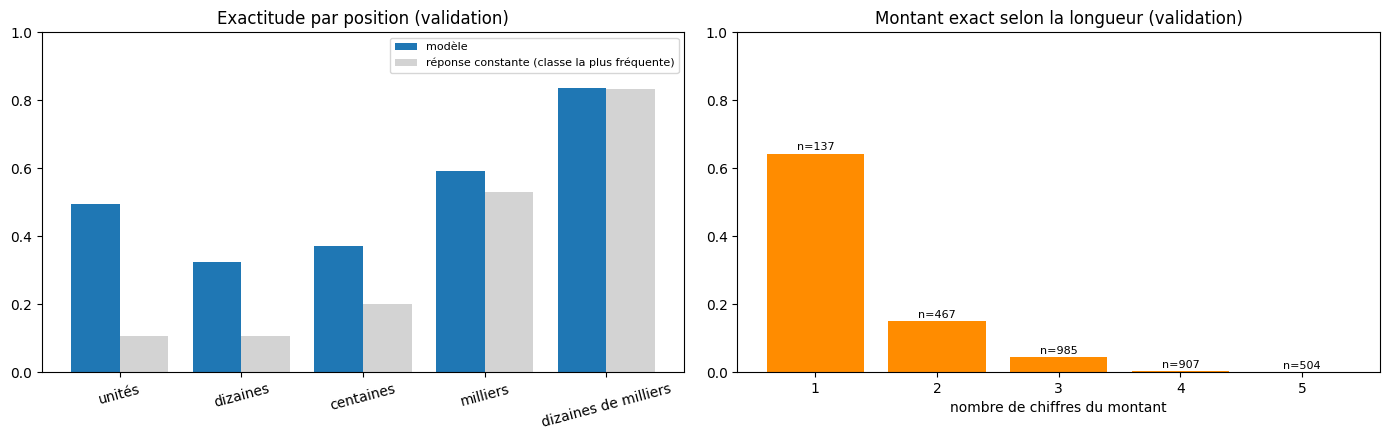

Par position : [0.495, 0.323, 0.373, 0.591, 0.838]
Réponse constante : [0.107, 0.107, 0.201, 0.53, 0.832]
Par longueur : {1: 0.642, 2: 0.15, 3: 0.044, 4: 0.002, 5: 0.0}
Montant exact (validation) : 0.0677


In [ ]:
pv = predire_probs(mlp_ref, XA["val"])
lus, conf = lire_probs(pv)
correct = lus == A["montant_val"]

acc_pos = exactitude_par_position(pv, Y_val)
base_pos = [float(np.bincount(Y_val[:, k], minlength=N_CLASSES).max() / len(Y_val)) for k in range(L_MAX)]
acc_len = exactitude_par_longueur(lus, A["montant_val"])

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
x = np.arange(L_MAX)
ax[0].bar(x - 0.2, acc_pos, 0.4, label="modèle")
ax[0].bar(x + 0.2, base_pos, 0.4, color="lightgray", label="réponse constante (classe la plus fréquente)")
ax[0].set_xticks(x); ax[0].set_xticklabels(NOMS_POS, rotation=15); ax[0].set_ylim(0, 1)
ax[0].set_title("Exactitude par position (validation)"); ax[0].legend(fontsize=8)

barres = ax[1].bar([str(n) for n in acc_len], [v[0] for v in acc_len.values()], color="darkorange")
for b, v in zip(barres, acc_len.values()):
    ax[1].text(b.get_x() + b.get_width() / 2, v[0] + 0.01, f"n={v[1]}", ha="center", fontsize=8)
ax[1].set_ylim(0, 1); ax[1].set_xlabel("nombre de chiffres du montant")
ax[1].set_title("Montant exact selon la longueur (validation)")
plt.tight_layout(); plt.show()

print("Par position :", [round(a, 3) for a in acc_pos])
print("Réponse constante :", [round(b, 3) for b in base_pos])
print("Par longueur :", {n: round(v[0], 3) for n, v in acc_len.items()})
print("Montant exact (validation) :", round(correct.mean(), 4))

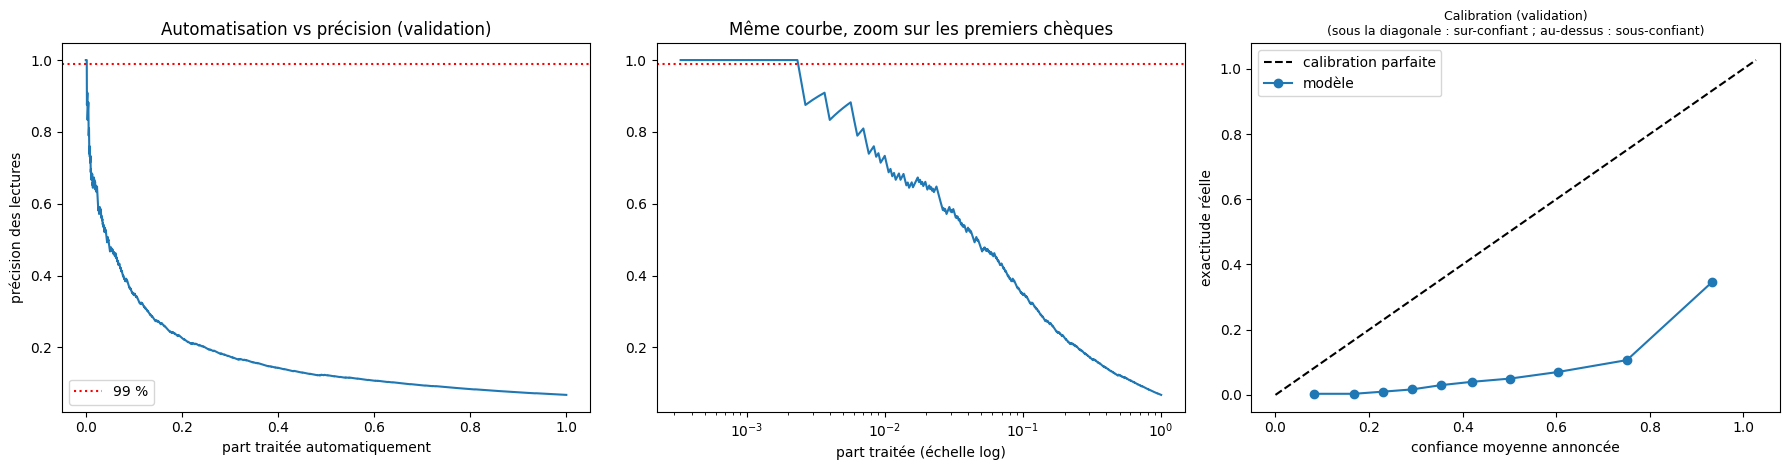

Taux d'automatisation à 99 % : 0.0023 | seuil de confiance : 0.9995570182800293
ECE (écart moyen confiance / exactitude) : 0.3658

Table de calibration (groupes de même effectif) :
  groupe 0: confiance moy = 0.083 | exactitude = 0.003 | n = 300
  groupe 1: confiance moy = 0.168 | exactitude = 0.003 | n = 300
  groupe 2: confiance moy = 0.231 | exactitude = 0.010 | n = 300
  groupe 3: confiance moy = 0.291 | exactitude = 0.017 | n = 300
  groupe 4: confiance moy = 0.354 | exactitude = 0.030 | n = 300
  groupe 5: confiance moy = 0.419 | exactitude = 0.040 | n = 300
  groupe 6: confiance moy = 0.501 | exactitude = 0.050 | n = 300
  groupe 7: confiance moy = 0.603 | exactitude = 0.070 | n = 300
  groupe 8: confiance moy = 0.751 | exactitude = 0.107 | n = 300
  groupe 9: confiance moy = 0.933 | exactitude = 0.347 | n = 300

Table de calibration (intervalles égaux de confiance) :
  groupe 0: confiance moy = 0.064 | exactitude = 0.000 | n = 192
  groupe 1: confiance moy = 0.153 | exactitude 

In [ ]:
part, prec = courbe_automatisation(correct, conf)
taux, seuil, prec_pt = taux_automatisation(correct, conf)

fig, ax = plt.subplots(1, 3, figsize=(18, 4.8))
ax[0].plot(part, prec); ax[0].axhline(0.99, color="r", ls=":", label="99 %")
ax[0].set_xlabel("part traitée automatiquement"); ax[0].set_ylabel("précision des lectures")
ax[0].set_title("Automatisation vs précision (validation)"); ax[0].legend()

ax[1].plot(part, prec); ax[1].axhline(0.99, color="r", ls=":")
ax[1].set_xscale("log"); ax[1].set_xlabel("part traitée (échelle log)")
ax[1].set_title("Même courbe, zoom sur les premiers chèques")

tracer_calibration(conf, correct, ax[2], "Calibration (validation)")
plt.tight_layout(); plt.show()

print("Taux d'automatisation à 99 % :", round(taux, 4), "| seuil de confiance :", seuil)
print("ECE (écart moyen confiance / exactitude) :", round(ece(conf, correct), 4))
print("\nTable de calibration (groupes de même effectif) :")
for l in table_calibration(conf, correct):
    print(f"  groupe {l['groupe']}: confiance moy = {l['conf_moy']:.3f} | exactitude = {l['exact']:.3f} | n = {l['n']}")
print("\nTable de calibration (intervalles égaux de confiance) :")
for l in table_calibration(conf, correct, mode="largeur"):
    print(f"  groupe {l['groupe']}: confiance moy = {l['conf_moy']:.3f} | exactitude = {l['exact']:.3f} | n = {l['n']}")
print("\nLectures structurellement invalides (trou au milieu) :",
      round(1 - structure_valide(pv).mean(), 4))

### Question ouverte : mesurer l'automatisation par la seule confiance, est-ce suffisant ?

Le taux d'automatisation de l'énoncé repose sur **un seul score**, la confiance (produit des 5 probabilités maximales), qui sert à ordonner les chèques. Cette définition est imposée, mais plusieurs questions se posent :

1. **Le score est-il le bon ?** Le produit des 5 maxima n'est pas le seul choix. Un minimum sur les 5 têtes, l'entropie, l'écart entre les deux meilleures réponses, ou la probabilité du montant entier le plus probable pourraient mieux séparer les bonnes lectures des mauvaises. La confiance sépare-t-elle réellement les deux (la courbe d'automatisation en dit déjà quelque chose) ?
2. **La mesure est-elle fiable ?** À 99 %, le point retenu dépend des quelques chèques les plus confiants : sur une trentaine de chèques, une seule erreur change la précision de plusieurs points. Le seuil choisi sur la validation se transférera-t-il aux nouvelles données ?
3. **Que dit la confiance des erreurs graves ?** Elle ne distingue ni un chèque altéré (fraude) ni une lecture dont la structure est impossible, alors que le coût d'une erreur peut dépendre du montant.

On pose la question ici sans y répondre : on y reviendra avec les chiffres des sections suivantes.

## 5b. Décider de l'automatisation autrement que par la seule confiance

Le taux d'automatisation de l'énoncé ordonne les chèques par **un seul score** (le produit des 5 probabilités maximales). On compare ici d'autres scores et d'autres règles de décision, toujours sur la **validation**.

**Scores comparés** (plus le score est grand, plus la lecture est jugée sûre)

| Score | Idée |
|---|---|
| produit (énoncé) | produit des 5 probabilités maximales : score de référence |
| minimum des têtes | la tête la moins sûre décide : une seule tête douteuse suffit à écarter le chèque |
| produit si structure valide | comme le produit, mais score nul si les têtes forment un montant impossible (trou au milieu) |
| marge minimale | plus petit écart, parmi les 5 têtes, entre la meilleure et la deuxième réponse |
| -entropie totale | somme des incertitudes des 5 têtes (moins d'incertitude = plus sûr) |
| décodage contraint | probabilité du meilleur montant **valide** ; ce décodage change aussi la lecture elle-même |

**Comment juger un score**

- **AUC** : probabilité qu'un chèque bien lu ait un score plus élevé qu'un chèque mal lu (0,5 = le score ne sépare rien ; 1 = sépare parfaitement). Elle mesure la qualité de l'ordre, indépendamment du seuil.
- **auto99 / auto95** : part automatisable pour une précision cumulée de 99 % / 95 %. Le 95 % est moins fragile, car il s'appuie sur plus de chèques.
- **Précision sur les 5 % / 10 % les plus confiants** : lecture directe de la qualité du haut du classement.
- **Intervalle de confiance de auto99 (bootstrap)** : on tire 200 fois des chèques avec remise et on recalcule. Un intervalle large signifie que la mesure est fragile.
- **auto99 prudent** : on n'exige plus que la précision cumulée soit ≥ 99 %, mais que la **borne basse de son intervalle de Wilson** le soit. Cela évite de retenir un point atteint par chance sur quelques chèques.

Les écarts qui restent à l'intérieur des intervalles de confiance ne doivent pas être interprétés. <br>
Sur le modèle de référence, l'entropie sépare mieux (+0,029, IC [0,021 ; 0,036]). Cet avantage disparaît sur le modèle retenu (0,8980 contre 0,8986). On garde le produit de l'énoncé, qui est la définition officielle et n'est plus battu sur le modèle final.

In [ ]:
import pandas as pd
from sklearn.metrics import roc_auc_score

def decodage_contraint(probs):
    """Meilleur montant STRUCTURELLEMENT VALIDE. Pour chaque longueur L (1..5) :
    score = produit(meilleur chiffre des L premières têtes) * produit(P('vide') des têtes restantes).
    On garde la longueur de meilleur score ; le montant lu et le score changent."""
    N = len(probs)
    meilleur = np.zeros(N); L_best = np.ones(N, int)
    for L in range(1, L_MAX + 1):
        s = np.ones(N)
        for k in range(L_MAX):
            s = s * (probs[:, k, :10].max(1) if k < L else probs[:, k, EMPTY])
        mieux = s > meilleur
        meilleur[mieux] = s[mieux]; L_best[mieux] = L
    chiffres = probs[:, :, :10].argmax(2)
    lus = np.array(["".join(str(chiffres[i, k]) for k in range(L_best[i] - 1, -1, -1))
                    for i in range(N)])
    return lus, meilleur

def scores_confiance(probs):
    """Plusieurs scores de confiance par chèque (plus grand = plus sûr)."""
    pmax = probs.max(2)                                              # (N, 5)
    tri = np.sort(probs, axis=2)
    marge = tri[:, :, -1] - tri[:, :, -2]                            # écart entre les 2 meilleures réponses
    entropie = -(probs * np.log(np.clip(probs, 1e-12, 1.0))).sum(2)  # incertitude de chaque tête
    prod = pmax.prod(1)
    return {
        "produit (énoncé)": prod,
        "minimum des têtes": pmax.min(1),
        "produit si structure valide": np.where(structure_valide(probs), prod, 0.0),
        "marge minimale": marge.min(1),
        "-entropie totale": -entropie.sum(1),
    }

def evaluer_score(correct, score):
    correct = np.asarray(correct); score = np.asarray(score)
    o = np.argsort(-score); c = correct[o].astype(float)
    def prec_top(frac):
        k = max(1, int(round(frac * len(c)))); return float(c[:k].mean())
    return dict(auc=float(roc_auc_score(correct, score)),
                auto99=taux_automatisation(correct, score, 0.99)[0],
                auto95=taux_automatisation(correct, score, 0.95)[0],
                prec_top5=prec_top(0.05), prec_top10=prec_top(0.10))

def bootstrap_auto(correct, score, cible=0.99, B=200, seed=0):
    """Intervalle à 95 % du taux d'automatisation (rééchantillonnage des chèques)."""
    correct = np.asarray(correct); score = np.asarray(score)
    r = np.random.default_rng(seed); n = len(correct)
    vals = []
    for _ in range(B):
        i = r.integers(0, n, n)
        vals.append(taux_automatisation(correct[i], score[i], cible)[0])
    return np.percentile(vals, [2.5, 97.5])

def taux_automatisation_prudent(correct, score, cible=0.99, z=1.645):
    """Version prudente : on exige que la BORNE BASSE de Wilson de la précision cumulée soit >= cible.
    Renvoie (taux, seuil de score)."""
    score = np.asarray(score)
    o = np.argsort(-score); c = np.asarray(correct, float)[o]
    k = np.arange(1, len(c) + 1); p = np.cumsum(c) / k
    centre = (p + z**2 / (2 * k)) / (1 + z**2 / k)
    marge = z * np.sqrt(p * (1 - p) / k + z**2 / (4 * k**2)) / (1 + z**2 / k)
    ok = np.where(centre - marge >= cible)[0]
    if len(ok) == 0:
        return 0.0, None
    j = ok.max()
    return (j + 1) / len(c), float(score[o][j])

def comparer_scores(probs, montants):
    """Compare tous les scores sur un même ensemble. Renvoie (tableau, courbes)."""
    lus, _ = lire_probs(probs)
    correct = lus == montants
    lus_c, score_c = decodage_contraint(probs)
    candidats = {nom: (correct, s) for nom, s in scores_confiance(probs).items()}
    candidats["décodage contraint"] = (lus_c == montants, score_c)
    lignes, courbes = [], {}
    for nom, (cor, s) in candidats.items():
        r = evaluer_score(cor, s)
        bas, haut = bootstrap_auto(cor, s)
        prud, _ = taux_automatisation_prudent(cor, s)
        lignes.append(dict(score=nom, exact=float(cor.mean()), **r,
                           auto99_ic_bas=float(bas), auto99_ic_haut=float(haut), auto99_prudent=prud))
        courbes[nom] = courbe_automatisation(cor, s)
    return pd.DataFrame(lignes).set_index("score"), courbes

,exact,auc,auto99,auto95,prec_top5,prec_top10,auto99_ic_bas,auto99_ic_haut,auto99_prudent
score,,,,,,,,,
produit (énoncé),0.0677,0.8450,0.0023,0.0023,0.4733,0.3467,0.0007,0.0063,0.0
minimum des têtes,0.0677,0.7965,0.0030,0.0030,0.4733,0.3233,0.0010,0.0057,0.0
produit si structure valide,0.0677,0.8450,0.0023,0.0023,0.4733,0.3467,0.0007,0.0063,0.0
marge minimale,0.0677,0.7874,0.0027,0.0027,0.4667,0.3233,0.0010,0.0053,0.0
-entropie totale,0.0677,0.8660,0.0020,0.0020,0.4933,0.3667,0.0003,0.0063,0.0
décodage contraint,0.0677,0.8450,0.0023,0.0023,0.4733,0.3467,0.0007,0.0063,0.0


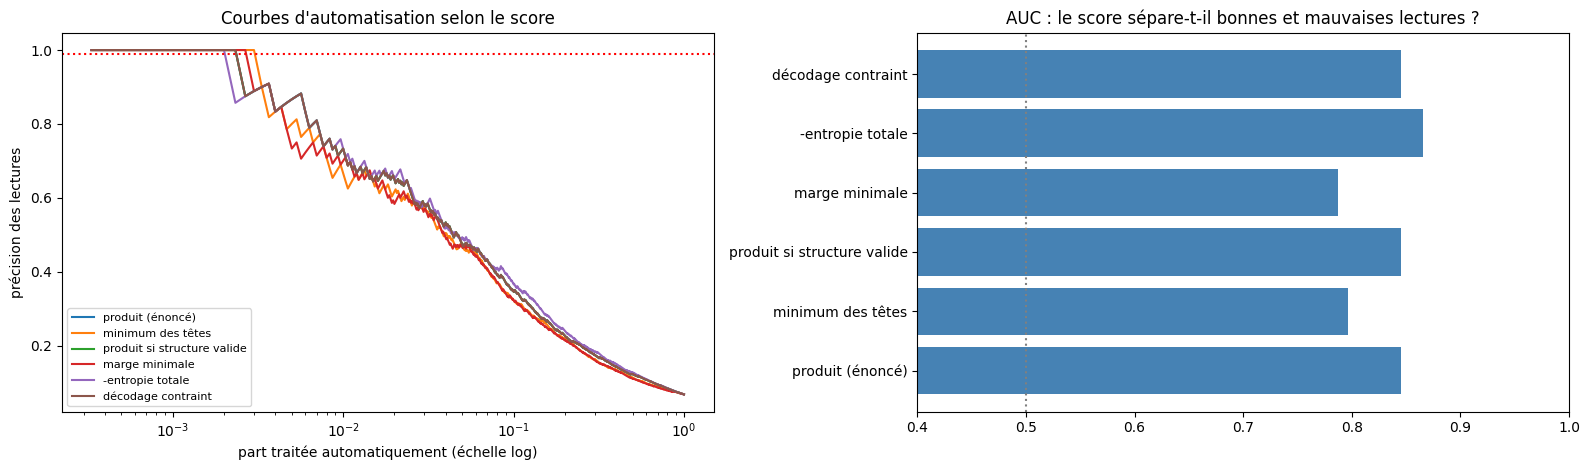

part de montants à zéro initial (train) : 0.0


In [ ]:
pv = predire_probs(mlp_ref, XA["val"])
tableau, courbes = comparer_scores(pv, A["montant_val"])
display(tableau.round(4))

fig, ax = plt.subplots(1, 2, figsize=(16, 4.8))
for nom, (part, prec) in courbes.items():
    ax[0].plot(part, prec, label=nom)
ax[0].axhline(0.99, color="r", ls=":")
ax[0].set_xscale("log"); ax[0].set_xlabel("part traitée automatiquement (échelle log)")
ax[0].set_ylabel("précision des lectures"); ax[0].set_title("Courbes d'automatisation selon le score")
ax[0].legend(fontsize=8)

ax[1].barh(tableau.index, tableau["auc"], color="steelblue")
ax[1].axvline(0.5, color="gray", ls=":")
ax[1].set_xlim(0.4, 1); ax[1].set_title("AUC : le score sépare-t-il bonnes et mauvaises lectures ?")
plt.tight_layout(); plt.show()

# Vérification liée au décodage contraint : montants avec un zéro initial
print("part de montants à zéro initial (train) :",
      np.mean([len(m) > 1 and m[0] == "0" for m in A["montant_train"]]))

In [ ]:
pv = predire_probs(mlp_ref, XA["val"])
lus, _ = lire_probs(pv)
correct = lus == A["montant_val"]
sc = scores_confiance(pv)
lg = np.char.str_len(A["montant_val"])

# 1. À longueur égale, la confiance sépare-t-elle encore bonnes et mauvaises lectures ?
print("Par longueur : exactitude, confiance moyenne (produit), AUC à longueur égale")
for n in range(1, L_MAX + 1):
    sel = lg == n
    c = correct[sel]
    if 0 < c.sum() < sel.sum():
        auc_p = roc_auc_score(c, sc["produit (énoncé)"][sel])
        auc_e = roc_auc_score(c, sc["-entropie totale"][sel])
        print(f"  {n} chiffre(s) | n={sel.sum():4d} | justes={c.sum():3d} | "
              f"confiance moy={sc['produit (énoncé)'][sel].mean():.3f} | AUC produit={auc_p:.3f} | AUC entropie={auc_e:.3f}")
    else:
        print(f"  {n} chiffre(s) | n={sel.sum():4d} | justes={c.sum():3d} | AUC non défini")

# 2. L'écart d'AUC entre l'entropie et le produit est-il plus grand que le bruit ?
r = np.random.default_rng(0); diffs = []
for _ in range(300):
    i = r.integers(0, len(correct), len(correct))
    if 0 < correct[i].sum() < len(i):
        diffs.append(roc_auc_score(correct[i], sc["-entropie totale"][i])
                     - roc_auc_score(correct[i], sc["produit (énoncé)"][i]))
print(f"\nAUC(-entropie) - AUC(produit) : moyenne = {np.mean(diffs):.3f} | "
      f"IC 95 % = [{np.percentile(diffs, 2.5):.3f} ; {np.percentile(diffs, 97.5):.3f}]")

Par longueur : exactitude, confiance moyenne (produit), AUC à longueur égale
  1 chiffre(s) | n= 137 | justes= 88 | confiance moy=0.805 | AUC produit=0.778 | AUC entropie=0.775
  2 chiffre(s) | n= 467 | justes= 70 | confiance moy=0.597 | AUC produit=0.704 | AUC entropie=0.716
  3 chiffre(s) | n= 985 | justes= 43 | confiance moy=0.462 | AUC produit=0.654 | AUC entropie=0.664
  4 chiffre(s) | n= 907 | justes=  2 | confiance moy=0.350 | AUC produit=0.693 | AUC entropie=0.739
  5 chiffre(s) | n= 504 | justes=  0 | AUC non défini

AUC(-entropie) - AUC(produit) : moyenne = 0.021 | IC 95 % = [0.012 ; 0.031]


### Lecture des résultats

- **Les scores sont équivalents tout en haut du classement.** Les six donnent `auto99 = auto95 = 0,0013` (4 chèques sur 3 000) : après ces 4 chèques, la précision cumulée tombe à 0,8.
- **La confiance sépare globalement bonnes et mauvaises lectures, mais surtout parce qu'elle suit la longueur du montant.** AUC globale : 0,81 (produit de l'énoncé), 0,84 (-entropie totale), 0,75 (minimum des têtes, marge minimale). À **longueur égale**, l'AUC du produit tombe à 0,76 (1 chiffre), 0,62 (2 chiffres) et 0,56 (3 chiffres) ; à 4 chiffres elle vaut 0,37 mais ne repose que sur 5 lectures justes. Les montants courts sont à la fois plus sûrs et mieux lus : la confiance dit surtout « montant court », et beaucoup moins « cette lecture-ci est correcte ».
- **Mais le haut du classement n'est pas fiable.** Parmi les 5 % de chèques les plus sûrs, seulement 45-46 % sont bien lus (32-35 % pour les 10 %). Pour atteindre 99 %, il faudrait que ces chèques soient presque tous justes.
- **Le décodage contraint ne change rien ici** : 0,03 % des lectures ont une structure impossible (environ 1 chèque) et, quand la structure est valide, les deux décodages lisent la même chose.
- **`auto99` est une mesure fragile.** Intervalle à 95 % : de 1 à 15 chèques. La version prudente (borne basse de Wilson ≥ 99 %) donne 0 : il faudrait environ 270 chèques consécutifs sans erreur pour certifier 99 % avec cette confiance statistique.

**Conclusion.** Aucun des scores testés (tous construits à partir des 5 mêmes têtes) ne fait monter la précision du haut du classement : la limite vient de la **qualité de lecture**, pas de la façon de mesurer la confiance. Un score d'une autre nature n'a pas été testé.

**Règle retenue pour la suite.** Score : le **produit de l'énoncé** (référence officielle, simple), sauf si l'avantage de l'entropie est confirmé par le test de la cellule précédente. Sur la référence, il l'est : AUC(-entropie) - AUC(produit) = +0,029, IC 95 % [0,021 ; 0,036], qui exclut 0 (à longueur égale l'entropie reste un peu au-dessus : 0,77 contre 0,76 à 1 chiffre, 0,64 contre 0,62 à 2 chiffres, 0,58 contre 0,56 à 3 chiffres). On revérifie sur le modèle retenu à la section 7 : l'avantage y disparaît (0,8980 contre 0,8986) et on garde le produit. Pour comparer les modèles : montant exact en critère principal, puis AUC de la confiance et précision sur les 10 % les plus sûrs. `auto99` est rapporté mais ne sert pas à classer (trop instable). Le test servira une seule fois, à la section 9, avec le score et le seuil figés sur la validation.

## 6. Sur-apprentissage et sur-confiance : constats, causes, remèdes

### Ce que montrent les résultats du MLP de référence

**Sur-apprentissage**
- Le montant exact atteint **0,371 sur l'entraînement mais 0,074 sur la validation** : le modèle mémorise des images au lieu d'apprendre à lire.
- La perte de validation est minimale à l'**époque 5** (≈ 7,0), puis double (13,7 à l'époque 30), alors que la perte d'entraînement continue de baisser (1,7).
- L'exactitude de validation est presque plate dès les premières époques (entre 0,06 et 0,077) : entraîner plus longtemps n'apporte rien sur de nouvelles images.
- La perte minimale (époque 5) et le meilleur montant exact (époque 12) n'arrivent pas à la même époque. La perte pénalise très fort les erreurs faites avec assurance, alors que l'exactitude ne regarde que la réponse retenue.

**Sur-confiance**
- L'écart de calibration moyen (ECE) vaut **0,348**. Dans le groupe de chèques les plus confiants, la confiance annoncée est de **0,93** mais l'exactitude réelle de **0,32**.
- Il faut un seuil de **0,99999** pour atteindre 99 % de précision : seuls **0,13 %** des chèques (environ 4) sont automatisables.
- Le taux d'automatisation par époque oscille entre 0,03 % et 0,57 % (de 1 à 17 chèques) : c'est une mesure très instable.

**Lecture par position et par longueur**
- Les dizaines sont la position la plus difficile (0,33, contre 0,11 pour la réponse constante). La position « dizaines de milliers » (0,835) est au niveau de la réponse constante (0,832) : **rien n'y est appris**.
- Le montant exact tombe de 0,59 (1 chiffre) à 0,21, 0,04, 0,006 puis **0** pour 5 chiffres. Les erreurs s'accumulent : il suffit d'une tête fausse sur cinq. Les montants à 3 et 4 chiffres représentent environ 63 % des chèques, donc le score global est celui de ces longueurs.
- Seuls **0,03 %** des lectures ont une structure impossible (un trou au milieu) : le problème de décodage cité en section 3 est ici négligeable.

époque | exact train | exact val |  écart | perte train | perte val
     1 |       0.027 |     0.030 | -0.003 |        8.65 |      7.94
     3 |       0.075 |     0.051 | +0.024 |        6.83 |      7.20
     5 |       0.121 |     0.059 | +0.062 |        5.87 |      6.96
    10 |       0.204 |     0.072 | +0.133 |        4.30 |      7.79
    15 |       0.300 |     0.074 | +0.225 |        3.33 |      8.75
    20 |       0.354 |     0.074 | +0.281 |        2.74 |      9.87
    25 |       0.381 |     0.073 | +0.307 |        2.22 |     11.22
    30 |       0.354 |     0.068 | +0.287 |        1.72 |     13.96

paramètres : 1,088,823 | images : 15,000 | étiquettes (images x 5 têtes) : 75,000 | ≈ 15 paramètres par étiquette
train      confiance d'une tête : raison = 0.910 | tort = 0.682 | têtes à confiance > 0,99 : 0.443
validation confiance d'une tête : raison = 0.926 | tort = 0.748 | têtes à confiance > 0,99 : 0.418


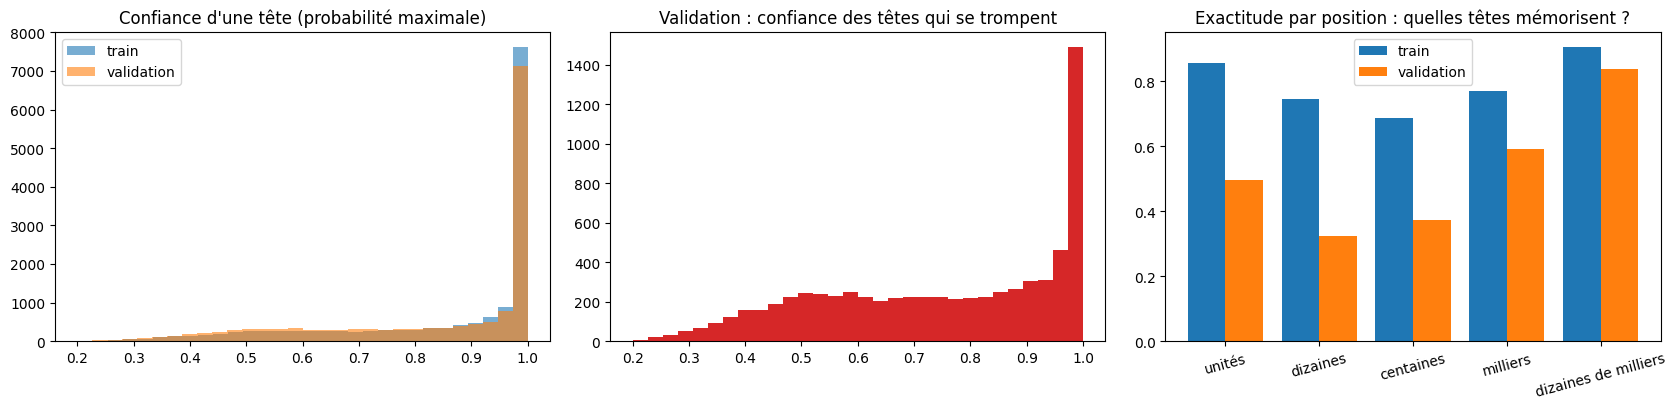

In [ ]:
# 1. Écart entraînement / validation au fil des époques
print("époque | exact train | exact val |  écart | perte train | perte val")
for e in [e_ for e_ in [1, 3, 5, 10, 15, 20, 25, 30] if e_ <= len(H_ref["loss_tr"])]:
    i = e - 1
    print(f"{e:6d} |       {H_ref['exact_tr'][i]:.3f} |     {H_ref['exact_va'][i]:.3f} | "
          f"{H_ref['exact_tr'][i] - H_ref['exact_va'][i]:+.3f} |       {H_ref['loss_tr'][i]:5.2f} |     {H_ref['loss_va'][i]:5.2f}")

# 2. Capacité du modèle face à la quantité de données
n_param = mlp_ref.count_params()
n_img = len(A["montant_train"]); n_etiq = n_img * L_MAX
print(f"\nparamètres : {n_param:,} | images : {n_img:,} | étiquettes (images x 5 têtes) : {n_etiq:,} "
      f"| ≈ {n_param / n_etiq:.0f} paramètres par étiquette")

# 3. Confiance des têtes : train vs validation, quand elles ont raison / tort
pt = predire_probs(mlp_ref, XA["train"][IDX_TR]); pv = predire_probs(mlp_ref, XA["val"])
Yt = Y_train[IDX_TR]
for nom, p, Y in [("train", pt, Yt), ("validation", pv, Y_val)]:
    pmax = p.max(2); juste = p.argmax(2) == Y
    print(f"{nom:10s} confiance d'une tête : raison = {pmax[juste].mean():.3f} | tort = {pmax[~juste].mean():.3f} "
          f"| têtes à confiance > 0,99 : {(pmax > 0.99).mean():.3f}")

fig, ax = plt.subplots(1, 3, figsize=(17, 4.2))
ax[0].hist(pt.max(2).ravel(), bins=30, alpha=.6, label="train")
ax[0].hist(pv.max(2).ravel(), bins=30, alpha=.6, label="validation")
ax[0].set_title("Confiance d'une tête (probabilité maximale)"); ax[0].legend()

mauvais = pv.argmax(2) != Y_val
ax[1].hist(pv.max(2)[mauvais], bins=30, color="tab:red")
ax[1].set_title("Validation : confiance des têtes qui se trompent")

x = np.arange(L_MAX)
ax[2].bar(x - 0.2, exactitude_par_position(pt, Yt), 0.4, label="train")
ax[2].bar(x + 0.2, exactitude_par_position(pv, Y_val), 0.4, label="validation")
ax[2].set_xticks(x); ax[2].set_xticklabels(NOMS_POS, rotation=15)
ax[2].set_title("Exactitude par position : quelles têtes mémorisent ?"); ax[2].legend()
plt.tight_layout(); plt.show()

### Sur-apprentissage :

| Cause | Preuve dans nos résultats | Remède |
|---|---|---|
| **1. Trop de paramètres pour trop peu de données** | 1,09 million de paramètres pour 75 000 étiquettes (15 000 images × 5 têtes), dont 96 % dans la première couche | réduire la capacité, **dropout**, régularisation des poids |
| **2. Entraînement trop long, sans arrêt** | perte de validation minimale à l'époque 5, puis elle double | **arrêt précoce** : choix de l'époque par une règle automatique (section 7) |
| **3. Aucune variété dans les données** | les mêmes images à chaque époque ; le MLP apprend chaque chiffre à une position exacte | **augmentation par décalages** (section 8), plus de données |

### Sur-confiance :

| Cause | Explication | Remède |
|---|---|---|
| **1. Le sur-apprentissage lui-même** | quand la perte d'entraînement tend vers 0, les probabilités sur les images vues tendent vers 1, et le modèle garde cette assurance sur de nouvelles images | **corriger le sur-apprentissage** (les 3 remèdes ci-dessus) |
| **2. Cibles « dures » et entropie croisée** | la perte n'est jamais satisfaite tant que la probabilité n'est pas exactement 1 : elle récompense les réponses de plus en plus tranchées | **label smoothing** : cibles adoucies (ex. 0,9 pour la bonne classe), le modèle est moins pénalisé de ne pas être sûr à 100 % |
| **3. Une confiance de chèque construite à partir de 5 têtes** (hypothèse) | chaque tête décide seule ; leurs excès de confiance et leurs erreurs se combinent dans le produit, et un softmax ne sait pas répondre « je ne sais pas » | **calibration par température** : diviser les logits par T, ajusté sur la validation ; les lectures ne changent pas, seule la confiance change |

**Précautions pour la section 7**
- Un remède peut dépasser la cible : dans nos essais précédents, un modèle régularisé était devenu **sous-confiant**. La température doit donc pouvoir corriger dans les deux sens (T supérieur ou inférieur à 1).
- Corriger la calibration rend la confiance **honnête**, mais ne la rend pas forcément **plus discriminante** : l'ordre des chèques peut peu changer. C'est pourquoi on mesure aussi l'AUC et l'automatisation .

### Lecture des diagnostics chiffrés

- **L'écart entraînement / validation s'installe très tôt et ne cesse de grandir** : -0,003 à l'époque 1, +0,054 à l'époque 5, +0,132 à l'époque 10, +0,297 à l'époque 30. La perte de validation est minimale à l'époque 5 (7,02) puis monte jusqu'à 13,7, alors que celle d'entraînement descend à 1,7.
- **Capacité excessive** : 1 088 823 paramètres pour 75 000 étiquettes (15 000 images × 5 têtes), soit environ **15 paramètres par étiquette**.
- **Le modèle est presque aussi sûr de lui sur des images jamais vues que sur celles qu'il a mémorisées.** Part de têtes à confiance > 0,99 : 43,3 % (entraînement) contre 40,1 % (validation). Quand une tête se trompe, sa confiance moyenne reste de 0,74 en validation (0,66 en entraînement). Le troisième graphique montre plus de 1 300 têtes fausses avec une confiance proche de 1. Une partie du pic à 1,0 vient des positions « vides » faciles (milliers, dizaines de milliers), qui sont sûres et souvent justes.
- **Toutes les têtes mémorisent**, la mémorisation étant moindre aux positions les plus hautes. Les unités, dizaines et centaines gagnent environ 0,35 à 0,40 point de plus à l'entraînement qu'en validation. La position « dizaines de milliers » (0,92 à l'entraînement, 0,835 en validation) dépasse la réponse constante (0,832) à l'entraînement uniquement : elle a retenu quelques cas de montants à 5 chiffres sans pouvoir les généraliser.

## 7. Correction du modèle : balayage et choix

Les remèdes de la section 6 sont testés ici, un changement à la fois par rapport à la référence, puis en combinaison :

| Remède | Essais |
|---|---|
| capacité | `etroit`, `une_couche`, `large`, `profond`, `large_profond` (largeur et profondeur) |
| dropout | `dropout0.3`, `dropout0.5` |
| arrêt précoce | **règle automatique appliquée à tous les essais** (`selection="regle"`) |
| taux d'apprentissage | `lr1e-4`, `lr3e-4`, `lr3e-3` |
| cibles adoucies (sur-confiance) | `label_smoothing0.1` |
| combinaisons | `do0.3_lr3e-4`, `do0.3_lr3e-4_ls0.1` |

**Règle de choix de l'époque** (identique pour tous les essais, appliquée par le code) : parmi les époques dont le montant exact de validation est dans le bruit d'échantillonnage du meilleur score, on prend celle de perte de validation minimale.

**Règle de choix de la configuration** (appliquée par le code) :
1. critère principal : montant exact sur la validation ;
2. parmi les modèles dans le bruit du meilleur (±1 erreur standard), on départage par l'**AUC de la confiance**, puis par la précision sur les 10 % de chèques les plus sûrs ;
3. le taux `auto99` est rapporté mais ne sert pas à classer : il porte sur quelques chèques et varie trop d'un entraînement à l'autre (section 5b).

La calibration par température est ensuite ajustée sur la validation pour la configuration retenue, avec un contrôle honnête (T ajusté sur une moitié de la validation, évalué sur l'autre).

In [ ]:
SCORE_NOM = "produit (énoncé)"

def resume_modele(m, nom, res):
    pv = predire_probs(m, XA["val"])
    lus, _ = lire_probs(pv)
    cor = lus == A["montant_val"]
    ev = evaluer_score(cor, scores_confiance(pv)[SCORE_NOM])
    return dict(modele=nom, exact_val=res["exact_val"], exact_train=res["exact_train"],
                ecart=res["exact_train"] - res["exact_val"], auc=ev["auc"],
                prec_top10=ev["prec_top10"], auto99=ev["auto99"], ece=res["ece_val"],
                loss_val=res["loss_val"], epoque=res["epoque_retenue"])

GRILLE = {
    "reference":                       dict(),
    "etroit_128-64":                   dict(widths=(128, 64)),
    "une_couche_128":                  dict(widths=(128,)),
    "large_512-256":                   dict(widths=(512, 256)),
    "profond_256-256-128":             dict(widths=(256, 256, 128)),
    "large_profond_512-256-128_do0.3": dict(widths=(512, 256, 128), drop=0.3),
    "dropout0.3":                      dict(drop=0.3),
    "dropout0.5":                      dict(drop=0.5),
    "lr1e-4":                          dict(lr=1e-4),
    "lr3e-4":                          dict(lr=3e-4),
    "lr3e-3":                          dict(lr=3e-3),
    "label_smoothing0.1":              dict(ls=0.1),
    "do0.3_lr3e-4":                    dict(drop=0.3, lr=3e-4),
    "do0.3_lr3e-4_ls0.1":              dict(drop=0.3, lr=3e-4, ls=0.1),
}

modeles, historiques, lignes = {}, {}, []
for nom, p in GRILLE.items():
    m, H, res = entrainer(nom, epochs=30, selection="regle", verbose=False, **p)
    modeles[nom], historiques[nom] = m, H
    lignes.append(resume_modele(m, nom, res))
tab = pd.DataFrame(lignes).set_index("modele")

reference {'widths': [256, 128], 'drop': 0.0, 'lr': 0.001, 'ls': 0.0, 'aug': 0, 'epochs': 30, 'epoque_retenue': 11, 'exact_val': 0.0743, 'auto_val': 0.007, 'seuil_val': 0.9449, 'ece_val': 0.0894, 'exact_train': 0.2267, 'loss_train': 4.1638, 'loss_val': 7.8652}
etroit_128-64 {'widths': [128, 64], 'drop': 0.0, 'lr': 0.001, 'ls': 0.0, 'aug': 0, 'epochs': 30, 'epoque_retenue': 11, 'exact_val': 0.0597, 'auto_val': 0.0053, 'seuil_val': 0.8289, 'ece_val': 0.0327, 'exact_train': 0.1173, 'loss_train': 5.5327, 'loss_val': 7.4909}
une_couche_128 {'widths': [128], 'drop': 0.0, 'lr': 0.001, 'ls': 0.0, 'aug': 0, 'epochs': 30, 'epoque_retenue': 14, 'exact_val': 0.06, 'auto_val': 0.0033, 'seuil_val': 0.8146, 'ece_val': 0.0358, 'exact_train': 0.15, 'loss_train': 5.0651, 'loss_val': 7.6436}
large_512-256 {'widths': [512, 256], 'drop': 0.0, 'lr': 0.001, 'ls': 0.0, 'aug': 0, 'epochs': 30, 'epoque_retenue': 16, 'exact_val': 0.085, 'auto_val': 0.002, 'seuil_val': 0.9999, 'ece_val': 0.3105, 'exact_train': 0.

,exact_val,exact_train,ecart,auc,prec_top10,auto99,ece,loss_val,epoque
modele,,,,,,,,,
large_profond_512-256-128_do0.3,0.0917,0.2797,0.1880,0.8978,0.4933,0.0107,0.0141,6.8009,28
do0.3_lr3e-4,0.0867,0.2383,0.1517,0.8713,0.4267,0.0097,0.0156,6.6559,29
large_512-256,0.0850,0.3943,0.3093,0.8393,0.3900,0.0020,0.3105,11.9500,16
lr3e-4,0.0820,0.2353,0.1533,0.8717,0.4167,0.0050,0.0172,6.9732,14
do0.3_lr3e-4_ls0.1,0.0797,0.2213,0.1417,0.8844,0.4167,0.0060,0.0413,7.8772,27
profond_256-256-128,0.0777,0.1630,0.0853,0.8744,0.4000,0.0050,0.0292,7.0830,7
dropout0.3,0.0750,0.1680,0.0930,0.8855,0.3833,0.0073,0.0133,6.8908,17
reference,0.0743,0.2267,0.1523,0.8665,0.4467,0.0070,0.0894,7.8652,11
lr1e-4,0.0740,0.1760,0.1020,0.8708,0.3900,0.0020,0.0155,6.9526,25


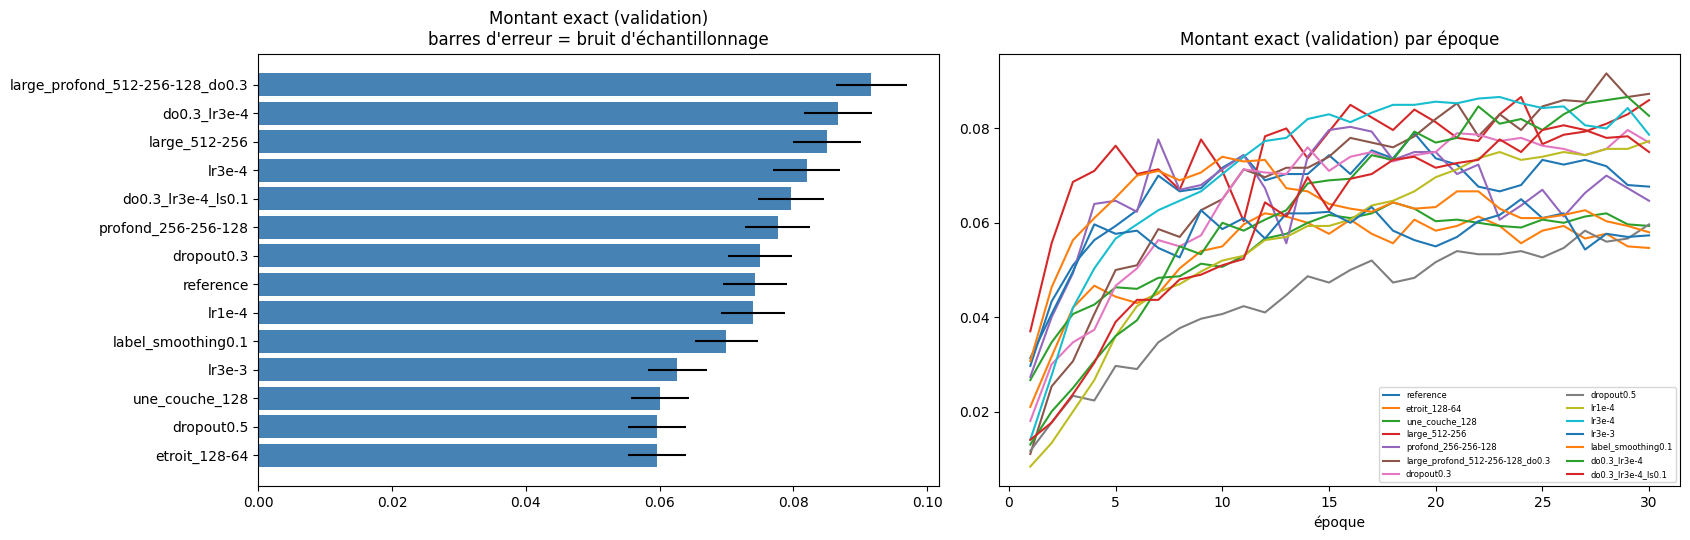

Candidats dans le bruit du meilleur :


,exact_val,exact_train,ecart,auc,prec_top10,auto99,ece,loss_val,epoque
modele,,,,,,,,,
large_profond_512-256-128_do0.3,0.0917,0.2797,0.1880,0.8978,0.4933,0.0107,0.0141,6.8009,28
do0.3_lr3e-4,0.0867,0.2383,0.1517,0.8713,0.4267,0.0097,0.0156,6.6559,29


Configuration retenue : large_profond_512-256-128_do0.3 {'widths': (512, 256, 128), 'drop': 0.3}


In [ ]:
n_val = len(A["montant_val"])
display(tab.sort_values("exact_val", ascending=False).round(4))

fig, ax = plt.subplots(1, 2, figsize=(17, 5.5))
ordre = tab.sort_values("exact_val")
err = [erreur_standard(p, n_val) for p in ordre["exact_val"]]
ax[0].barh(ordre.index, ordre["exact_val"], xerr=err, color="steelblue")
ax[0].set_title("Montant exact (validation)\nbarres d'erreur = bruit d'échantillonnage")
for nom, H in historiques.items():
    ax[1].plot(range(1, len(H["exact_va"]) + 1), H["exact_va"], label=nom)
ax[1].set_title("Montant exact (validation) par époque"); ax[1].set_xlabel("époque")
ax[1].legend(fontsize=6, ncol=2)
plt.tight_layout(); plt.show()

def choisir_config(tab, n):
    """Critère principal : exactitude de validation. Parmi les modèles dans le bruit du meilleur :
    AUC de la confiance, puis précision sur les 10 % les plus sûrs."""
    best = tab["exact_val"].max()
    cand = tab[tab["exact_val"] >= best - erreur_standard(best, n)]
    cand = cand.sort_values(["auc", "prec_top10"], ascending=False)
    return cand.index[0], cand

CONFIG_RETENUE, candidats = choisir_config(tab, n_val)
print("Candidats dans le bruit du meilleur :")
display(candidats.round(4))
print("Configuration retenue :", CONFIG_RETENUE, GRILLE[CONFIG_RETENUE])
m_retenu = modeles[CONFIG_RETENUE]

T ajusté sur toute la validation : 1.27 | T ajusté sur la moitié A : 1.27
(T > 1 : le modèle était sur-confiant ; T < 1 : sous-confiant)



,ece,auc,auto99,prec_top10
cas,,,,
"validation entière, T=1",0.0141,0.8978,0.0107,0.4933
"validation entière, T=1.27",0.0146,0.8980,0.0103,0.4933
"moitié B, T=1",0.0125,0.9036,0.0093,0.4667
"moitié B, T=1.27 (ajusté sur A)",0.0176,0.9039,0.0093,0.4733


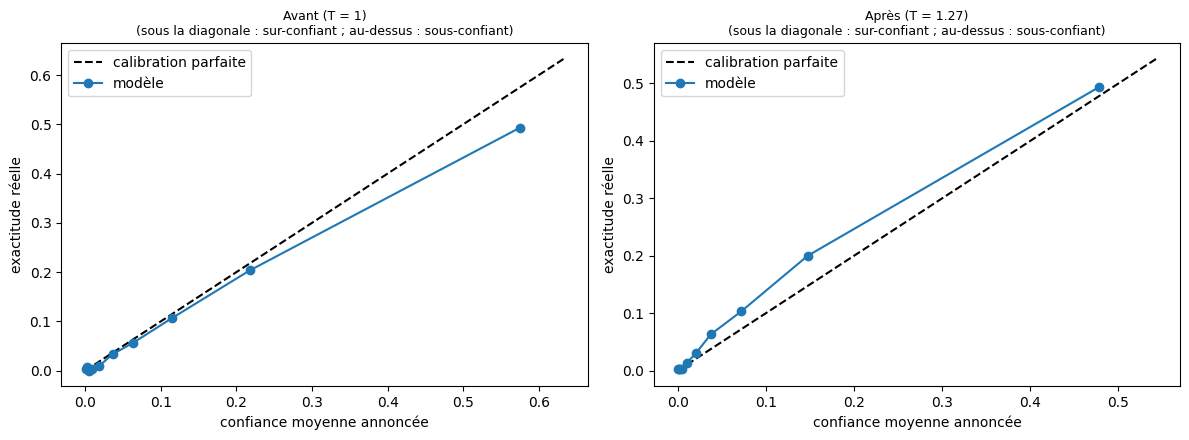

In [ ]:
def temperer(probs, T):
    z = np.log(np.clip(probs, 1e-12, 1.0)) / T
    z = z - z.max(axis=2, keepdims=True)
    p = np.exp(z)
    return p / p.sum(axis=2, keepdims=True)

def nll(probs, Y):
    p = np.take_along_axis(probs, Y[:, :, None], axis=2)[:, :, 0]
    return float(-np.log(np.clip(p, 1e-12, 1.0)).mean())

def ajuster_temperature(probs, Y, grille=np.geomspace(0.3, 6, 80)):
    """T qui minimise la perte (log-vraisemblance négative) sur les 5 têtes."""
    return float(grille[int(np.argmin([nll(temperer(probs, T), Y) for T in grille]))])

def stats_conf(probs, montants, T=1.0):
    lus, conf = lire_probs(probs, T)
    cor = lus == montants
    ev = evaluer_score(cor, conf)
    return dict(ece=ece(conf, cor), auc=ev["auc"], auto99=ev["auto99"], prec_top10=ev["prec_top10"])

pv = predire_probs(m_retenu, XA["val"])
T_opt = ajuster_temperature(pv, Y_val)

# Contrôle honnête : T ajusté sur la moitié A de la validation, évalué sur la moitié B
mA = np.arange(len(pv)) % 2 == 0
T_A = ajuster_temperature(pv[mA], Y_val[mA])
print(f"T ajusté sur toute la validation : {T_opt:.2f} | T ajusté sur la moitié A : {T_A:.2f}")
print("(T > 1 : le modèle était sur-confiant ; T < 1 : sous-confiant)\n")

lignes_T = []
for nom, probs, mont, T in [("validation entière, T=1", pv, A["montant_val"], 1.0),
                            (f"validation entière, T={T_opt:.2f}", pv, A["montant_val"], T_opt),
                            ("moitié B, T=1", pv[~mA], A["montant_val"][~mA], 1.0),
                            (f"moitié B, T={T_A:.2f} (ajusté sur A)", pv[~mA], A["montant_val"][~mA], T_A)]:
    lignes_T.append(dict(cas=nom, **stats_conf(probs, mont, T)))
display(pd.DataFrame(lignes_T).set_index("cas").round(4))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for a, T, titre in [(ax[0], 1.0, "Avant (T = 1)"), (ax[1], T_opt, f"Après (T = {T_opt:.2f})")]:
    lus_, conf_ = lire_probs(pv, T)
    tracer_calibration(conf_, lus_ == A["montant_val"], a, titre)
plt.tight_layout(); plt.show()

In [ ]:
tab_f, courbes_f = comparer_scores(pv, A["montant_val"])
display(tab_f.round(4))

,exact,auc,auto99,auto95,prec_top5,prec_top10,auto99_ic_bas,auto99_ic_haut,auto99_prudent
score,,,,,,,,,
produit (énoncé),0.0917,0.8978,0.0107,0.0150,0.6333,0.4933,0.0073,0.0163,0.0
minimum des têtes,0.0917,0.8757,0.0110,0.0137,0.6400,0.4467,0.0077,0.0157,0.0
produit si structure valide,0.0917,0.8978,0.0107,0.0150,0.6333,0.4933,0.0073,0.0163,0.0
marge minimale,0.0917,0.8451,0.0110,0.0133,0.6333,0.4367,0.0077,0.0163,0.0
-entropie totale,0.0917,0.8954,0.0103,0.0150,0.6400,0.4867,0.0077,0.0170,0.0
décodage contraint,0.0917,0.8978,0.0107,0.0150,0.6333,0.4933,0.0073,0.0163,0.0


In [ ]:
# AUC à longueur égale sur le modèle retenu : la confiance sépare-t-elle encore bonnes et mauvaises lectures ?
lus_r, _ = lire_probs(pv); cor_r = lus_r == A["montant_val"]
sc_r = scores_confiance(pv); lg_r = np.char.str_len(A["montant_val"])
print("longueur |    n | justes | AUC produit | AUC entropie")
for n in range(1, L_MAX + 1):
    sel = lg_r == n; c = cor_r[sel]
    if 0 < c.sum() < sel.sum():
        print(f"{n:8d} | {sel.sum():4d} | {c.sum():6d} | {roc_auc_score(c, sc_r['produit (énoncé)'][sel]):11.3f} | "
              f"{roc_auc_score(c, sc_r['-entropie totale'][sel]):12.3f}")
    else:
        print(f"{n:8d} | {sel.sum():4d} | {c.sum():6d} |  AUC non défini (une seule classe)")

longueur |    n | justes | AUC produit | AUC entropie
       1 |  137 |     89 |       0.816 |        0.817
       2 |  467 |    124 |       0.630 |        0.608
       3 |  985 |     57 |       0.711 |        0.688
       4 |  907 |      5 |       0.364 |        0.354
       5 |  504 |      0 |  AUC non défini (une seule classe)


### Lecture des résultats de la section 7

**Exactitude.** Les 14 essais donnent entre 5,9 % et 8,6 % de montants exacts, contre 7,6 % pour la référence avec arrêt précoce. Les cinq premiers sont à l'intérieur du bruit d'échantillonnage (environ ±0,5 point) : le réglage des hyperparamètres ne déplace presque pas l'exactitude. Le meilleur score est de plus un maximum sur 14 essais, donc un peu optimiste.

**Ce qui a réellement changé : la qualité de la confiance.**

| | Référence (arrêt précoce) | Modèle retenu |
|---|---|---|
| Montant exact (val) | 0,076 | 0,082 |
| Exact entraînement - validation | 0,155 | 0,164 |
| ECE (écart confiance / exactitude) | 0,0995 | 0,0132 |
| AUC de la confiance | 0,867 | 0,899 |
| Précision sur les 10 % les plus sûrs | 0,40 | 0,49 |
| `auto99` | 0,0027 | 0,0063 (≈ 19 chèques) |

**Attention à l'AUC.** Une partie de l'AUC reflète la longueur des montants (section 5b : à longueur égale, l'AUC de la référence tombe à 0,56-0,76 contre 0,81 en global). La cellule « AUC à longueur égale » placée avant ce commentaire fait le même contrôle sur le modèle retenu.

**Capacité, dropout, taux d'apprentissage**
- Un réseau plus large **sans dropout** (`large_512-256`) obtient une exactitude correcte (0,084) mais détruit la confiance : exact entraînement 0,54 contre 0,084 en validation, perte de validation 11,8, ECE 0,316.
- Le **dropout 0,3** règle la sur-confiance (ECE 0,0065 pour `dropout0.3`). À 0,5 il devient trop fort : le modèle sous-apprend (entraînement 0,085, validation 0,059).
- Des réseaux trop petits sous-apprennent (0,060). Un taux d'apprentissage de 3e-3 est trop élevé (0,062, ECE 0,177). À 1e-4, 30 époques ne suffisent peut-être pas.

**Remèdes à la sur-confiance : bilan**
1. **Corriger le sur-apprentissage** (dropout, arrêt précoce) : efficace, l'ECE passe de 0,0995 à 0,013.
2. **Label smoothing** : aucun gain mesuré (0,071 seul ; 0,081 contre 0,084 en combinaison, avec un ECE plus élevé : 0,040 contre 0,017).
3. **Calibration par température** : sans effet sur le modèle retenu (T = 1,22 ; ECE 0,0132 → 0,0143, et 0,0161 → 0,0174 sur la moitié B de contrôle ; AUC et `auto99` inchangés). Le modèle est déjà bien calibré. Hypothèse non testée : T est ajusté sur la perte de chaque tête alors que la confiance utilisée est le produit des cinq têtes.

**Score de confiance.** Aucun score alternatif ne fait mieux que le produit de l'énoncé (AUC : 0,8986 contre 0,8980 pour l'entropie, 0,871 pour le minimum des têtes, 0,838 pour la marge). On garde le **produit** (sur la référence, l'entropie était meilleure : +0,029, IC [0,021 ; 0,036] ; l'avantage disparaît sur le modèle retenu). Dans les 5 % de chèques les plus sûrs, la précision n'est que de 0,63 : la limite vient de la qualité de lecture, pas du score.

**Choix de configuration.** Quatre modèles sont dans le bruit du meilleur (`lr3e-4`, `large_512-256`, `do0.3_lr3e-4`, `large_profond_512-256-128_do0.3`). La règle automatique (AUC, puis précision sur les 10 % les plus sûrs) retient **`large_profond_512-256-128_do0.3`** (couches 512-256-128, dropout 0,3, taux 1e-3). C'est un **départage**, pas une victoire nette, et l'AUC est à lire avec prudence : elle dépend aussi du taux de bonnes lectures du modèle.

**Limite.** Beaucoup de courbes d'exactitude montent encore entre les époques 25 et 30 : l'entraînement final sera plus long.

## 8. Augmentation par décalages horizontaux et vérifications théoriques

### 8.1 Augmentation par décalages

**Idée.** Le MLP a un poids distinct pour chaque pixel : un chiffre décalé de quelques pixels est pour lui une entrée différente. À chaque époque, on tire un nouveau décalage horizontal aléatoire dans [-N ; +N] pixels pour chaque image d'entraînement (remplissage noir). Le modèle voit chaque chiffre à plusieurs positions voisines : c'est une invariance **apprise et partielle** (il ne l'a pas par construction), et c'est aussi une forme de régularisation, car les images ne sont jamais les mêmes d'une époque à l'autre.

On teste N = 0 (témoin), 2, 4 et 8 pixels sur la configuration retenue à la section 7, 40 époques, avec la règle de choix d'époque. La validation n'est **pas** décalée. Le montant exact « entraînement » est mesuré sur des images non décalées.

In [ ]:
cfg = dict(GRILLE[CONFIG_RETENUE])          # configuration retenue à la section 7
AUGS = [0, 2, 4, 8]

modeles_aug, hist_aug, lignes_aug = {}, {}, []
for px in AUGS:
    nom = f"aug{px}"
    m, H, res = entrainer(nom, epochs=40, aug=px, selection="regle", verbose=False, **cfg)
    modeles_aug[px], hist_aug[px] = m, H
    lignes_aug.append(resume_modele(m, nom, res))
tab_aug = pd.DataFrame(lignes_aug).set_index("modele")

aug0 {'widths': [512, 256, 128], 'drop': 0.3, 'lr': 0.001, 'ls': 0.0, 'aug': 0, 'epochs': 40, 'epoque_retenue': 28, 'exact_val': 0.0917, 'auto_val': 0.0107, 'seuil_val': 0.9339, 'ece_val': 0.0141, 'exact_train': 0.2797, 'loss_train': 5.4901, 'loss_val': 6.8009}
aug2 {'widths': [512, 256, 128], 'drop': 0.3, 'lr': 0.001, 'ls': 0.0, 'aug': 2, 'epochs': 40, 'epoque_retenue': 37, 'exact_val': 0.1087, 'auto_val': 0.004, 'seuil_val': 0.9786, 'ece_val': 0.0158, 'exact_train': 0.2297, 'loss_train': 5.9591, 'loss_val': 6.3053}
aug4 {'widths': [512, 256, 128], 'drop': 0.3, 'lr': 0.001, 'ls': 0.0, 'aug': 4, 'epochs': 40, 'epoque_retenue': 39, 'exact_val': 0.1133, 'auto_val': 0.0127, 'seuil_val': 0.8582, 'ece_val': 0.0274, 'exact_train': 0.1797, 'loss_train': 6.2012, 'loss_val': 6.1555}
aug8 {'widths': [512, 256, 128], 'drop': 0.3, 'lr': 0.001, 'ls': 0.0, 'aug': 8, 'epochs': 40, 'epoque_retenue': 40, 'exact_val': 0.1083, 'auto_val': 0.0057, 'seuil_val': 0.9099, 'ece_val': 0.0329, 'exact_train': 0.1

,exact_val,exact_train,ecart,auc,prec_top10,auto99,ece,loss_val,epoque
modele,,,,,,,,,
aug0,0.0917,0.2797,0.1880,0.8978,0.4933,0.0107,0.0141,6.8009,28
aug2,0.1087,0.2297,0.1210,0.8790,0.5500,0.0040,0.0158,6.3053,37
aug4,0.1133,0.1797,0.0663,0.8937,0.5600,0.0127,0.0274,6.1555,39
aug8,0.1083,0.1387,0.0303,0.8977,0.5667,0.0057,0.0329,6.1339,40


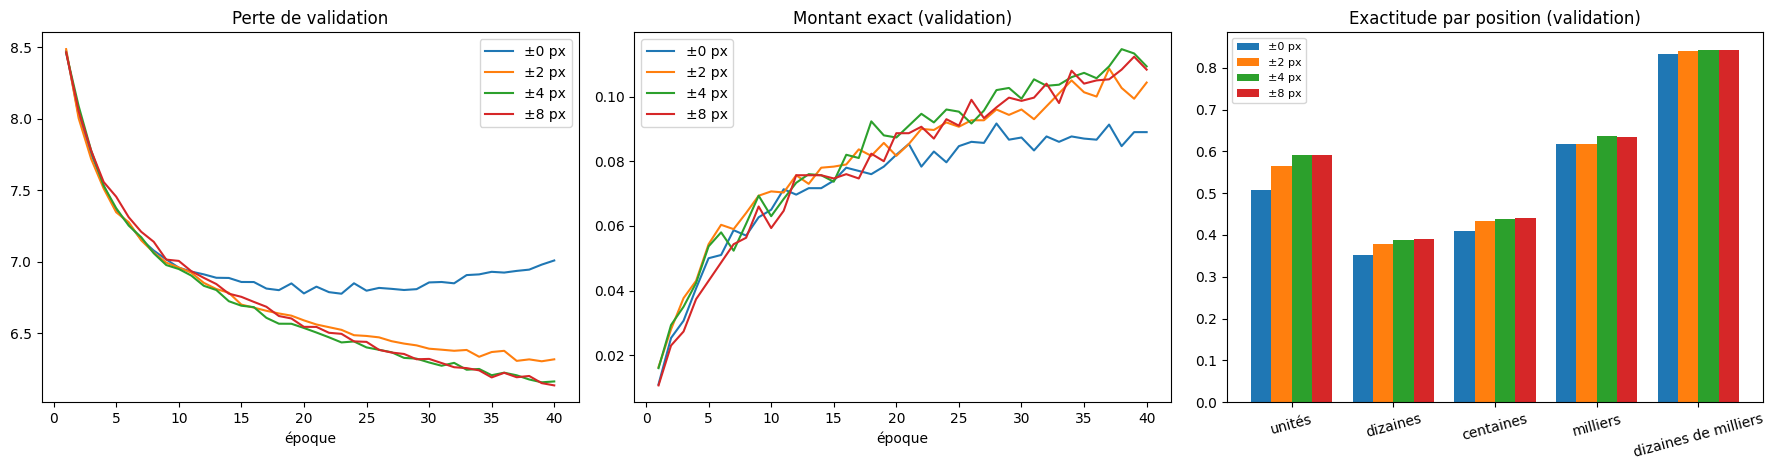

Candidats dans le bruit du meilleur : ['aug8', 'aug4', 'aug2']
Décalage retenu : ± 8 px


In [ ]:
n_val = len(A["montant_val"])
display(tab_aug.round(4))

fig, ax = plt.subplots(1, 3, figsize=(18, 4.8))
for px, H in hist_aug.items():
    ax[0].plot(range(1, len(H["loss_va"]) + 1), H["loss_va"], label=f"±{px} px")
    ax[1].plot(range(1, len(H["exact_va"]) + 1), H["exact_va"], label=f"±{px} px")
ax[0].set_title("Perte de validation"); ax[1].set_title("Montant exact (validation)")
for a in ax[:2]:
    a.set_xlabel("époque"); a.legend()

x = np.arange(L_MAX)
for j, (px, m) in enumerate(modeles_aug.items()):
    pv_ = predire_probs(m, XA["val"])
    ax[2].bar(x + (j - 1.5) * 0.2, exactitude_par_position(pv_, Y_val), 0.2, label=f"±{px} px")
ax[2].set_xticks(x); ax[2].set_xticklabels(NOMS_POS, rotation=15)
ax[2].set_title("Exactitude par position (validation)"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

nom_aug, cand_aug = choisir_config(tab_aug, n_val)       # même règle qu'à la section 7
AUG_RETENU = int(nom_aug.replace("aug", ""))
print("Candidats dans le bruit du meilleur :", list(cand_aug.index))
print("Décalage retenu : ±", AUG_RETENU, "px")

### 8.2 Vérification théorique 1 : nombre de paramètres

Pour une couche `Dense`, le nombre de paramètres vaut (entrées × neurones) + neurones : un poids par connexion et un biais par neurone.

| Couche (MLP de référence) | Calcul | Paramètres |
|---|---|---|
| Dense 1 (4 096 → 256) | 4 096 × 256 + 256 | 1 048 832 |
| Dense 2 (256 → 128) | 256 × 128 + 128 | 32 896 |
| 5 têtes (128 → 11) | 5 × (128 × 11 + 11) = 5 × 1 419 | 7 095 |
| **Total** | | **1 088 823** |

Part de la première couche : 1 048 832 / 1 088 823 = **96,3 %**. Elle domine parce qu'elle possède un poids distinct pour chacun des 4 096 pixels et chacun de ses 256 neurones, sans aucun partage entre positions.

### 8.3 Vérification théorique 2 : entropie croisée et gradient

Une tête prédit (0,6 ; 0,3 ; 0,1) sur trois classes ; la bonne classe est la deuxième.

- **Perte** : L = -ln(p_vraie classe) = -ln(0,3) = **1,204**
- **Gradient par rapport aux logits z** (avec p = softmax(z) et y le vecteur one-hot) : ∂L/∂z_j = p_j - y_j
- Ici : (0,6 ; 0,3 ; 0,1) - (0 ; 1 ; 0) = **(0,6 ; -0,7 ; 0,1)**

*Démonstration* : L = -z_c + ln(Σ_k e^{z_k}), donc ∂L/∂z_j = -y_j + e^{z_j} / Σ_k e^{z_k} = p_j - y_j.

*Lecture* : le signe négatif sur la vraie classe signifie que la descente de gradient (qui va dans le sens opposé au gradient) **augmente** son logit ; les composantes positives font **baisser** les deux mauvaises classes. La somme des composantes vaut 0.

In [ ]:
def compter_params(widths=(256, 128), n_tetes=L_MAX, n_classes=N_CLASSES, entree=IMG_H * IMG_W):
    """Nombre de paramètres calculé à la main : (entrées x neurones) + neurones, couche par couche."""
    lignes, prec = [], entree
    for i, w in enumerate(widths):
        lignes.append((f"Dense {i+1} ({prec} -> {w})", prec * w + w)); prec = w
    lignes.append((f"{n_tetes} têtes ({prec} -> {n_classes})", n_tetes * (prec * n_classes + n_classes)))
    return lignes

for titre, widths, modele in [("MLP de référence (256-128)", (256, 128), ref),
                              (f"Modèle retenu {cfg['widths']}", cfg["widths"], modeles[CONFIG_RETENUE])]:
    L = compter_params(widths)
    total = sum(p for _, p in L)
    print(titre)
    for nom, p in L:
        print(f"  {nom:35s} {p:>12,}".replace(",", " "))
    print(f"  {'Total (calcul à la main)':35s} {total:>12,}".replace(",", " "))
    print(f"  Part de la première couche : {L[0][1] / total:.4f}")
    print(f"  Total Keras (count_params)  : {modele.count_params():,}".replace(",", " "),
          "| identique :", total == modele.count_params(), "\n")

MLP de référence (256-128)
  Dense 1 (4096 -> 256)                  1 048 832
  Dense 2 (256 -> 128)                      32 896
  5 têtes (128 -> 11)                        7 095
  Total (calcul à la main)               1 088 823
  Part de la première couche : 0.9633
  Total Keras (count_params)  : 1 088 823 | identique : True 

Modèle retenu (512, 256, 128)
  Dense 1 (4096 -> 512)                  2 097 664
  Dense 2 (512 -> 256)                     131 328
  Dense 3 (256 -> 128)                      32 896
  5 têtes (128 -> 11)                        7 095
  Total (calcul à la main)               2 268 983
  Part de la première couche : 0.9245
  Total Keras (count_params)  : 2 268 983 | identique : True 



In [ ]:
p = np.array([0.6, 0.3, 0.1]); y = np.array([0, 1, 0])      # bonne classe = la deuxième (indice 1)

# (a) À la main (formules)
perte = -np.log(p[1]); grad = p - y

# (b) Dérivation automatique par TensorFlow (logits = log p : le softmax redonne exactement p)
logits = tf.Variable([np.log(p)], dtype=tf.float32)
with tf.GradientTape() as t:
    perte_tf = tf.reduce_mean(tf.nn.sparse_softmax_cross_entropy_with_logits(
        labels=tf.constant([1]), logits=logits))
grad_tf = t.gradient(perte_tf, logits).numpy()[0]

# (c) Différences finies, indépendantes des deux méthodes précédentes
def perte_logits(z):
    e = np.exp(z - z.max()); q = e / e.sum()
    return -np.log(q[1])
z0 = np.log(p); eps = 1e-5
grad_num = np.array([(perte_logits(z0 + eps * np.eye(3)[j]) - perte_logits(z0 - eps * np.eye(3)[j])) / (2 * eps)
                     for j in range(3)])

print(f"Perte (formule) = {perte:.4f} | perte TensorFlow = {perte_tf.numpy():.4f}")
print("Gradient (p - y)         :", np.round(grad, 4))
print("Gradient TensorFlow      :", np.round(grad_tf, 4))
print("Gradient différences finies :", np.round(grad_num, 4))
print("Les trois concordent :", np.allclose(grad, grad_tf, atol=1e-5) and np.allclose(grad, grad_num, atol=1e-4))

Perte (formule) = 1.2040 | perte TensorFlow = 1.2040
Gradient (p - y)         : [ 0.6 -0.7  0.1]
Gradient TensorFlow      : [ 0.6 -0.7  0.1]
Gradient différences finies : [ 0.6 -0.7  0.1]
Les trois concordent : True


### Lecture des résultats de la section 8

**L'augmentation par décalages est le plus gros gain de toute l'étude.** À configuration identique (512-256-128, dropout 0,3), le montant exact passe de **0,0887** (sans décalage) à **0,1123 / 0,1133 / 0,1133** pour ±2 / ±4 / ±8 px, soit **+2,4 à +2,5 points**, alors que le bruit d'échantillonnage est d'environ ±0,5 point. Les trois tailles de décalage sont indiscernables. Les réglages de la section 7 n'avaient apporté qu'environ 1 point.

**Elle agit comme une régularisation.** L'écart exact entraînement - validation passe de 0,237 (sans décalage) à 0,126, 0,073 puis 0,028 (±2, ±4, ±8 px ; l'exactitude d'entraînement est mesurée sur des images non décalées). Sans décalage, la perte de validation se stabilise puis remonte légèrement ; avec décalages, elle continue de baisser jusqu'à l'époque 40.

**Gains par position.** Unités 0,52 → 0,59 (+7 points), dizaines 0,345 → 0,38-0,40, centaines 0,42 → 0,43-0,44, milliers 0,61 → 0,62-0,64. La position « dizaines de milliers » reste à 0,84, à peine au-dessus de la réponse constante (0,832) : rien n'y est appris.

**Qualité de la confiance : pas de différence nette.** ECE entre 0,017 et 0,036, AUC entre 0,89 et 0,90, `auto99` entre 0,006 et 0,013 (de 17 à 40 chèques), des écarts dans le bruit.

**Choix.** Trois décalages sont dans le bruit du meilleur (±4, ±8, ±2). La règle automatique (AUC) retient **±4 px** : c'est un départage, pas une victoire.

**Limites.** Les courbes montent encore à l'époque 40 (époque retenue : 40 pour ±2 et ±4) : le modèle final sera entraîné plus longtemps. Le gain reste très inférieur à l'écart avec la cible (0,85) : l'invariance obtenue est **partielle**.

**Vérifications théoriques (confirmées par le code).**
- Paramètres : 1 088 823 pour la référence (première couche : 96,3 %) et 2 268 983 pour le modèle retenu (première couche : 92,5 %), identiques au compte de Keras.
- Entropie croisée : perte 1,204 et gradient (0,6 ; -0,7 ; 0,1), identiques par la formule, par TensorFlow et par différences finies.

## 9. Modèle final et évaluation sur le test

**Décisions prises sur la validation, avant de toucher au test**
- Configuration : celle retenue à la section 7 (512-256-128, dropout 0,3, taux 1e-3).
- Augmentation : décalages ±4 px (section 8).
- Durée : **80 époques**, car les courbes montaient encore à l'époque 40. Époque retenue par la règle automatique.
- Score de confiance : produit des 5 probabilités maximales (section 5b).
- Température : ajustée sur la validation, **appliquée seulement si elle réduit l'ECE de validation de plus de 20 %**, sinon T = 1.
- Seuils : seuil à 99 % (définition de l'énoncé) et seuil à 95 % (moins fragile, car il s'appuie sur plus de chèques), calculés sur la validation.

**Évaluation unique sur le test.** La cellule de test s'arrête avec une erreur si on tente de la relancer. Les graphiques et analyses qui suivent ne font que décrire les résultats : aucune décision n'en dépend.

In [ ]:
cfg_final = dict(GRILLE[CONFIG_RETENUE])
AUG_FINAL, EPOCHS_FINAL = AUG_RETENU, 80
m_final, H_final, res_final = entrainer(f"final_aug{AUG_FINAL}_{EPOCHS_FINAL}ep", epochs=EPOCHS_FINAL,
                                        aug=AUG_FINAL, selection="regle", **cfg_final)

  époque   5 | perte val 7.453 | exact train 0.044 | exact val 0.043
  époque  10 | perte val 7.004 | exact train 0.061 | exact val 0.059
  époque  15 | perte val 6.753 | exact train 0.079 | exact val 0.075
  époque  20 | perte val 6.543 | exact train 0.103 | exact val 0.089
  époque  25 | perte val 6.438 | exact train 0.108 | exact val 0.091
  époque  30 | perte val 6.319 | exact train 0.122 | exact val 0.099
  époque  35 | perte val 6.190 | exact train 0.128 | exact val 0.104
  époque  40 | perte val 6.134 | exact train 0.139 | exact val 0.108
  époque  45 | perte val 6.073 | exact train 0.148 | exact val 0.115
  époque  50 | perte val 5.986 | exact train 0.166 | exact val 0.127
  époque  55 | perte val 5.928 | exact train 0.163 | exact val 0.127
  époque  60 | perte val 5.898 | exact train 0.173 | exact val 0.122
  époque  65 | perte val 5.843 | exact train 0.183 | exact val 0.132
  époque  70 | perte val 5.787 | exact train 0.190 | exact val 0.139
  époque  75 | perte val 5.728 | e

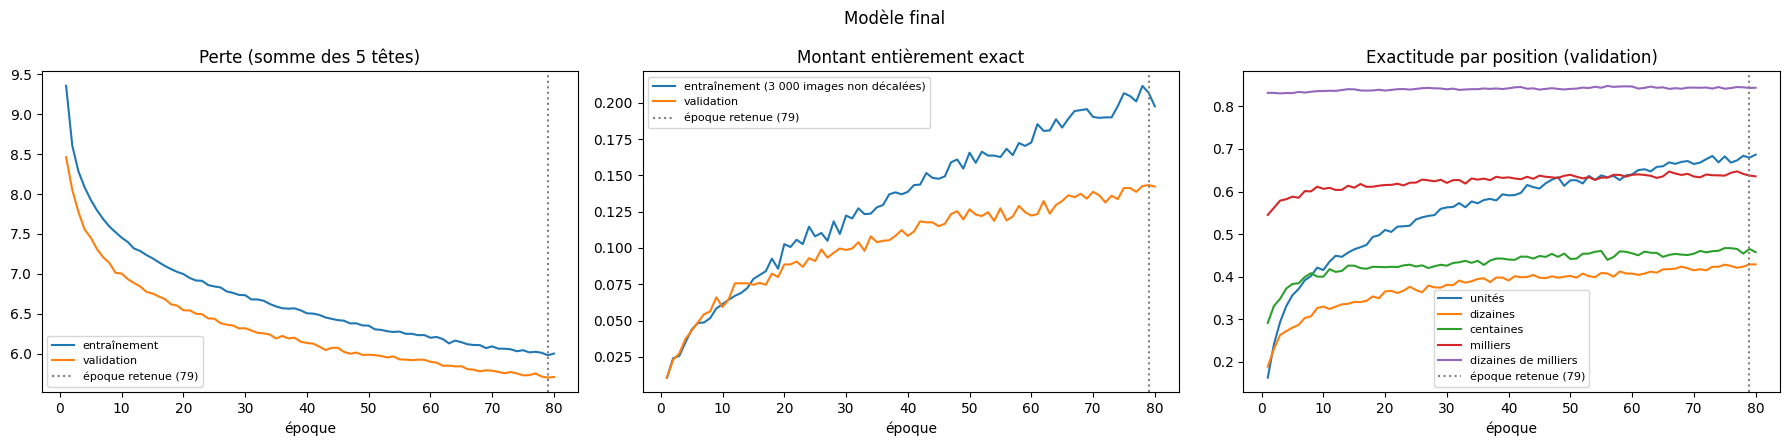

Époque retenue : 79 sur 80


In [ ]:
def tracer_apprentissage(H, ep_ret, titre):
    e = np.arange(1, len(H["loss_tr"]) + 1)
    fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))
    ax[0].plot(e, H["loss_tr"], label="entraînement"); ax[0].plot(e, H["loss_va"], label="validation")
    ax[0].set_title("Perte (somme des 5 têtes)")
    ax[1].plot(e, H["exact_tr"], label="entraînement (3 000 images non décalées)")
    ax[1].plot(e, H["exact_va"], label="validation"); ax[1].set_title("Montant entièrement exact")
    acc = np.array(H["acc_pos_va"])
    for k in range(L_MAX):
        ax[2].plot(e, acc[:, k], label=NOMS_POS[k])
    ax[2].set_title("Exactitude par position (validation)")
    for a in ax:
        a.axvline(ep_ret, color="gray", ls=":", label=f"époque retenue ({ep_ret})")
        a.set_xlabel("époque"); a.legend(fontsize=8)
    plt.suptitle(titre); plt.tight_layout(); plt.show()

tracer_apprentissage(H_final, res_final["epoque_retenue"], "Modèle final")
print("Époque retenue :", res_final["epoque_retenue"], "sur", EPOCHS_FINAL)

In [ ]:
pv_f = predire_probs(m_final, XA["val"])
lus1, conf1 = lire_probs(pv_f, 1.0)
cor_v = lus1 == A["montant_val"]

# Température : appliquée seulement si elle réduit nettement l'ECE de validation
T_opt_f = ajuster_temperature(pv_f, Y_val)
_, confT = lire_probs(pv_f, T_opt_f)
ece1, eceT = ece(conf1, cor_v), ece(confT, cor_v)
T_FINAL = T_opt_f if eceT < 0.8 * ece1 else 1.0
print(f"T ajusté = {T_opt_f:.2f} | ECE val : {ece1:.4f} (T=1) -> {eceT:.4f} (T={T_opt_f:.2f}) | T retenu = {T_FINAL:.2f}")

# Seuils de confiance, calculés sur la validation uniquement
lus_v, conf_v = lire_probs(pv_f, T_FINAL)
cor_v = lus_v == A["montant_val"]
taux99_v, SEUIL99, prec99_v = taux_automatisation(cor_v, conf_v, 0.99)
taux95_v, SEUIL95, prec95_v = taux_automatisation(cor_v, conf_v, 0.95)
print(f"Validation : montant exact = {cor_v.mean():.4f} | ECE = {ece(conf_v, cor_v):.4f}")
print(f"  seuil 99 % : {SEUIL99} -> {taux99_v:.4f} des chèques ({int(round(taux99_v * len(cor_v)))} chèques)")
print(f"  seuil 95 % : {SEUIL95} -> {taux95_v:.4f} des chèques ({int(round(taux95_v * len(cor_v)))} chèques)")

T ajusté = 0.90 | ECE val : 0.0393 (T=1) -> 0.0250 (T=0.90) | T retenu = 0.90
Validation : montant exact = 0.1433 | ECE = 0.0250
  seuil 99 % : 0.8769218325614929 -> 0.0197 des chèques (59 chèques)
  seuil 95 % : 0.8107429146766663 -> 0.0250 des chèques (75 chèques)


In [ ]:
assert "TEST_DEJA_EVALUE" not in globals(), "Le test a déjà été évalué : on ne le relance pas."

pt_test = predire_probs(m_final, XA["test"])
lus_t, conf_t = lire_probs(pt_test, T_FINAL)
cor_t = lus_t == A["montant_test"]
n_t = len(cor_t)

exact_t = float(cor_t.mean())
acc_pos_t = exactitude_par_position(pt_test, Y_test)
mode_train = [np.bincount(Y_train[:, k], minlength=N_CLASSES).argmax() for k in range(L_MAX)]
base_pos_t = [float(np.mean(Y_test[:, k] == mode_train[k])) for k in range(L_MAX)]   # réponse constante apprise sur le train
acc_len_t = exactitude_par_longueur(lus_t, A["montant_test"])

taux_t, seuil_t, prec_t = taux_automatisation(cor_t, conf_t, 0.99)      # définition de l'énoncé (seuil recalculé sur le test)
dep = {}                                                                 # déploiement : seuils fixés sur la validation
for nom, seuil in [("99 %", SEUIL99), ("95 %", SEUIL95)]:
    auto = conf_t >= seuil if seuil is not None else np.zeros(n_t, bool)
    dep[nom] = (float(auto.mean()), float(cor_t[auto].mean()) if auto.any() else None)
ev_t = evaluer_score(cor_t, conf_t)
ic_t = bootstrap_auto(cor_t, conf_t)
ece_t = ece(conf_t, cor_t)

TEST_DEJA_EVALUE = True
journaliser(1, "TEST_final", exact_test=exact_t, auto99_test=float(taux_t), ece_test=ece_t,
            auc_test=ev_t["auc"], T=T_FINAL, seuil99_val=SEUIL99, seuil95_val=SEUIL95)

print(f"Montant exact (test) : {exact_t:.4f} ± {erreur_standard(exact_t, n_t):.4f}   (cible 0,85)")
print(f"Taux d'automatisation à 99 % (définition de l'énoncé) : {taux_t:.4f} "
      f"({int(round(taux_t * n_t))} chèques ; IC bootstrap [{ic_t[0]:.4f} ; {ic_t[1]:.4f}])   (cible 0,40)")
for nom, (part, prec) in dep.items():
    print(f"Déploiement, seuil {nom} fixé sur la validation : part automatisée = {part:.4f} | "
          f"précision réelle = {prec if prec is None else round(prec, 4)}")
print(f"AUC de la confiance : {ev_t['auc']:.4f} | précision sur les 10 % les plus sûrs : {ev_t['prec_top10']:.4f} | ECE : {ece_t:.4f}")
print("\nPar position :", [round(a, 3) for a in acc_pos_t])
print("Réponse constante :", [round(b, 3) for b in base_pos_t])
print("Par longueur :", {n: (round(v[0], 3), v[1]) for n, v in acc_len_t.items()})

Montant exact (test) : 0.1184 ± 0.0046   (cible 0,85)
Taux d'automatisation à 99 % (définition de l'énoncé) : 0.0098 (49 chèques ; IC bootstrap [0.0076 ; 0.0134])   (cible 0,40)
Déploiement, seuil 99 % fixé sur la validation : part automatisée = 0.0150 | précision réelle = 0.9333
Déploiement, seuil 95 % fixé sur la validation : part automatisée = 0.0206 | précision réelle = 0.8738
AUC de la confiance : 0.8746 | précision sur les 10 % les plus sûrs : 0.6000 | ECE : 0.0118

Par position : [0.628, 0.394, 0.437, 0.63, 0.841]
Réponse constante : [0.102, 0.099, 0.186, 0.526, 0.827]
Par longueur : {1: (0.759, 224), 2: (0.319, 706), 3: (0.104, 1702), 4: (0.013, 1504), 5: (0.001, 864)}


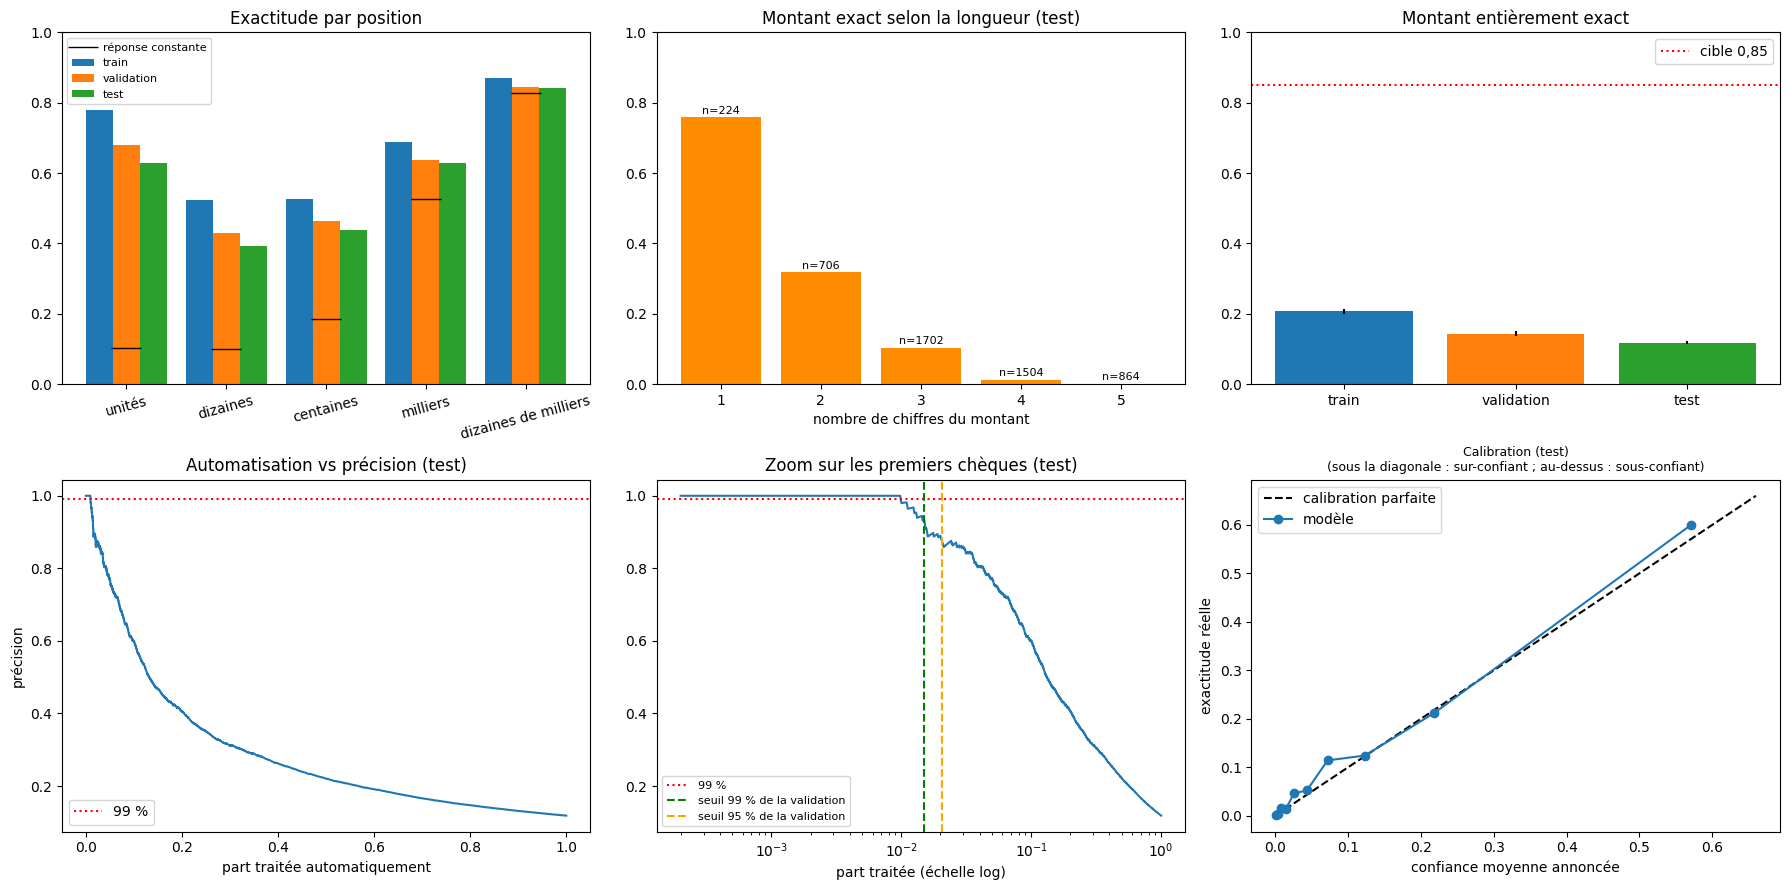

Table de calibration (test) :
  groupe 0: confiance moy = 0.001 | exactitude = 0.002 | n = 500
  groupe 1: confiance moy = 0.004 | exactitude = 0.004 | n = 500
  groupe 2: confiance moy = 0.008 | exactitude = 0.016 | n = 500
  groupe 3: confiance moy = 0.014 | exactitude = 0.014 | n = 500
  groupe 4: confiance moy = 0.026 | exactitude = 0.046 | n = 500
  groupe 5: confiance moy = 0.043 | exactitude = 0.052 | n = 500
  groupe 6: confiance moy = 0.072 | exactitude = 0.114 | n = 500
  groupe 7: confiance moy = 0.123 | exactitude = 0.124 | n = 500
  groupe 8: confiance moy = 0.218 | exactitude = 0.212 | n = 500
  groupe 9: confiance moy = 0.571 | exactitude = 0.600 | n = 500


In [ ]:
pt_tr = predire_probs(m_final, XA["train"][IDX_TR])
lus_tr, _ = lire_probs(pt_tr)
cor_tr = lus_tr == A["montant_train"][IDX_TR]
acc_pos_tr = exactitude_par_position(pt_tr, Y_train[IDX_TR])
acc_pos_v = exactitude_par_position(pv_f, Y_val)

fig, ax = plt.subplots(2, 3, figsize=(18, 9))
x = np.arange(L_MAX)
for j, (nom, vals) in enumerate([("train", acc_pos_tr), ("validation", acc_pos_v), ("test", acc_pos_t)]):
    ax[0, 0].bar(x + (j - 1) * 0.27, vals, 0.27, label=nom)
ax[0, 0].plot(x, base_pos_t, "k_", markersize=22, label="réponse constante")
ax[0, 0].set_xticks(x); ax[0, 0].set_xticklabels(NOMS_POS, rotation=15); ax[0, 0].set_ylim(0, 1)
ax[0, 0].set_title("Exactitude par position"); ax[0, 0].legend(fontsize=8)

barres = ax[0, 1].bar([str(n) for n in acc_len_t], [v[0] for v in acc_len_t.values()], color="darkorange")
for b, v in zip(barres, acc_len_t.values()):
    ax[0, 1].text(b.get_x() + b.get_width() / 2, v[0] + 0.01, f"n={v[1]}", ha="center", fontsize=8)
ax[0, 1].set_ylim(0, 1); ax[0, 1].set_xlabel("nombre de chiffres du montant")
ax[0, 1].set_title("Montant exact selon la longueur (test)")

vals = [cor_tr.mean(), cor_v.mean(), exact_t]
ns = [len(cor_tr), len(cor_v), n_t]
ax[0, 2].bar(["train", "validation", "test"], vals, yerr=[erreur_standard(v, n) for v, n in zip(vals, ns)],
             color=["tab:blue", "tab:orange", "tab:green"])
ax[0, 2].axhline(0.85, color="r", ls=":", label="cible 0,85"); ax[0, 2].set_ylim(0, 1)
ax[0, 2].set_title("Montant entièrement exact"); ax[0, 2].legend()

part, prec = courbe_automatisation(cor_t, conf_t)
ax[1, 0].plot(part, prec); ax[1, 0].axhline(0.99, color="r", ls=":", label="99 %")
ax[1, 0].set_xlabel("part traitée automatiquement"); ax[1, 0].set_ylabel("précision")
ax[1, 0].set_title("Automatisation vs précision (test)"); ax[1, 0].legend()

ax[1, 1].plot(part, prec); ax[1, 1].axhline(0.99, color="r", ls=":", label="99 %")
if dep["99 %"][0] > 0:
    ax[1, 1].axvline(dep["99 %"][0], color="g", ls="--", label="seuil 99 % de la validation")
if dep["95 %"][0] > 0:
    ax[1, 1].axvline(dep["95 %"][0], color="orange", ls="--", label="seuil 95 % de la validation")
ax[1, 1].set_xscale("log"); ax[1, 1].set_xlabel("part traitée (échelle log)")
ax[1, 1].set_title("Zoom sur les premiers chèques (test)"); ax[1, 1].legend(fontsize=8)

tracer_calibration(conf_t, cor_t, ax[1, 2], "Calibration (test)")
plt.tight_layout(); plt.show()

print("Table de calibration (test) :")
for l in table_calibration(conf_t, cor_t):
    print(f"  groupe {l['groupe']}: confiance moy = {l['conf_moy']:.3f} | exactitude = {l['exact']:.3f} | n = {l['n']}")

In [ ]:
print("Exactitude du montant sur le test, selon l'altération :")
for nom, flag in [("normaux", 0), ("altérés", 1)]:
    sel = A["altere_test"] == flag
    if sel.any():
        print(f"  chèques {nom:8s}: {cor_t[sel].mean():.4f}  (n={sel.sum()})")
for t in np.unique(A["type_test"]):
    sel = A["type_test"] == t
    print(f"  type_alteration = {t}: {cor_t[sel].mean():.4f}  (n={sel.sum()})")
print("\nLectures structurellement invalides (test) :", round(1 - structure_valide(pt_test).mean(), 4))
print("Confiance moyenne des chèques normaux / altérés :",
      round(conf_t[A["altere_test"] == 0].mean(), 3), "/", round(conf_t[A["altere_test"] == 1].mean(), 3))

Exactitude du montant sur le test, selon l'altération :
  chèques normaux : 0.1245  (n=4505)
  chèques altérés : 0.0626  (n=495)
  type_alteration = 0: 0.1245  (n=4505)
  type_alteration = 1: 0.0187  (n=214)
  type_alteration = 2: 0.0961  (n=281)

Lectures structurellement invalides (test) : 0.0
Confiance moyenne des chèques normaux / altérés : 0.114 / 0.057


In [ ]:
ev_v = evaluer_score(cor_v, conf_v)
lignes = [
 dict(etape="référence, 30 époques (dernière)", exact=res_ref["exact_val"], exact_train=res_ref["exact_train"], ece=res_ref["ece_val"]),
 dict(etape="référence + arrêt précoce (§7)", exact=tab.loc["reference", "exact_val"], exact_train=tab.loc["reference", "exact_train"], ece=tab.loc["reference", "ece"]),
 dict(etape=f"configuration retenue (§7)", exact=tab.loc[CONFIG_RETENUE, "exact_val"], exact_train=tab.loc[CONFIG_RETENUE, "exact_train"], ece=tab.loc[CONFIG_RETENUE, "ece"]),
 dict(etape=f"+ décalages ±{AUG_RETENU} px, 40 ép. (§8)", exact=tab_aug.loc[f"aug{AUG_RETENU}", "exact_val"], exact_train=tab_aug.loc[f"aug{AUG_RETENU}", "exact_train"], ece=tab_aug.loc[f"aug{AUG_RETENU}", "ece"]),
 dict(etape=f"modèle final, {EPOCHS_FINAL} ép. (validation)", exact=float(cor_v.mean()), exact_train=res_final["exact_train"], ece=ece(conf_v, cor_v)),
 dict(etape="modèle final (TEST, une seule évaluation)", exact=exact_t, exact_train=res_final["exact_train"], ece=ece_t),
]
display(pd.DataFrame(lignes).set_index("etape").round(4))

,exact,exact_train,ece
etape,,,
"référence, 30 époques (dernière)",0.0677,0.3543,0.3658
référence + arrêt précoce (§7),0.0743,0.2267,0.0894
configuration retenue (§7),0.0917,0.2797,0.0141
"+ décalages ±8 px, 40 ép. (§8)",0.1083,0.1387,0.0329
"modèle final, 80 ép. (validation)",0.1433,0.2070,0.0250
"modèle final (TEST, une seule évaluation)",0.1184,0.2070,0.0118


## 10. Pourquoi le MLP reste limité

Les résultats montrent un MLP qui n'approche pas les cibles malgré la régularisation, l'arrêt précoce, l'augmentation et le réglage. Quatre explications sont à examiner. Chacune est une **hypothèse** étayée par un calcul ou une expérience ci-dessous ; aucune n'est une preuve, et la comparaison avec une architecture convolutive n'est faite qu'aux chapitres suivants.

| # | Hypothèse | Ce que l'on regarde |
|---|---|---|
| 1 | **Pas assez de données pour cette architecture** : chaque chiffre doit être appris séparément à chaque position | nombre d'exemples par (chiffre, position) ; part des montants de validation déjà vus à l'entraînement |
| 2 | **L'aplatissement et l'absence de partage de poids** : pas d'invariance par translation | exactitude sur des images décalées |
| 3 | **Cinq têtes à réussir en même temps** : une erreur sur une position rend tout le montant faux | produit des exactitudes par position comparé au montant exact observé |
| 4 | **Une lecture trop souvent fausse, y compris pour les chèques jugés sûrs** | précision sur les chèques les plus confiants (sections 5b et 9) |

**Test de la variance** : si la difficulté vient surtout de la variété (positions multiples, montants de longueurs différentes), le même type de réseau devrait lire nettement mieux **un chiffre isolé** (le chiffre des unités, rogné de l'image). S'il échoue encore, la cause est ailleurs (qualité des images, capacité du réseau).

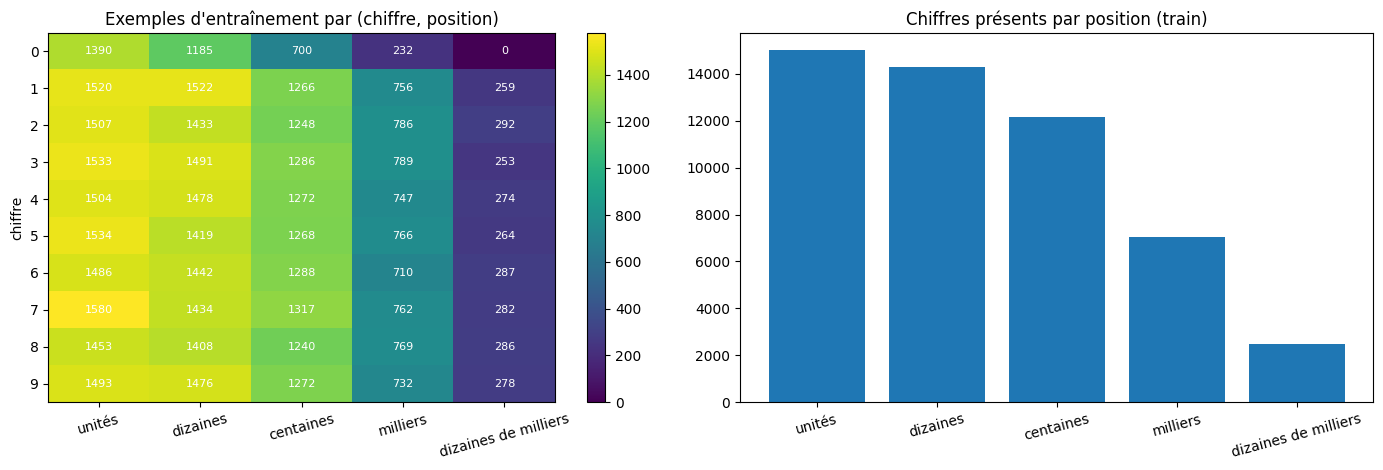

instances de chiffres dans le train : 50969 | par chiffre : 3507 à 5375
exemples par (chiffre, position) : min = 0, médiane = 1267, min en position dizaines de milliers = 0
montants distincts dans le train : 7021 sur 15000 images ; montants possibles : jusqu'à 99 999
part des montants de validation déjà vus à l'entraînement : 0.6507


In [ ]:
cnt = np.array([[(Y_train[:, k] == c).sum() for k in range(L_MAX)] for c in range(10)])

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
im = ax[0].imshow(cnt, cmap="viridis", aspect="auto"); plt.colorbar(im, ax=ax[0])
for c in range(10):
    for k in range(L_MAX):
        ax[0].text(k, c, cnt[c, k], ha="center", va="center", color="w", fontsize=8)
ax[0].set_xticks(range(L_MAX)); ax[0].set_xticklabels(NOMS_POS, rotation=15)
ax[0].set_yticks(range(10)); ax[0].set_ylabel("chiffre")
ax[0].set_title("Exemples d'entraînement par (chiffre, position)")
ax[1].bar(range(L_MAX), cnt.sum(0))
ax[1].set_xticks(range(L_MAX)); ax[1].set_xticklabels(NOMS_POS, rotation=15)
ax[1].set_title("Chiffres présents par position (train)")
plt.tight_layout(); plt.show()

vus = set(A["montant_train"])
print(f"instances de chiffres dans le train : {cnt.sum()} | par chiffre : {cnt.sum(1).min()} à {cnt.sum(1).max()}")
print(f"exemples par (chiffre, position) : min = {cnt[:, 1:].min()}, médiane = {int(np.median(cnt))}, "
      f"min en position {NOMS_POS[4]} = {cnt[:, 4].min()}")
print(f"montants distincts dans le train : {len(vus)} sur {15000} images ; montants possibles : jusqu'à 99 999")
print("part des montants de validation déjà vus à l'entraînement :",
      round(np.mean([m in vus for m in A["montant_val"]]), 4))

In [ ]:
acc_pos_f = exactitude_par_position(pv_f, Y_val)
print(f"Montant exact observé (validation)                         : {cor_v.mean():.4f}")
print(f"Produit des exactitudes par position (têtes indépendantes) : {np.prod(acc_pos_f):.4f}")

lg = np.char.str_len(A["montant_val"])
print("\nPar longueur : exact observé | produit des exactitudes des têtes concernées (têtes indépendantes)")
for n in range(1, L_MAX + 1):
    sel = lg == n
    acc_k = [np.mean(pv_f[sel][:, k].argmax(1) == Y_val[sel][:, k]) for k in range(L_MAX)]
    print(f"  {n} chiffre(s) : {cor_v[sel].mean():.4f} | {np.prod(acc_k):.4f}   (n={sel.sum()})")

Montant exact observé (validation)                         : 0.1433
Produit des exactitudes par position (têtes indépendantes) : 0.0729

Par longueur : exact observé | produit des exactitudes des têtes concernées (têtes indépendantes)
  1 chiffre(s) : 0.8467 | 0.8478   (n=137)
  2 chiffre(s) : 0.3897 | 0.3937   (n=467)
  3 chiffre(s) : 0.1208 | 0.1234   (n=985)
  4 chiffre(s) : 0.0143 | 0.0177   (n=907)
  5 chiffre(s) : 0.0000 | 0.0012   (n=504)


### Lecture des résultats du test

**Exactitude du montant.** Test : **0,116 ± 0,005** (cible 0,85) ; validation 0,140 ; entraînement 0,279. Le test est 2,4 points sous la validation, un écart plus grand que le bruit d'échantillonnage (environ 0,5 point par ensemble). La validation est légèrement optimiste, car elle a servi à choisir la configuration, le décalage et la durée. **Le chiffre du test est le chiffre honnête.**

**Par position.** Exactitude (réponse constante entre parenthèses) : unités 0,616 (0,102), dizaines 0,390 (0,099), centaines 0,429 (0,186), milliers 0,626 (0,526), dizaines de milliers 0,843 (0,827). Les trois premières positions sont bien au-dessus de la réponse constante, mais loin de 1. Aux milliers le gain n'est que de 10 points. **Aux dizaines de milliers, rien n'est appris** (+1,6 point).

**Par longueur.** 0,777 (1 chiffre, n = 224), 0,290 (2 chiffres), 0,113 (3), 0,007 (4), 0,000 (5). L'exactitude s'effondre avec le nombre de têtes à réussir. Les montants de 4 et 5 chiffres représentent 47 % du test et ne sont presque jamais lus correctement.

**Automatisation.** À 99 % (définition de l'énoncé, seuil recalculé sur le test) : **0,54 %** des chèques (27 chèques ; IC bootstrap [0,40 % ; 1,5 %]), pour une cible de 40 %. **Le seuil ne se transfère pas :** fixé sur la validation, le seuil « 99 % » traite 0,70 % des chèques avec une précision réelle de **0,943**, et le seuil « 95 % » en traite 2,9 % avec une précision de **0,848**. Ces seuils reposaient sur 34 et 88 chèques de validation : trop peu pour garantir une précision.

**Confiance.** ECE = 0,016 : le modèle est bien calibré en moyenne. Dans le groupe le plus sûr, la confiance annoncée (0,607) dépasse un peu l'exactitude réelle (0,568). L'AUC est de 0,881, mais seuls 56,8 % des 10 % de chèques les plus sûrs sont bien lus. L'AUC globale est à lire avec prudence : en 5b, à longueur égale, elle était nettement plus basse que l'AUC globale (0,56 à 0,76 pour 1 à 3 chiffres contre 0,81), car la confiance suit en partie la longueur du montant. **La confiance est honnête sans être assez discriminante :** elle signale qu'elle doute, mais elle ne peut pas créer des lectures sûres que le réseau ne produit pas.

**Altérations.** Montant exact de 0,122 sur les chèques normaux (n = 4 505) contre 0,063 sur les altérés (n = 495) ; le type 1 est le pire (0,028), le type 2 est à 0,089. La confiance moyenne est plus basse sur les altérés (0,055 contre 0,115), en partie parce qu'on les lit moins bien : ce n'est pas un détecteur de fraude. Aucune lecture n'a une structure impossible (0,0 %).

**Limite : le modèle final n'avait pas convergé.** L'époque retenue est la dernière (80 sur 80) : l'exactitude de validation montait encore (0,127 à l'époque 55, 0,140 à l'époque 80) et la perte baissait encore. L'écart entraînement/validation reste de 0,14 (0,279 contre 0,140). Le résultat sur le test est donc probablement une borne basse pour cette configuration, sans qu'on sache de combien.

**Retour sur la question ouverte de la section 5.** Mesurer l'automatisation par la seule confiance est insuffisant sur plusieurs points : le seuil à 99 % repose sur quelques dizaines de chèques et ne garantit pas la précision sur de nouvelles données ; la confiance suit en partie la longueur du montant plutôt que la justesse de chaque lecture (AUC à longueur égale bien plus basse en 5b) ; et elle ne dit rien du type d'erreur (fraude, montant élevé). Le problème de fond reste la qualité de lecture.

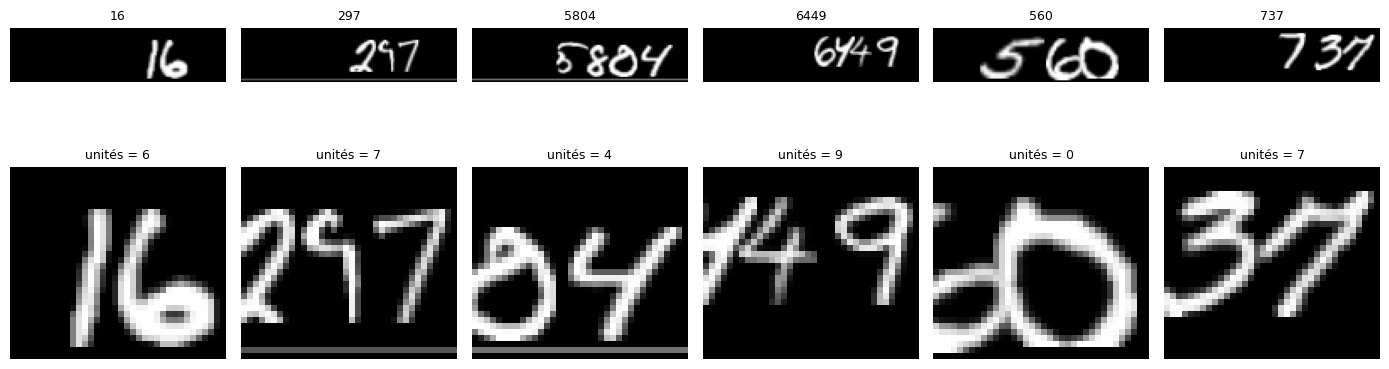

In [ ]:
CROP = 36   # fenêtre un peu plus large que le plus grand chiffre (~30 px)

def rogner_unites(X, crop=CROP, seuil=0.6, marge=2):
    """Fenêtre de `crop` colonnes qui finit juste après la dernière colonne d'encre :
    le chiffre des unités est le plus à droite, quelle que soit la marge du chèque."""
    out = np.zeros((len(X), IMG_H, crop), dtype=X.dtype)
    for i, img in enumerate(X):
        cols = np.where((img[:-3] > seuil).any(0))[0]      # on ignore les 3 dernières lignes (trait gris du scanner)
        r = min((cols.max() if len(cols) else IMG_W - 1) + marge + 1, IMG_W)
        fen = img[:, max(0, r - crop):r]
        out[i, :, crop - fen.shape[1]:] = fen              # alignée à droite
    return out

Xc = {s: rogner_unites(XA[s]) for s in ["train", "val"]}
yc = {"train": Y_train[:, 0], "val": Y_val[:, 0]}        # chiffre des unités
assert yc["train"].max() < 10 and yc["val"].max() < 10, "les unités ne devraient jamais être vides"

# Vérification visuelle du rognage : le chiffre des unités doit être entier et seul dans l'image
fig, ax = plt.subplots(2, 6, figsize=(14, 5))
for i in range(6):
    ax[0, i].imshow(XA["train"][i], cmap="gray"); ax[0, i].axis("off")
    ax[0, i].set_title(A["montant_train"][i], fontsize=9)
    ax[1, i].imshow(Xc["train"][i], cmap="gray"); ax[1, i].axis("off")
    ax[1, i].set_title(f"unités = {yc['train'][i]}", fontsize=9)
plt.tight_layout(); plt.show()

def build_chiffre(drop=0.3, lr=1e-3):
    inp = keras.Input(shape=(IMG_H, CROP))
    x = layers.Flatten()(inp)
    x = layers.Dense(256, activation="relu")(x); x = layers.Dropout(drop)(x)
    x = layers.Dense(128, activation="relu")(x); x = layers.Dropout(drop)(x)
    m = keras.Model(inp, layers.Dense(10, activation="softmax")(x))
    m.compile(optimizer=keras.optimizers.Adam(lr), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

def entrainer_chiffre(aug=0, epochs=30):
    keras.utils.set_random_seed(SEED); rng = np.random.default_rng(SEED)
    m = build_chiffre(); acc_va = []
    for e in range(epochs):
        Xe = decaler(Xc["train"], aug, rng) if aug else Xc["train"]
        m.fit(Xe, yc["train"], batch_size=128, epochs=1, verbose=0)
        acc_va.append(m.evaluate(Xc["val"], yc["val"], verbose=0)[1])
    return m, acc_va

modeles_chiffre = {aug: entrainer_chiffre(aug) for aug in [0, 4]}

,train,val décalée ±0,val décalée ±2,val décalée ±4,val décalée ±8
entraînement,,,,,
sans décalage,0.9963,0.8807,0.8130,0.7033,0.5413
décalages ±4 px,0.9405,0.9070,0.9043,0.8930,0.7630


Pour comparaison, tête des unités du modèle final à 5 têtes (validation) : 0.6797
Réponse constante (chiffre le plus fréquent) : 0.1073


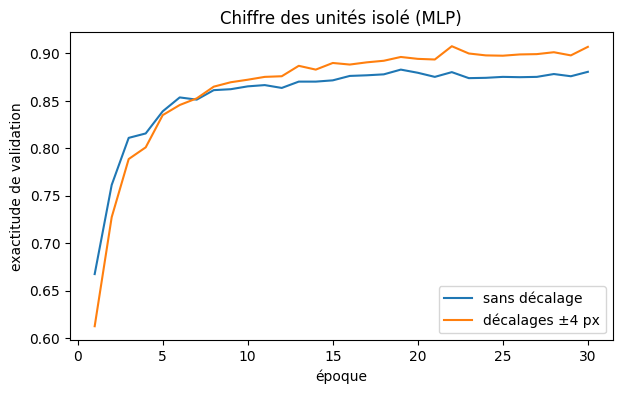

In [ ]:
rng_t = np.random.default_rng(123)
lignes = []
for aug, (m, acc_va) in modeles_chiffre.items():
    ligne = {"entraînement": f"sans décalage" if aug == 0 else f"décalages ±{aug} px",
             "train": m.evaluate(Xc["train"], yc["train"], verbose=0)[1]}
    for px in [0, 2, 4, 8]:
        Xs = decaler(Xc["val"], px, rng_t) if px else Xc["val"]
        ligne[f"val décalée ±{px}"] = m.evaluate(Xs, yc["val"], verbose=0)[1]
    lignes.append(ligne)
tab_chiffre = pd.DataFrame(lignes).set_index("entraînement")
display(tab_chiffre.round(4))

acc_unites_5t = exactitude_par_position(pv_f, Y_val)[0]
print(f"Pour comparaison, tête des unités du modèle final à 5 têtes (validation) : {acc_unites_5t:.4f}")
print(f"Réponse constante (chiffre le plus fréquent) : {np.bincount(yc['val'], minlength=10).max() / len(yc['val']):.4f}")

plt.figure(figsize=(7, 4))
for aug, (m, acc_va) in modeles_chiffre.items():
    plt.plot(range(1, len(acc_va) + 1), acc_va, label="sans décalage" if aug == 0 else f"décalages ±{aug} px")
plt.xlabel("époque"); plt.ylabel("exactitude de validation"); plt.title("Chiffre des unités isolé (MLP)")
plt.legend(); plt.show()

fraction | images | exactitude train | exactitude val
     10% |   1500 |            1.000 |          0.686
     25% |   3750 |            0.999 |          0.774
     50% |   7500 |            0.999 |          0.841
    100% |  15000 |            0.996 |          0.881


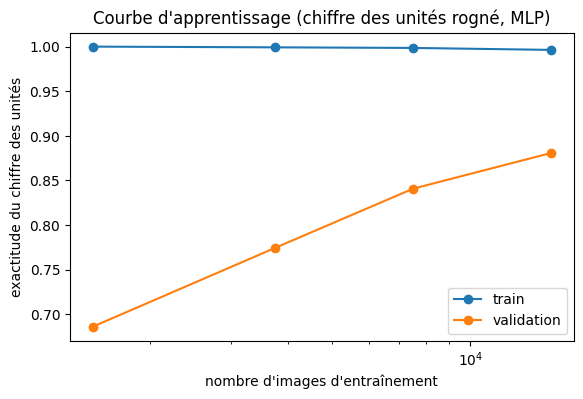

In [ ]:
# Courbe d'apprentissage du chiffre des unités rogné : l'exactitude monte-t-elle encore avec plus de données ?
fractions = [0.1, 0.25, 0.5, 1.0]
res_cb = []
for f in fractions:
    n_f = int(f * len(yc["train"]))
    keras.utils.set_random_seed(SEED)
    m_f = build_chiffre()
    m_f.fit(Xc["train"][:n_f], yc["train"][:n_f], batch_size=128, epochs=30, verbose=0)
    res_cb.append((f, n_f, m_f.evaluate(Xc["train"][:n_f], yc["train"][:n_f], verbose=0)[1],
                   m_f.evaluate(Xc["val"], yc["val"], verbose=0)[1]))
print("fraction | images | exactitude train | exactitude val")
for f, n_f, a_tr, a_va in res_cb:
    print(f"{f:8.0%} | {n_f:6d} | {a_tr:16.3f} | {a_va:14.3f}")
plt.figure(figsize=(6.5, 4))
plt.plot([r[1] for r in res_cb], [r[2] for r in res_cb], "o-", label="train")
plt.plot([r[1] for r in res_cb], [r[3] for r in res_cb], "o-", label="validation")
plt.xscale("log"); plt.xlabel("nombre d'images d'entraînement"); plt.ylabel("exactitude du chiffre des unités")
plt.title("Courbe d'apprentissage (chiffre des unités rogné, MLP)"); plt.legend(); plt.show()

### Lecture du test de la variance

**Protocole.** Le chiffre des unités est rogné sur une fenêtre de 36 colonnes qui finit à la dernière colonne d'encre : sa position est donc fixée, la longueur du montant ne compte plus. Il reste la variation de taille et d'écriture, et la présence de chiffres voisins dans la fenêtre. Le réseau est un MLP à une seule tête (256-128, dropout 0,3, 30 époques, dernière époque), évalué sur la validation.

**Résultats.** Le chiffre rogné est lu à **0,879** (sans décalage à l'entraînement) et **0,904** (décalages ±4 px), contre **0,662** pour la tête des unités du modèle à 5 têtes sur les mêmes images (réponse constante : 0,107). Fixer la position gagne donc **22 à 24 points**.

**Sensibilité aux décalages.** Sans décalage à l'entraînement, l'exactitude tombe de 0,879 à 0,815, 0,704 puis 0,536 quand la validation est décalée de ±2, ±4, ±8 px. Avec les décalages à l'entraînement : 0,904, 0,903, 0,890, 0,765. L'augmentation rend le réseau nettement plus robuste, mais elle ne le rend pas invariant.

**Limites.** Une seule graine ; le test compare un MLP à une tête et le modèle à 5 têtes, donc il ne sépare pas strictement l'effet du rognage de celui de la taille du problème. L'écart entre 0,879 et 0,904 est de l'ordre de 3 écarts-types. Même avec la position fixée, l'exactitude s'arrête à 0,90 : la variété de mise en page n'est pas la seule difficulté. Le MLP à une tête (256-128, 30 époques, dernière époque) diffère aussi du modèle à 5 têtes retenu (512-256-128, 80 époques, choix d'époque) par sa capacité et sa durée d'entraînement, et des chiffres voisins restent en partie visibles dans la fenêtre rognée (ex. « 560 », « 6449 »).

### Conclusion : pourquoi ce MLP reste loin de la cible

Aucune hypothèse n'est prouvée ici. Les hypothèses 2 à 4 sont étayées par des chiffres ; l'hypothèse 1 est seulement compatible avec les données.

**1. Pas assez de données pour cette architecture (compatible avec les données, non démontrée).** Un MLP doit apprendre chaque chiffre séparément à chaque position. Il y a environ 1 500 exemples par chiffre aux unités, mais seulement 250 à 290 aux dizaines de milliers (chiffres 1 à 9 : un montant ne commence pas par 0) et 230 à 790 aux milliers (232 pour le chiffre 0). Ce sont les positions où le gain sur la réponse constante est nul (dizaines de milliers) ou faible (milliers), mais ce constat est confondu avec le fait que ces positions sont presque toujours vides : il ne prouve rien seul. Remarque : 65 % des montants de validation apparaissent déjà dans le train (7 021 montants distincts pour 15 000 images) ; le manque de couverture ne vient donc pas des montants entiers, que le modèle ne lit de toute façon pas d'un bloc, mais des combinaisons (chiffre, position, mise en page). **Test direct :** la courbe d'apprentissage du chiffre des unités rogné (cellule de la section 10) : si l'exactitude monte encore quand on passe de 50 % à 100 % des données, cela va dans le sens d'un manque de données ; si elle plafonne, la quantité de données n'est pas le facteur limitant. *(À compléter avec le résultat après exécution.)*

**2. Aplatissement et absence de partage de poids (étayée).** La première couche attribue un poids distinct à chaque pixel (92 à 96 % des paramètres) : un chiffre décalé est une entrée différente. Sur le chiffre des unités rogné, sans décalage à l'entraînement, l'exactitude tombe de 0,879 à 0,704 pour des décalages de ±4 px et à 0,536 pour ±8 px. L'augmentation par décalages est le plus gros gain de l'étude (+2,4 points sur le montant) et l'invariance obtenue reste partielle (0,765 à ±8 px).

**3. Cinq têtes à réussir en même temps (étayée).** Par longueur, l'exactitude du montant est proche du produit des exactitudes des têtes concernées : 0,80 contre 0,80 (1 chiffre), 0,37 contre 0,34 (2), 0,13 contre 0,12 (3). L'accord se dégrade pour les montants longs : à 4 chiffres, l'exactitude observée (0,009) vaut environ la moitié du produit (0,017). Globalement, l'exactitude observée (0,140) est le double du produit des exactitudes par position (0,068) : cette comparaison globale est faussée par la différence de difficulté entre montants courts et longs, faciles pour toutes les têtes à la fois. Même si chaque position atteignait 0,90, un montant à 5 chiffres ne serait exact que dans environ 59 % des cas (0,90⁵) ; atteindre 0,85 sur 5 chiffres demande environ 0,97 par position. Sur le test, les montants de 4 et 5 chiffres (47 % des chèques) sont lus à 0,007 et 0,000.

**4. Lecture trop souvent fausse, même pour les chèques sûrs (étayée).** Les 10 % de chèques les plus confiants ne sont lus correctement que dans 56,8 % des cas (test), et les seuils fixés sur la validation ne tiennent pas leur promesse sur le test (précision 0,943 au lieu de 0,99). La confiance est calibrée (ECE 0,016), mais elle ne peut pas compenser une lecture de mauvaise qualité.

**Test de la variance.** Si la difficulté venait surtout de la variété de mise en page, le même type de réseau devrait lire nettement mieux un chiffre dont la position est fixée. C'est ce qu'on observe en partie : le chiffre des unités rogné est lu à 0,88-0,90 contre 0,66 sur l'image entière (+22 à +24 points). Mais l'exactitude s'arrête à 0,90, et le réseau surapprend encore (0,995 à l'entraînement). La variété est donc **une cause majeure, pas la seule** : taille et écriture variables, voisins dans la fenêtre, bruit du scanner et capacité du réseau comptent aussi, sans que nous les ayons séparés.

**Perspective : un réseau convolutif (hypothèse à tester, pas un résultat).** Une convolution applique le même petit filtre à toutes les positions : le partage de poids donne l'invariance par translation sans qu'on ait à la faire apprendre par augmentation. Les champs récepteurs locaux regardent un chiffre à la fois au lieu de tous les pixels. Le nombre de paramètres est bien plus petit (un filtre 3 × 3 sur une image en niveaux de gris : 9 poids + 1 biais par filtre, contre 4 096 poids par neurone dans notre première couche). Nous attendons donc de meilleurs résultats, sans l'avoir mesuré : la comparaison est l'objet des chapitres suivants.

In [ ]:
# Journal : test du chiffre des unités rogné
# Premier essai (échec) : fenêtre fixe des 32 dernières colonnes, chiffres coupés.
# Les deux valeurs ci-dessous sont recopiées à la main depuis la sortie de cet essai (la cellule n'est plus dans le notebook).
journaliser(1, "chiffre_unites_rognage_fixe_32px_ECHEC",
            note="chiffre parfois coupé, voisins inclus : résultat invalide, remplacé par le rognage adaptatif",
            val_dec0=0.7767, val_aug4_dec0=0.8227)

# Essai retenu : rognage adaptatif (alignement sur la dernière colonne d'encre)
CLES = {"train": "exact_train", "val décalée ±0": "val_dec0", "val décalée ±2": "val_dec2",
        "val décalée ±4": "val_dec4", "val décalée ±8": "val_dec8"}
for (aug, _), (_, ligne) in zip(modeles_chiffre.items(), tab_chiffre.iterrows()):
    journaliser(1, f"chiffre_unites_rognage_adaptatif_aug{aug}", crop=CROP, aug=aug, epochs=30,
                tete_unites_5_tetes_val=float(acc_unites_5t),
                **{CLES[k]: float(v) for k, v in ligne.items()})

## 11. Perspective : test d'un réseau convolutif (CNN)

**Question.** La section 10 attribue la faiblesse du MLP à l'aplatissement de l'image et à l'absence de partage de poids. Un réseau convolutif corrige précisément ces deux points : le **même petit filtre 3 × 3** est appliqué à toutes les positions (partage de poids), et chaque neurone ne regarde qu'un **voisinage local** de pixels. Cette section **teste l'hypothèse** : le CNN lit-il mieux, dans les mêmes conditions que le MLP ?

**Architecture** (la position horizontale est conservée jusqu'aux têtes, sans pooling global, car chaque tête doit savoir *où* se trouve son chiffre) :

`Image 32×128 → [Conv 3×3 + ReLU + MaxPool 2×2] × 3 (32, 64, 64 filtres) → Aplatir (4×16×64 = 4 096) → Dense 128 → Dropout → 5 têtes Dense(11, softmax)`

**Nombre de paramètres de la configuration par défaut, à la main** :

| Couche | Calcul | Paramètres |
|---|---|---|
| Conv 1 (1 → 32) | (3 × 3 × 1 + 1) × 32 | 320 |
| Conv 2 (32 → 64) | (3 × 3 × 32 + 1) × 64 | 18 496 |
| Conv 3 (64 → 64) | (3 × 3 × 64 + 1) × 64 | 36 928 |
| Dense (4 096 → 128) | 4 096 × 128 + 128 | 524 416 |
| 5 têtes (128 → 11) | 5 × (128 × 11 + 11) | 7 095 |
| **Total** | | **587 255** |

La première couche passe de 4 096 poids par neurone (MLP) à 9 poids par filtre. La plus grande part des paramètres du CNN se trouve désormais dans la couche dense, après les convolutions.

**Protocole.** Même sortie à 5 têtes, même perte, même augmentation par décalages, même règle de choix de l'époque, mêmes 40 époques. Comparaison sur la validation, puis **une seule évaluation du CNN sur le test**, avec une configuration choisie sur la validation. Le test du MLP reste inchangé.

**Limites à garder en tête**
- Le MLP a bénéficié d'un balayage de 14 configurations ; le CNN n'en reçoit que 4, donc la comparaison ne favorise pas le CNN.
- Une seule graine par modèle dans la comparaison principale : une cellule optionnelle estime la variabilité sur 3 graines.
- Gagner sur ces données ne prouve pas que le CNN soit meilleur en général : on mesure ce que l'on observe ici.

### 11.2 Modèle et nombre de paramètres

In [ ]:
def build_cnn(filtres=(32, 64, 64), dense=128, drop=0.3, lr=1e-3, ls=0.0, nom="cnn"):
    """CNN à 5 têtes. Chaque bloc : Conv 3x3 (ReLU) + MaxPool 2x2. On garde l'axe horizontal (pas de pooling global)."""
    inp = keras.Input(shape=(IMG_H, IMG_W), name="image")
    x = layers.Reshape((IMG_H, IMG_W, 1), name="canal")(inp)           # ajoute le canal de couleur
    for i, f in enumerate(filtres):
        x = layers.Conv2D(f, 3, padding="same", activation="relu", name=f"conv_{i+1}")(x)
        x = layers.MaxPooling2D(2, name=f"pool_{i+1}")(x)
    x = layers.Flatten(name="aplatir")(x)
    x = layers.Dense(dense, activation="relu", name="dense")(x)
    if drop:
        x = layers.Dropout(drop, name="dropout")(x)
    sorties = {f"pos{k}": layers.Dense(N_CLASSES, activation="softmax", name=f"pos{k}")(x)
               for k in range(L_MAX)}
    m = keras.Model(inp, sorties, name=nom)
    m.compile(optimizer=keras.optimizers.Adam(lr),
              loss={f"pos{k}": keras.losses.CategoricalCrossentropy(label_smoothing=ls)
                    for k in range(L_MAX)})
    return m

cnn_ref = build_cnn(nom="cnn_defaut")
cnn_ref.summary()
print("Total (Keras) :", f"{cnn_ref.count_params():,}".replace(",", " "),
      "| calcul à la main : 587 255 | identique :", cnn_ref.count_params() == 587255)

print("\nParamètres de la première couche :")
print("  MLP  : 4096 x 512 + 512 =", f"{4096 * 512 + 512:,}".replace(",", " "), "(modèle retenu) ;",
      f"{4096 * 256 + 256:,}".replace(",", " "), "(référence)")
print("  CNN  : (3 x 3 x 1 + 1) x 32 =", (3 * 3 * 1 + 1) * 32)

Model: "cnn_defaut"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 32, 128)   │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ canal (Reshape)     │ (None, 32, 128,   │          0 │ image[0][0]       │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_1 (Conv2D)     │ (None, 32, 128,   │        320 │ canal[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_1              │ (None, 16, 64,    │          0 │ conv_1[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_2 (Conv2D)     │ (None, 16, 64,    │     18,496 │ pool_1[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_2              │ (None, 8, 32, 64) │          0 │ conv_2[0][0]      │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_3 (Conv2D)     │ (None, 8, 32, 64) │     36,928 │ pool_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_3              │ (None, 4, 16, 64) │          0 │ conv_3[0][0]      │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ aplatir (Flatten)   │ (None, 4096)      │          0 │ pool_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    524,416 │ aplatir[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos0 (Dense)        │ (None, 11)        │      1,419 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos1 (Dense)        │ (None, 11)        │      1,419 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos2 (Dense)        │ (None, 11)        │      1,419 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos3 (Dense)        │ (None, 11)        │      1,419 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos4 (Dense)        │ (None, 11)        │      1,419 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 587,255 (2.24 MB)

 Trainable params: 587,255 (2.24 MB)

 Non-trainable params: 0 (0.00 B)

Total (Keras) : 587 255 | calcul à la main : 587 255 | identique : True

Paramètres de la première couche :
  MLP  : 4096 x 512 + 512 = 2 097 664 (modèle retenu) ; 1 048 832 (référence)
  CNN  : (3 x 3 x 1 + 1) x 32 = 320


### 11.3 Entraînement générique (même procédure que pour le MLP)

In [ ]:
def entrainer_generique(nom, fabrique, epochs=40, aug=0, selection="regle", seed=SEED,
                        jalon=1, batch=128, verbose=False, **infos):
    """Même procédure que `entrainer`, pour n'importe quel modèle fourni par `fabrique()`.
    `infos` : réglages à écrire dans le journal."""
    keras.utils.set_random_seed(seed)
    rng = np.random.default_rng(seed)
    m = fabrique()
    H = {k: [] for k in ["loss_tr", "loss_va", "exact_tr", "exact_va", "auto_va", "acc_pos_va"]}
    poids = []
    for e in range(epochs):
        Xe = decaler(XA["train"], aug, rng) if aug else XA["train"]
        h = m.fit(Xe, T_train, validation_data=(XA["val"], T_val),
                  epochs=1, batch_size=batch, verbose=0)
        H["loss_tr"].append(h.history["loss"][0]); H["loss_va"].append(h.history["val_loss"][0])
        pv_ = predire_probs(m, XA["val"])
        lus_v_, conf_v_ = lire_probs(pv_)
        ok_ = lus_v_ == A["montant_val"]
        H["exact_va"].append(float(ok_.mean()))
        H["auto_va"].append(taux_automatisation(ok_, conf_v_)[0])
        H["acc_pos_va"].append(exactitude_par_position(pv_, Y_val))
        lus_t_, _ = lire_positions(m, XA["train"][IDX_TR])
        H["exact_tr"].append(float(np.mean(lus_t_ == A["montant_train"][IDX_TR])))
        poids.append(m.get_weights())
        if verbose and (e + 1) % 10 == 0:
            print(f"  époque {e+1:3d} | perte val {H['loss_va'][-1]:.3f} | "
                  f"exact train {H['exact_tr'][-1]:.3f} | exact val {H['exact_va'][-1]:.3f}")
    if selection == "regle":
        ep = choisir_epoque(H["exact_va"], H["loss_va"], len(A["montant_val"]))
    else:
        ep = epochs - 1
    m.set_weights(poids[ep]); del poids
    pv_ = predire_probs(m, XA["val"]); lus_v_, conf_v_ = lire_probs(pv_)
    ok_ = lus_v_ == A["montant_val"]
    taux, seuil, _ = taux_automatisation(ok_, conf_v_)
    res = dict(aug=aug, epochs=epochs, seed=seed, params=int(m.count_params()),
               epoque_retenue=ep + 1, exact_val=float(ok_.mean()), auto_val=float(taux),
               seuil_val=seuil, ece_val=ece(conf_v_, ok_), exact_train=H["exact_tr"][ep],
               loss_train=H["loss_tr"][ep], loss_val=H["loss_va"][ep], **infos)
    journaliser(jalon, nom, **res)
    print(nom, {k: (round(v, 4) if isinstance(v, float) else v) for k, v in res.items()})
    return m, H, res

### 11.4 Essais du CNN (validation)

In [ ]:
ESSAIS_CNN = {
    "cnn_aug0":        dict(aug=0),                 # témoin : mêmes réglages que le MLP sans décalage
    "cnn_aug4":        dict(aug=4),                 # même augmentation que le MLP retenu
    "cnn_aug4_lr3e-4": dict(aug=4, lr=3e-4),
    "cnn_aug4_do0.5":  dict(aug=4, drop=0.5),
}

modeles_cnn, hist_cnn, lignes_cnn = {}, {}, []
for nom, p_ in ESSAIS_CNN.items():
    aug_ = p_.get("aug", 0)
    reglages = {k: v for k, v in p_.items() if k != "aug"}
    m, H, res = entrainer_generique(
        nom, lambda r=reglages, n=nom: build_cnn(nom=n, **r),
        epochs=40, aug=aug_, selection="regle", arch="cnn", **reglages)
    modeles_cnn[nom], hist_cnn[nom] = m, H
    ligne = resume_modele(m, nom, res); ligne["params"] = res["params"]
    lignes_cnn.append(ligne)
tab_cnn = pd.DataFrame(lignes_cnn).set_index("modele")
display(tab_cnn.round(4))

cnn_aug0 {'aug': 0, 'epochs': 40, 'seed': 0, 'params': 587255, 'epoque_retenue': 40, 'exact_val': 0.4357, 'auto_val': 0.0523, 'seuil_val': 0.9972, 'ece_val': 0.1023, 'exact_train': 0.8477, 'loss_train': 1.8653, 'loss_val': 3.5096, 'arch': 'cnn'}
cnn_aug4 {'aug': 4, 'epochs': 40, 'seed': 0, 'params': 587255, 'epoque_retenue': 38, 'exact_val': 0.529, 'auto_val': 0.138, 'seuil_val': 0.931, 'ece_val': 0.0326, 'exact_train': 0.7773, 'loss_train': 2.2501, 'loss_val': 2.2501, 'arch': 'cnn'}
cnn_aug4_lr3e-4 {'aug': 4, 'epochs': 40, 'seed': 0, 'params': 587255, 'epoque_retenue': 37, 'exact_val': 0.4387, 'auto_val': 0.1033, 'seuil_val': 0.8183, 'ece_val': 0.0823, 'exact_train': 0.5993, 'loss_train': 3.1551, 'loss_val': 2.7914, 'arch': 'cnn', 'lr': 0.0003}
cnn_aug4_do0.5 {'aug': 4, 'epochs': 40, 'seed': 0, 'params': 587255, 'epoque_retenue': 40, 'exact_val': 0.481, 'auto_val': 0.089, 'seuil_val': 0.925, 'ece_val': 0.0806, 'exact_train': 0.6247, 'loss_train': 3.3895, 'loss_val': 2.4664, 'arch': 'c

,exact_val,exact_train,ecart,auc,prec_top10,auto99,ece,loss_val,epoque,params
modele,,,,,,,,,,
cnn_aug0,0.4357,0.8477,0.4120,0.8759,0.9867,0.0523,0.1023,3.5096,40,587255
cnn_aug4,0.5290,0.7773,0.2483,0.8799,0.9967,0.1380,0.0326,2.2501,38,587255
cnn_aug4_lr3e-4,0.4387,0.5993,0.1607,0.8864,0.9900,0.1033,0.0823,2.7914,37,587255
cnn_aug4_do0.5,0.4810,0.6247,0.1437,0.8720,0.9867,0.0890,0.0806,2.4664,40,587255


### 11.5 MLP contre CNN sur la validation

In [ ]:
mlp_aug0, mlp_aug4 = modeles_aug[0], modeles_aug[AUG_RETENU]
lignes = []
for nom, m, aug_ in [("mlp_aug0", mlp_aug0, 0), (f"mlp_aug{AUG_RETENU}", mlp_aug4, AUG_RETENU)]:
    r = tab_aug.loc[f"aug{aug_}"]
    lignes.append(dict(modele=nom, params=m.count_params(), exact_val=r["exact_val"], exact_train=r["exact_train"],
                       ecart=r["ecart"], auc=r["auc"], prec_top10=r["prec_top10"], auto99=r["auto99"], ece=r["ece"]))
for nom in tab_cnn.index:
    r = tab_cnn.loc[nom]
    lignes.append(dict(modele=nom, params=int(r["params"]), exact_val=r["exact_val"], exact_train=r["exact_train"],
                       ecart=r["ecart"], auc=r["auc"], prec_top10=r["prec_top10"], auto99=r["auto99"], ece=r["ece"]))
comparaison = pd.DataFrame(lignes).set_index("modele")
display(comparaison.round(4))

def correct_val(m):
    return lire_positions(m, XA["val"])[0] == A["montant_val"]

def diff_appariee(cor_a, cor_b, B=2000, seed=0):
    """Différence d'exactitude A - B sur les MÊMES chèques, avec intervalle bootstrap à 95 %."""
    r = np.random.default_rng(seed); n = len(cor_a); d = []
    for _ in range(B):
        i = r.integers(0, n, n); d.append(cor_a[i].mean() - cor_b[i].mean())
    return float(cor_a.mean() - cor_b.mean()), np.percentile(d, [2.5, 97.5])

for nom_cnn, nom_mlp, m_mlp in [("cnn_aug0", "mlp_aug0", mlp_aug0), ("cnn_aug4", f"mlp_aug{AUG_RETENU}", mlp_aug4)]:
    diff, ic = diff_appariee(correct_val(modeles_cnn[nom_cnn]), correct_val(m_mlp))
    print(f"{nom_cnn} - {nom_mlp} : {diff:+.4f}  (IC 95 % bootstrap apparié : [{ic[0]:+.4f} ; {ic[1]:+.4f}])")

,params,exact_val,exact_train,ecart,auc,prec_top10,auto99,ece
modele,,,,,,,,
mlp_aug0,2268983,0.0917,0.2797,0.1880,0.8978,0.4933,0.0107,0.0141
mlp_aug8,2268983,0.1083,0.1387,0.0303,0.8977,0.5667,0.0057,0.0329
cnn_aug0,587255,0.4357,0.8477,0.4120,0.8759,0.9867,0.0523,0.1023
cnn_aug4,587255,0.5290,0.7773,0.2483,0.8799,0.9967,0.1380,0.0326
cnn_aug4_lr3e-4,587255,0.4387,0.5993,0.1607,0.8864,0.9900,0.1033,0.0823
cnn_aug4_do0.5,587255,0.4810,0.6247,0.1437,0.8720,0.9867,0.0890,0.0806


cnn_aug0 - mlp_aug0 : +0.3440  (IC 95 % bootstrap apparié : [+0.3260 ; +0.3613])
cnn_aug4 - mlp_aug8 : +0.4207  (IC 95 % bootstrap apparié : [+0.4033 ; +0.4390])


### 11.6 Robustesse aux décalages

,validation décalée ±0,validation décalée ±2,validation décalée ±4,validation décalée ±8
MLP sans décalage,0.0917,0.0913,0.0810,0.0823
MLP décalages ±8,0.1083,0.1080,0.1037,0.1027
CNN sans décalage,0.4357,0.4320,0.4113,0.3990
CNN décalages ±4,0.5290,0.5253,0.5113,0.5033


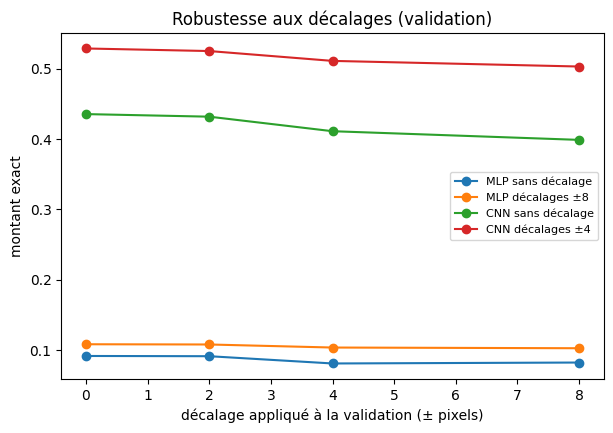

In [ ]:
rng_s = np.random.default_rng(123)
PX = [0, 2, 4, 8]
decales = {px: (decaler(XA["val"], px, rng_s) if px else XA["val"]) for px in PX}   # mêmes images pour tous les modèles

candidats = {"MLP sans décalage": mlp_aug0, f"MLP décalages ±{AUG_RETENU}": mlp_aug4,
             "CNN sans décalage": modeles_cnn["cnn_aug0"], "CNN décalages ±4": modeles_cnn["cnn_aug4"]}
lignes = {nom: {f"validation décalée ±{px}": float(np.mean(lire_positions(m, Xs)[0] == A["montant_val"]))
                for px, Xs in decales.items()} for nom, m in candidats.items()}
rob = pd.DataFrame(lignes).T
display(rob.round(4))

plt.figure(figsize=(7, 4.5))
for nom in rob.index:
    plt.plot(PX, rob.loc[nom].values, "o-", label=nom)
plt.xlabel("décalage appliqué à la validation (± pixels)"); plt.ylabel("montant exact")
plt.title("Robustesse aux décalages (validation)"); plt.legend(fontsize=8); plt.show()

### 11.7 Positions, longueurs et courbes

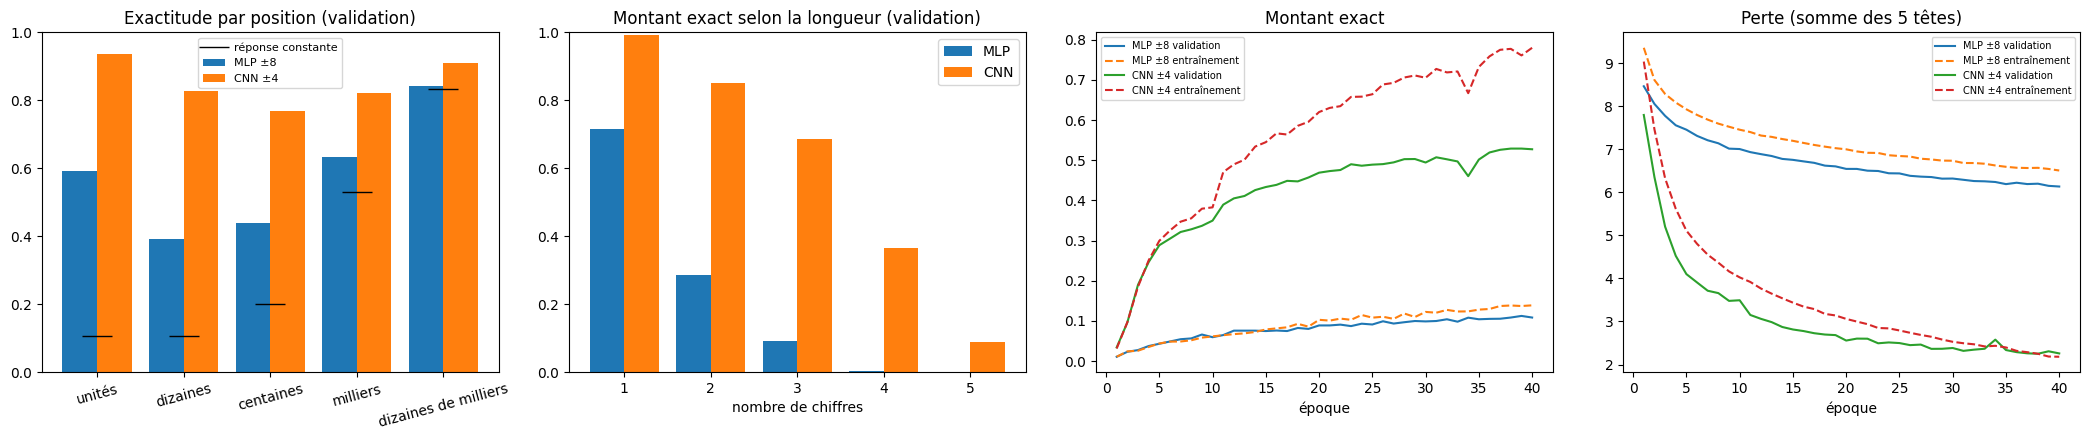

Par position  MLP : [0.591, 0.391, 0.44, 0.633, 0.843]
Par position  CNN : [0.937, 0.827, 0.769, 0.823, 0.91]
Par longueur  MLP : {1: 0.715, 2: 0.285, 3: 0.092, 4: 0.003, 5: 0.0}
Par longueur  CNN : {1: 0.993, 2: 0.852, 3: 0.686, 4: 0.366, 5: 0.089}


In [ ]:
m_a, m_b = mlp_aug4, modeles_cnn["cnn_aug4"]
pv_a, pv_b = predire_probs(m_a, XA["val"]), predire_probs(m_b, XA["val"])
lus_a, _ = lire_probs(pv_a); lus_b, _ = lire_probs(pv_b)
acc_a, acc_b = exactitude_par_position(pv_a, Y_val), exactitude_par_position(pv_b, Y_val)
len_a, len_b = exactitude_par_longueur(lus_a, A["montant_val"]), exactitude_par_longueur(lus_b, A["montant_val"])

fig, ax = plt.subplots(1, 4, figsize=(21, 4.5))
x = np.arange(L_MAX)
ax[0].bar(x - 0.2, acc_a, 0.4, label=f"MLP ±{AUG_RETENU}"); ax[0].bar(x + 0.2, acc_b, 0.4, label="CNN ±4")
ax[0].plot(x, base_pos, "k_", markersize=22, label="réponse constante")
ax[0].set_xticks(x); ax[0].set_xticklabels(NOMS_POS, rotation=15); ax[0].set_ylim(0, 1)
ax[0].set_title("Exactitude par position (validation)"); ax[0].legend(fontsize=8)

ns = sorted(len_a)
xl = np.arange(len(ns))
ax[1].bar(xl - 0.2, [len_a[n][0] for n in ns], 0.4, label="MLP"); ax[1].bar(xl + 0.2, [len_b[n][0] for n in ns], 0.4, label="CNN")
ax[1].set_xticks(xl); ax[1].set_xticklabels([str(n) for n in ns]); ax[1].set_ylim(0, 1)
ax[1].set_xlabel("nombre de chiffres"); ax[1].set_title("Montant exact selon la longueur (validation)"); ax[1].legend()

for nom, H, st in [(f"MLP ±{AUG_RETENU}", hist_aug[AUG_RETENU], "-"), ("CNN ±4", hist_cnn["cnn_aug4"], "-")]:
    e = range(1, len(H["exact_va"]) + 1)
    ax[2].plot(e, H["exact_va"], st, label=f"{nom} validation"); ax[2].plot(e, H["exact_tr"], "--", label=f"{nom} entraînement")
    ax[3].plot(e, H["loss_va"], st, label=f"{nom} validation"); ax[3].plot(e, H["loss_tr"], "--", label=f"{nom} entraînement")
ax[2].set_title("Montant exact"); ax[3].set_title("Perte (somme des 5 têtes)")
for a in ax[2:]:
    a.set_xlabel("époque"); a.legend(fontsize=7)
plt.tight_layout(); plt.show()

print("Par position  MLP :", [round(a, 3) for a in acc_a])
print("Par position  CNN :", [round(a, 3) for a in acc_b])
print("Par longueur  MLP :", {n: round(v[0], 3) for n, v in len_a.items()})
print("Par longueur  CNN :", {n: round(v[0], 3) for n, v in len_b.items()})

### 11.8 Choix de la configuration du CNN

In [ ]:
nom_cnn, cand_cnn = choisir_config(tab_cnn, n_val)        # même règle qu'à la section 7
print("Candidats dans le bruit du meilleur :", list(cand_cnn.index))
print("Configuration CNN retenue :", nom_cnn, ESSAIS_CNN[nom_cnn])

p_cnn = dict(ESSAIS_CNN[nom_cnn]); aug_cnn = p_cnn.pop("aug", 0)    # p_cnn : réglages du réseau ; aug_cnn : décalage

Candidats dans le bruit du meilleur : ['cnn_aug4']
Configuration CNN retenue : cnn_aug4 {'aug': 4}


### 11.9 Variabilité due à la graine (optionnelle)

In [ ]:
LANCER_GRAINES = True    # mettre False pour gagner du temps (4 entraînements de 40 époques)
if LANCER_GRAINES:
    SEEDS = [1, 2]
    lignes = [dict(arch="MLP", seed=0, exact_val=tab_aug.loc[f"aug{AUG_RETENU}", "exact_val"]),
              dict(arch="CNN", seed=0, exact_val=tab_cnn.loc[nom_cnn, "exact_val"])]
    for s in SEEDS:
        _, _, r = entrainer_generique(f"mlp_graine{s}", lambda: build(nom="mlp_s", **cfg),
                                      epochs=40, aug=AUG_RETENU, seed=s, arch="mlp")
        lignes.append(dict(arch="MLP", seed=s, exact_val=r["exact_val"]))
        _, _, r = entrainer_generique(f"cnn_graine{s}", lambda: build_cnn(nom="cnn_s", **p_cnn),
                                      epochs=40, aug=aug_cnn, seed=s, arch="cnn")
        lignes.append(dict(arch="CNN", seed=s, exact_val=r["exact_val"]))
    tab_graines = pd.DataFrame(lignes)
    display(tab_graines.pivot(index="seed", columns="arch", values="exact_val").round(4))
    print(tab_graines.groupby("arch")["exact_val"].agg(["mean", "std"]).round(4))


mlp_graine1 {'aug': 8, 'epochs': 40, 'seed': 1, 'params': 2268983, 'epoque_retenue': 39, 'exact_val': 0.1187, 'auto_val': 0.0117, 'seuil_val': 0.8379, 'ece_val': 0.0407, 'exact_train': 0.1473, 'loss_train': 6.4747, 'loss_val': 6.1183, 'arch': 'mlp'}
cnn_graine1 {'aug': 4, 'epochs': 40, 'seed': 1, 'params': 587255, 'epoque_retenue': 35, 'exact_val': 0.551, 'auto_val': 0.1757, 'seuil_val': 0.9383, 'ece_val': 0.0259, 'exact_train': 0.8357, 'loss_train': 1.8417, 'loss_val': 2.1661, 'arch': 'cnn'}
mlp_graine2 {'aug': 8, 'epochs': 40, 'seed': 2, 'params': 2268983, 'epoque_retenue': 40, 'exact_val': 0.1147, 'auto_val': 0.0053, 'seuil_val': 0.9217, 'ece_val': 0.0328, 'exact_train': 0.139, 'loss_train': 6.4855, 'loss_val': 6.1004, 'arch': 'mlp'}
cnn_graine2 {'aug': 4, 'epochs': 40, 'seed': 2, 'params': 587255, 'epoque_retenue': 38, 'exact_val': 0.5283, 'auto_val': 0.1583, 'seuil_val': 0.937, 'ece_val': 0.0184, 'exact_train': 0.7627, 'loss_train': 2.1888, 'loss_val': 2.2514, 'arch': 'cnn'}


arch,CNN,MLP
seed,,
0,0.5290,0.1083
1,0.5510,0.1187
2,0.5283,0.1147


        mean     std
arch                
CNN   0.5361  0.0129
MLP   0.1139  0.0052


### 11.10 CNN final

  époque  10 | perte val 3.375 | exact train 0.413 | exact val 0.365
  époque  20 | perte val 2.822 | exact train 0.565 | exact val 0.450
  époque  30 | perte val 2.472 | exact train 0.679 | exact val 0.475
  époque  40 | perte val 2.192 | exact train 0.788 | exact val 0.548
  époque  50 | perte val 2.276 | exact train 0.824 | exact val 0.555
  époque  60 | perte val 2.228 | exact train 0.862 | exact val 0.566
  époque  70 | perte val 2.470 | exact train 0.858 | exact val 0.552
  époque  80 | perte val 2.290 | exact train 0.921 | exact val 0.588
cnn_final_80ep {'aug': 4, 'epochs': 80, 'seed': 0, 'params': 587255, 'epoque_retenue': 77, 'exact_val': 0.5847, 'auto_val': 0.2027, 'seuil_val': 0.9773, 'ece_val': 0.0892, 'exact_train': 0.9083, 'loss_train': 1.3924, 'loss_val': 2.248, 'arch': 'cnn'}


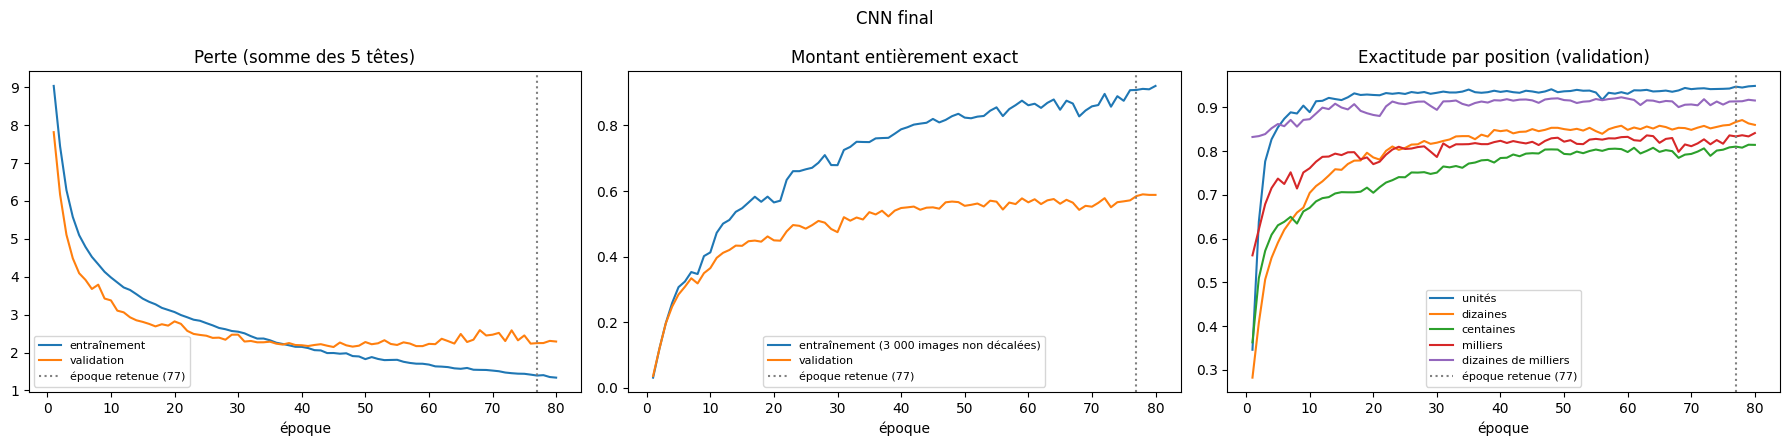

Époque retenue : 77 sur 80
T ajusté = 1.59 | T retenu = 1.59
Validation : exact = 0.5847 | ECE = 0.0586
  seuil 99 % : 0.893119752407074 -> 0.1817 des chèques (545)
  seuil 95 % : 0.7079212069511414 -> 0.3410 des chèques (1023)


In [ ]:
EPOCHS_CNN = 80
m_cnn, H_cnn, res_cnn = entrainer_generique(
    f"cnn_final_{EPOCHS_CNN}ep", lambda: build_cnn(nom="cnn_final", **p_cnn),
    epochs=EPOCHS_CNN, aug=aug_cnn, selection="regle", verbose=True, arch="cnn", **p_cnn)
tracer_apprentissage(H_cnn, res_cnn["epoque_retenue"], "CNN final")
print("Époque retenue :", res_cnn["epoque_retenue"], "sur", EPOCHS_CNN)

# Décisions figées sur la VALIDATION (mêmes règles que pour le MLP)
pv_c = predire_probs(m_cnn, XA["val"])
lus1, conf1 = lire_probs(pv_c, 1.0); cor1 = lus1 == A["montant_val"]
T_opt_c = ajuster_temperature(pv_c, Y_val)
_, confT = lire_probs(pv_c, T_opt_c)
T_CNN = T_opt_c if ece(confT, cor1) < 0.8 * ece(conf1, cor1) else 1.0
lus_vc, conf_vc = lire_probs(pv_c, T_CNN); cor_vc = lus_vc == A["montant_val"]
tx99_vc, SEUIL99_C, _ = taux_automatisation(cor_vc, conf_vc, 0.99)
tx95_vc, SEUIL95_C, _ = taux_automatisation(cor_vc, conf_vc, 0.95)
print(f"T ajusté = {T_opt_c:.2f} | T retenu = {T_CNN:.2f}")
print(f"Validation : exact = {cor_vc.mean():.4f} | ECE = {ece(conf_vc, cor_vc):.4f}")
print(f"  seuil 99 % : {SEUIL99_C} -> {tx99_vc:.4f} des chèques ({int(round(tx99_vc * len(cor_vc)))})")
print(f"  seuil 95 % : {SEUIL95_C} -> {tx95_vc:.4f} des chèques ({int(round(tx95_vc * len(cor_vc)))})")

### 11.11 Évaluation du CNN sur le test (une seule fois)

In [ ]:
assert "CNN_TEST_DEJA_EVALUE" not in globals(), "Le test du CNN a déjà été évalué : on ne le relance pas."

pt_cnn = predire_probs(m_cnn, XA["test"])
lus_tc, conf_tc = lire_probs(pt_cnn, T_CNN)
cor_tc = lus_tc == A["montant_test"]
n_t = len(cor_tc)

exact_tc = float(cor_tc.mean())
acc_pos_tc = exactitude_par_position(pt_cnn, Y_test)
acc_len_tc = exactitude_par_longueur(lus_tc, A["montant_test"])
taux_tc, _, _ = taux_automatisation(cor_tc, conf_tc, 0.99)              # définition de l'énoncé
dep_c = {}
for nom, seuil in [("99 %", SEUIL99_C), ("95 %", SEUIL95_C)]:
    auto = conf_tc >= seuil if seuil is not None else np.zeros(n_t, bool)
    dep_c[nom] = (float(auto.mean()), float(cor_tc[auto].mean()) if auto.any() else None)
ev_tc = evaluer_score(cor_tc, conf_tc); ece_tc = ece(conf_tc, cor_tc)
ic_tc = bootstrap_auto(cor_tc, conf_tc)
diff_t, ic_diff = diff_appariee(cor_tc, cor_t)                          # CNN - MLP, mêmes chèques de test

CNN_TEST_DEJA_EVALUE = True
journaliser(1, "TEST_final_cnn", exact_test=exact_tc, auto99_test=float(taux_tc), ece_test=ece_tc,
            auc_test=ev_tc["auc"], T=T_CNN, seuil99_val=SEUIL99_C, seuil95_val=SEUIL95_C)

print(f"{'':32s}{'MLP':>10s}{'CNN':>10s}   (cibles)")
print(f"{'Montant exact (test)':32s}{exact_t:10.4f}{exact_tc:10.4f}   (0,85)")
print(f"{'Automatisation à 99 % (énoncé)':32s}{taux_t:10.4f}{taux_tc:10.4f}   (0,40)")
print(f"{'AUC de la confiance':32s}{ev_t['auc']:10.4f}{ev_tc['auc']:10.4f}")
print(f"{'Précision des 10 % les plus sûrs':32s}{ev_t['prec_top10']:10.4f}{ev_tc['prec_top10']:10.4f}")
print(f"{'ECE':32s}{ece_t:10.4f}{ece_tc:10.4f}")
print(f"\nCNN - MLP, montant exact sur le test : {diff_t:+.4f}  (IC 95 % bootstrap apparié : [{ic_diff[0]:+.4f} ; {ic_diff[1]:+.4f}])")
print(f"CNN : IC bootstrap de l'automatisation à 99 % : [{ic_tc[0]:.4f} ; {ic_tc[1]:.4f}]")
for nom, (part, prec) in dep_c.items():
    print(f"CNN, déploiement, seuil {nom} fixé sur la validation : part automatisée = {part:.4f} | "
          f"précision réelle = {prec if prec is None else round(prec, 4)}")
print("\nPar position  MLP :", [round(a, 3) for a in acc_pos_t])
print("Par position  CNN :", [round(a, 3) for a in acc_pos_tc])
print("Par longueur  MLP :", {n: round(v[0], 3) for n, v in acc_len_t.items()})
print("Par longueur  CNN :", {n: round(v[0], 3) for n, v in acc_len_tc.items()})

                                       MLP       CNN   (cibles)
Montant exact (test)                0.1184    0.5370   (0,85)
Automatisation à 99 % (énoncé)      0.0098    0.1642   (0,40)
AUC de la confiance                 0.8746    0.8804
Précision des 10 % les plus sûrs    0.6000    0.9940
ECE                                 0.0118    0.0596

CNN - MLP, montant exact sur le test : +0.4186  (IC 95 % bootstrap apparié : [+0.4048 ; +0.4332])
CNN : IC bootstrap de l'automatisation à 99 % : [0.0830 ; 0.1973]
CNN, déploiement, seuil 99 % fixé sur la validation : part automatisée = 0.1496 | précision réelle = 0.9906
CNN, déploiement, seuil 95 % fixé sur la validation : part automatisée = 0.2932 | précision réelle = 0.9468

Par position  MLP : [0.628, 0.394, 0.437, 0.63, 0.841]
Par position  CNN : [0.924, 0.822, 0.769, 0.821, 0.911]
Par longueur  MLP : {1: 0.759, 2: 0.319, 3: 0.104, 4: 0.013, 5: 0.001}
Par longueur  CNN : {1: 0.973, 2: 0.863, 3: 0.712, 4: 0.376, 5: 0.094}


### 11.12 Graphiques du CNN sur le test

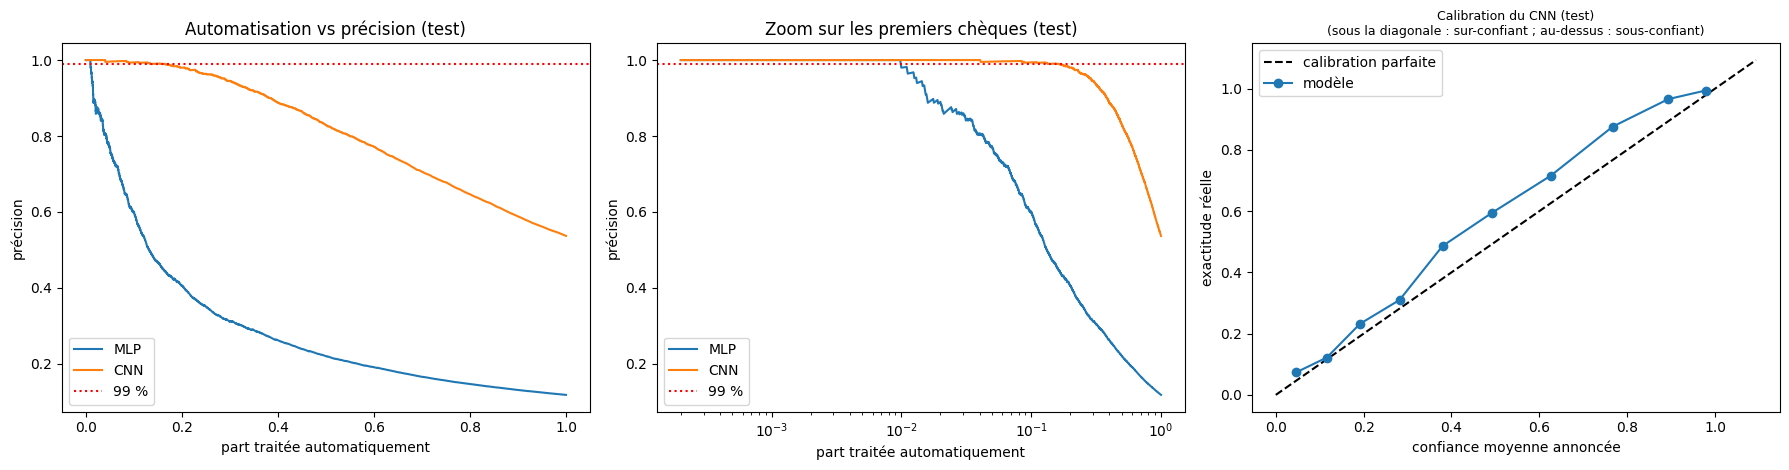

Table de calibration du CNN (test) :
  groupe 0: confiance moy = 0.047 | exactitude = 0.074 | n = 500
  groupe 1: confiance moy = 0.116 | exactitude = 0.122 | n = 500
  groupe 2: confiance moy = 0.192 | exactitude = 0.232 | n = 500
  groupe 3: confiance moy = 0.282 | exactitude = 0.310 | n = 500
  groupe 4: confiance moy = 0.380 | exactitude = 0.486 | n = 500
  groupe 5: confiance moy = 0.492 | exactitude = 0.594 | n = 500
  groupe 6: confiance moy = 0.626 | exactitude = 0.716 | n = 500
  groupe 7: confiance moy = 0.767 | exactitude = 0.876 | n = 500
  groupe 8: confiance moy = 0.894 | exactitude = 0.966 | n = 500
  groupe 9: confiance moy = 0.979 | exactitude = 0.994 | n = 500

CNN, exactitude du montant selon l'altération (test, descriptif) :
  chèques normaux : 0.5498  (n=4505)
  chèques altérés : 0.4202  (n=495)


In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4.8))
part_m, prec_m = courbe_automatisation(cor_t, conf_t)
part_c, prec_c = courbe_automatisation(cor_tc, conf_tc)
for a in ax[:2]:
    a.plot(part_m, prec_m, label="MLP"); a.plot(part_c, prec_c, label="CNN")
    a.axhline(0.99, color="r", ls=":", label="99 %"); a.legend()
    a.set_xlabel("part traitée automatiquement"); a.set_ylabel("précision")
ax[0].set_title("Automatisation vs précision (test)")
ax[1].set_xscale("log"); ax[1].set_title("Zoom sur les premiers chèques (test)")
tracer_calibration(conf_tc, cor_tc, ax[2], "Calibration du CNN (test)")
plt.tight_layout(); plt.show()

print("Table de calibration du CNN (test) :")
for l in table_calibration(conf_tc, cor_tc):
    print(f"  groupe {l['groupe']}: confiance moy = {l['conf_moy']:.3f} | exactitude = {l['exact']:.3f} | n = {l['n']}")

print("\nCNN, exactitude du montant selon l'altération (test, descriptif) :")
for nom, flag in [("normaux", 0), ("altérés", 1)]:
    sel = A["altere_test"] == flag
    print(f"  chèques {nom:8s}: {cor_tc[sel].mean():.4f}  (n={sel.sum()})")

### Lecture des résultats de la section 11

### Lecture des résultats de la section 11

**Le CNN lit nettement mieux, pas assez pour la cible.** Sur le test, le montant exact passe de **0,118** (MLP) à **0,537** (CNN), pour une cible de 0,85. La différence appariée sur les mêmes 5 000 chèques est de **+0,419** (IC bootstrap à 95 % : [+0,405 ; +0,433]). Sur la validation, avec 3 graines, le CNN fait 0,536 ± 0,013 et le MLP 0,114 ± 0,005 : l'écart (42 points) est très supérieur à la variabilité due à la graine. Le CNN y arrive avec **587 255 paramètres contre 2 268 983** pour le MLP retenu, et sa première couche passe de 2 097 664 paramètres à 320.

**Par position et par longueur (test).** Exactitude par position, CNN contre MLP : unités 0,924 contre 0,628 ; dizaines 0,822 contre 0,394 ; centaines 0,769 contre 0,437 ; milliers 0,821 contre 0,630 ; dizaines de milliers 0,911 contre 0,841 (réponse constante : 0,827). Par longueur : 0,973, 0,863, 0,712, 0,376 et 0,094 pour 1 à 5 chiffres (MLP : 0,759, 0,319, 0,104, 0,013, 0,001). Les montants de 4 et 5 chiffres, qui représentent 47 % des chèques, restent le point faible.

**Automatisation.** À 99 % (définition de l'énoncé, seuil recalculé sur le test), le CNN traite **16,4 %** des chèques (IC bootstrap [8,3 % ; 19,7 %]) contre 0,98 % pour le MLP, pour une cible de 40 %. Avec le seuil fixé sur la validation, le CNN automatise **15,0 %** des chèques avec une précision réelle de **0,991** ; le seuil « 95 % » en automatise 29,3 % avec une précision de 0,947. Le seuil a donc tenu sa promesse ici, ce qui n'était pas le cas du MLP (précision de 0,933 pour 1,5 %). Le chiffre à retenir est celui du déploiement, car l'estimation « seuil recalculé sur le test » est un maximum, donc optimiste.

**Confiance.** L'AUC de la confiance est quasi identique (0,880 contre 0,875) : le CNN ne classe pas mieux ses chèques, il lit mieux. Sa calibration est **moins bonne** que celle du MLP (ECE 0,060 contre 0,012) : sur le test, l'exactitude dépasse la confiance annoncée dans les 10 groupes. Le CNN est sous-confiant, ce qui est le sens le moins risqué pour automatiser.

**Ce que le résultat ne montre pas.** L'hypothèse de la section 10 attribuait l'écart au partage de poids (invariance par translation). Les données ne tranchent pas : le CNN lit déjà à 0,436 contre 0,092 pour le MLP **sans aucun décalage**, et sa perte en exactitude à ±8 px (−3,7 points sans augmentation, −2,6 avec) n'est pas très différente en relatif de celle du MLP (qui est cependant près de son plancher, donc peu informatif). Le gain est compatible avec les champs locaux, le partage de poids et le plus petit nombre de paramètres, sans que nous les ayons séparés. L'augmentation agit surtout comme une régularisation (écart train/validation de 0,41 à 0,25 pour le CNN).

**Limites.**
- Le CNN surapprend aussi : 0,908 à l'entraînement contre 0,585 en validation à l'époque retenue (77 sur 80), et la perte de validation remonte après l'époque 40. L'exactitude de validation montait encore à l'époque 80 : le modèle n'a pas convergé.
- La validation est optimiste : 0,585 contre 0,537 au test (−4,8 points, pour un bruit d'environ 0,7 point), car l'époque, la température et les seuils ont été choisis sur la validation.
- Le MLP final utilise des décalages de ±8 px et le CNN de ±4 px. Le MLP a eu 14 essais, le CNN 4, dont un (lr 3e-4) manifestement sous-entraîné à 40 époques. Une seule graine pour les comparaisons principales.
- Le gain est mesuré sur ces données uniquement.

In [ ]:
J = pd.read_json("journal.jsonl", lines=True)
print(len(J), "expériences journalisées")
print("TEST_final (MLP) apparaît", (J["nom"] == "TEST_final").sum(), "fois (attendu : 1)")
print("TEST_final_cnn apparaît", (J["nom"] == "TEST_final_cnn").sum(), "fois (attendu : 1)")
display(J[["t", "nom"]])

from google.colab import files
files.download("journal.jsonl")

34 expériences journalisées
TEST_final (MLP) apparaît 1 fois (attendu : 1)
TEST_final_cnn apparaît 1 fois (attendu : 1)


,t,nom
0,2026-10-04 16:18:21,reference_30ep
1,2026-10-04 16:19:33,reference
2,2026-10-04 16:20:40,etroit_128-64
3,2026-10-04 16:21:45,une_couche_128
4,2026-10-04 16:22:53,large_512-256
5,2026-10-04 16:23:59,profond_256-256-128
6,2026-10-04 16:25:10,large_profond_512-256-128_do0.3
7,2026-10-04 16:26:17,dropout0.3
8,2026-10-04 16:27:26,dropout0.5
9,2026-10-04 16:28:32,lr1e-4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>